In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR02 — ÜDM istehsal strukturu (11 sahə) və qeyri-neft ÜDM-in aşağıdan-yuxarı hesablanması

Ümumi buraxılışın, aralıq istehlakın və əlavə dəyərin 11 iqtisadi sahə üzrə artım və deflyator
templərinin proqnozlaşdırılması, sahə əlavə dəyərlərinin cəmlənməsi və məhsula və idxala xalis
vergilərin blok üzrə bölgüsü ilə **qeyri-neft ÜDM-inin bazar qiymətləri ilə qurulması**
(MİİS §15.5.1, bənd 2.4.1.2.; hüquqi əsas — Nazirlər Kabinetinin 24.05.2004 tarixli 75 nömrəli
qərarı, bənd 2.4.1).

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR2):** "ÜDM istehsal strukturunun (artım və deflyator indeksləri,
ümumi buraxılış, aralıq istehlak, əlavə dəyər) tempinin proqnozlaşdırılması."

Tələb ÜDM-i **istehsal metodu** ilə parçalayır: hər sahə üçün ümumi buraxılış (GO), aralıq istehlak
(IC) və əlavə dəyər (VA = GO − IC) ayrıca göstərilir, hər üçü üçün həm cari qiymətlərlə səviyyə, həm
real artım tempi, həm də deflyator tələb olunur. Statutar şablon (8 vərəq, 2.4.1.2.) iqtisadiyyatı 11
sahəyə bölür: kənd təsərrüfatı, mədənçıxarma sənayesi, emal sənayesi, elektrik enerjisi, su təchizatı,
tikinti, ticarət, turizm, nəqliyyat, informasiya-rabitə və sosial/digər xidmətlər.

**Bu buraxılışda dəyişən üç şey.**

1. **Sürücü xəritəsi.** Əvvəlki buraxılışda 11 sahə cəmi beş sürücü ilə idarə olunurdu və onlardan
   ikisi **dövrəvi** idi: informasiya-rabitə birbaşa qeyri-neft ÜDM artımına, sosial xidmətlər isə
   əhalinin gəlirlərinə (özü qeyri-neft artımının xətti funksiyası olan kəmiyyətə) bağlanmışdı —
   yəni sahə özünün formalaşdırdığı məcmu ilə izah olunurdu. İndi hər sahə üçün **ayrıca
   adlandırılmış sürücü** sınaqdan keçirilir, dövrəvi sürücü isə sınaqda nə qədər yaxşı olsa da
   mərkəzi yola buraxılmır. Adlandırılmış sürücü avtomatik qəbul edilmir: hər sahədə o, icazəli
   alternativ və köhnə sürücü ilə **eyni pəncərədə** yarışır, qərarı geriyə doğru sınaq verir və
   uduzan namizədin bacarığı da nəşr olunur.
2. **Deflyatorlar.** Əvvəllər 11 deflyatorun hamısının sağ tərəfi eyni idi (İQİ və Brent). İndi hər
   sahə üçün həmin sahənin öz qiymət sırası (sahə buraxılışının implisit deflyatoru, sahə üzrə
   qiymət indeksi və ya neft-qaz blokunun çəkili qiymət indeksi) sınaqdan keçirilir; kənd
   təsərrüfatında isə Nazirliyin öz `eq_dfpi_az` tənliyinin forması (gecikmiş deflyator + qida
   qiyməti + İQİ) uyğunlaşdırılıb qəbul edilir.
3. **İstiqamət.** Sahə əlavə dəyərləri artıq yuxarıdan verilmiş qeyri-neft ÜDM-ə miqyaslanmır.
   Əksinə: sahə əlavə dəyərləri cəmlənir, üzərinə məhsula və idxala xalis vergilərin qeyri-neft
   payı gəlir və nəticə **qeyri-neft ÜDM-i (bazar qiymətləri ilə, istehsal metodu)** kimi nəşr
   olunur. Miqyaslama (`reconcile_to_total`) dəftərdən ÇIXARILIB.

Dəftərin icra ardıcıllığındakı yeri: FR05b (neft-qaz bloku) və FR09 (İQİ) yuxarı axındadır —
mədənçıxarma sahəsinin neft-qaz hissəsi birbaşa neft-qaz blokunun həcm və qiymət yollarından gəlir.
Nəticələr FR03-ün (fəaliyyət strukturu) girişidir.

## 2. Məlumat

### 2.1 Sahə hesabları (LHS)

| `series_code` | Təsvir | Vahid | Mənbə | Əhatə |
|---|---|---|---|---|
| `go_<sahə>` | ümumi buraxılış, 11 sahə | mln AZN | Real sektor (əsas); 8 vərəq 2.4.1.2. | 2000/2004–2025 |
| `va_<sahə>` | əlavə dəyər, 11 sahə | mln AZN | eyni mənbə | 2000/2005–2025 |
| `ic_ssc_<sahə>` | **aralıq istehlak (P.2) — nəşr olunan sıra** | mln AZN | **DSK, cədvəl 13 (`013en`)** | **2005–2025** |
| `ic_<sahə>` | aralıq istehlak (statutar şablon, çarpaz yoxlama üçün) | mln AZN | 8 vərəq 2.4.1.2. | 2013–2024 |
| `g_<sahə>` | əlavə dəyərin real artım tempi | % | Real sektor (idx100 çevrilməsi) | 1995/2000/2010–2025 |
| `gdp_nom`, `oil_nom`, `nonoil_nom` | ÜDM və blok səviyyələri — eynilik və müqayisə üçün | mln AZN | Real sektor / DSK rəsmi 2025 | 1995–2025 |
| `net_taxes`, `net_taxes_g` | məhsula və idxala xalis vergilər | mln AZN, % | Real sektor, 43–44 | 2000–2025 |

### 2.2 Sahə sürücüləri (sürücü xəritəsi)

Hər sıra `data_layer.sector_driver(...)` ilə oxunur: bu funksiya vərəq, sətir və **etiket** üçlüyünü
yoxlayır (iş kitabının yeni buraxılışında sətir sürüşərsə, dəftər səssiz yanlış nəticə vermək əvəzinə
dayanır) və sıranı 2025-ci ildə kəsir.

Cədvəlin birinci sütunu sahə üçün **adlandırılmış** sürücüdür; ikinci sütun — həmin sahə üçün
sınaqda yarışan icazəli alternativ (varsa). Hansının mərkəzi yolu daşıyacağını iqtisadi mülahizə
deyil, **qapı və geriyə doğru sınaq** həll edir; nəticə Bölmə 6-nın qərar cədvəlindədir.

| Sahə | adlandırılmış sürücü | İcazəli alternativ | Mənbə |
|---|---|---|---|
| kənd təsərrüfatı | bitkiçilik və heyvandarlıq məhsullarının fiziki həcm indeksi | — | 8 vərəq 2.4.1.4., 1.1 və 1.2 bölmələri (2013–2024) |
| mədənçıxarma | **eynilik**: neft-qaz hasilatı FR05b blokundan, qeyri-neft mədənçıxarma qalıq kimi | — | Mədənçıxarma vərəqi, sətir 4 və 9 (2016–2025) |
| emal sənayesi | qeyri-neft sənaye dövriyyəsi (DVX 57) — **n = 5, D5 üzrə tənlik qurulmur**; sənədləşdirilmiş əvəzedici: qeyri-neft mal ixracı | sənayeyə real kredit | `exp_goods_nonoil` (2010–2025); Monetar sektoru 46 |
| elektrik enerjisi | elektrik enerjisi istehsalının fiziki həcmi | — | 8 vərəq 2.4.1.4., sətir 182 + 184 (2013–2024) |
| su təchizatı | büdcənin infrastruktur əsaslı vəsait qoyuluşu (DİP) | əhalinin orta illik sayı | DİP 2016-2026, sətir 5 (2016–2025); `pop_avg` |
| tikinti | dövlət büdcəsinin əsaslı vəsait qoyuluşu, real (dövlət/qeyri-dövlət bölgüsünün dövlət termi) | tikinti-quraşdırma işlərinin real həcmi | Fiskal sektor 19 (2010–2025); Real sektor 110 |
| ticarət | pərakəndə ticarət dövriyyəsinin real artımı | — | Sosial sektor, sətir 15–16 (1990–2025) |
| turizm və iaşə | xarici ziyarətçilərin sayı (`FOREIGNTURIST`) — **məlumat asılılığı**; aralıq əvəzedici: turizm xidmətləri ixracı | ictimai iaşə dövriyyəsinin real artımı | Tədiyyə Balansı 22 (2010–2025); Sosial sektor 5–6 |
| nəqliyyat | nəqliyyat sektorunda yük dövriyyəsi (boru kəməri həmin cəmin tərkibindədir) | neft-qaz əmtəəlik həcm indeksi | 8 vərəq 2.4.1.4., sətir 200 (2013–2024); FR05b bloku |
| informasiya-rabitə | mobil telefon abunəçilərinin sayı | telekomunikasiya xidmətləri ixracı, real | 8 vərəq 2.4.1.4., sətir 217 (2013–2024); Tədiyyə Balansı 28 |
| sosial və digər | dövlət büdcəsinin real cari xərcləri | orta aylıq pensiyanın real artımı | Fiskal sektor 17 (2010–2025); Sosial sektor 71 |

**Nümunə uzunluğu intizamı (D5).** DVX vərəqinin sahə dövriyyəsi sətirləri (53–66) cəmi **beş** illik
müşahidəyə malikdir. Onların üzərində elastiklik qiymətləndirilmir; yalnız **lövbər və çarpaz yoxlama**
kimi işlədilir (Bölmə 9). Nəticədə on bir sahədən **səkkizi** qiymətləndirilmiş tənliklə, **ikisi**
dinamik etalonla (heç bir sürücü qapıdan keçmir), **biri** neft-qaz blokundan gələn eyniliklə idarə
olunur. Qısa nümunəli sıralar (8 vərəqin 2013–2024 blokları, DİP-in 2016-dan başlayan sırası,
mədənçıxarmanın 2016-dan başlayan bölgüsü) aşağıda hər cədvəldə n və pəncərə ilə göstərilir.

### 2.3 Sahə qiymət sıraları

| Deflyator | Sahə-spesifik qiymət termi | Mənbə |
|---|---|---|
| `d_agri` | **`eq_dfpi_az` forması (Nazirliyin öz tənliyi)**: gecikmiş deflyator + kənd təsərrüfatı istehsalçı qiymət indeksi + İQİ | Real sektor, 194; müstəqil təsdiq — MOE AGRI dəyər-çəkili indeksi |
| `d_mining` | neft-qaz ixrac qiymətlərinin çəkili indeksi | FR05b bloku |
| `d_manuf` | emal sənayesi buraxılışının implisit deflyatoru | Real sektor, 57–58 |
| `d_power` | elektrik enerjisi buraxılışının implisit deflyatoru | Real sektor, 59–60 |
| `d_water` | su təchizatı buraxılışının implisit deflyatoru | Real sektor, 61–62 |
| `d_constr` | tikinti-quraşdırma işlərinin implisit deflyatoru | Real sektor, 109–110 |
| `d_trade` | pərakəndə ticarət dövriyyəsinin implisit deflyatoru | Sosial sektor, 15–16 |
| `d_tourism` | ictimai iaşə dövriyyəsinin implisit deflyatoru | Sosial sektor, 5–6 |
| `d_transport` | nəqliyyat xidmətlərinin orta illik qiymət indeksi | Real sektor, 197 |
| `d_ict` | rabitə xidmətlərinin orta illik qiymət indeksi | Real sektor, 199 |
| `d_social` | dövlət sektorunda əmək haqqının artımı (sınaqdan keçirilir) | Sosial sektor, 55 |
| xalis vergilər | İQİ + neftin qiyməti + tərəfdaş inflyasiyası (`eq_def_ntp` uyğunlaşdırılıb) | Real sektor / xarici blok |

**Göstərilən İQİ sətirləri və nə üçün işlədilmir.** Sahə qiymət sıraları qaydası emal, elektrik və su
deflyatorları üçün Real sektorun 189–193-cü sətirlərini (sahə üzrə istehsalçı qiymət indeksləri)
göstərir; həmin sətirlər iş kitabında yalnız **2021-dən** mövcuddur (beş müşahidə), ona görə D5
üzrə tənlik termi kimi işlədilmir. Onların yerinə **sahənin öz buraxılışının implisit deflyatoru**
(eyni vərəqin nominal səviyyə və real artım tempi sətir cütü) götürülür və 189–193 sətirləri
lövbər kimi yan-yana çap olunur. Əvvəlki buraxılışda emal sənayesinin deflyatorunda bütün
sənayenin İQİ-si (sətir 188) dururdu — həmin indeks mədənçıxarma ilə birlikdə hesablandığı üçün
neftin qiyməti ilə hərəkət edir və emal sənayesinin qiymətlərini təmsil etmir.

### 2.4 Proqnoz üfüqünün girişləri

**D1 qaydası dəyişmir**: proqnoz üfüqünün bütün girişləri `data/assumptions.csv`-dən oxunur.
Yuxarı axının yazdığı açarlar: `cpi_infl` (FR09), `brent_usd` (FR05), `oil_realg`, `oil_defl`,
`oilgas_pw_g` (FR05b/FR01), `g_inv_core` (FR01), `partner_gdp_realg` (xarici blok).
Bu dəftər öz sahə sürücülərinin yollarını **özü qurur** (AR(1) / orta / təsadüfi gəzişmə ansamblı,
hər biri geriyə doğru sınaqdan keçirilir) və onları `drv_*` / `pdrv_*` açarları ilə **eyni fərziyyə
faylına yazır** — beləliklə sahə sürücülərinin yolu gizli deyil, yoxlanıla və əvəz edilə biləndir.
Nazirliyin rəsmi sahə planları daxil olduqda həmin açarlar birbaşa əvəzlənir (R9).

**Aralıq istehlakın tərtibi.** `IC = GO − VA` eyniliyi BÜTÜN illər üçün tətbiq olunur və nəticə
statutar şablonun 2013–2024 dəyərləri ilə tutuşdurulur (Bölmə 2.6).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.width", 200)
LA = config.LAST_ACTUAL
FY = list(config.FY)                                # 2026-2030

SECTORS = [
    ("agri",      "Kənd, meşə və balıqçılıq təsərrüfatı"),
    ("mining",    "Mədənçıxarma sənayesi"),
    ("manuf",     "Emal sənayesi"),
    ("power",     "Elektrik enerjisi, qaz və buxar istehsalı və təchizatı"),
    ("water",     "Su təchizatı, tullantıların təmizlənməsi və emalı"),
    ("constr",    "Tikinti"),
    ("trade",     "Ticarət, nəqliyyat vasitələrinin təmiri"),
    ("tourism",   "Turistlərin yerləşdirilməsi və ictimai iaşə"),
    ("transport", "Nəqliyyat və anbar təsərrüfatı"),
    ("ict",       "İnformasiya və rabitə"),
    ("social",    "Sosial və digər sahələrdə yaradılmış əlavə dəyər"),
]
CODES = [c for c, _ in SECTORS]
NAME = dict(SECTORS)
NONOIL_CODES = [c for c in CODES if c != "mining"]   # mədənçıxarma ayrıca bölünür (2.7)
INDUSTRY_NONOIL = ["manuf", "power", "water"]

GO = {c: data_layer.actuals(f"go_{c}") for c in CODES}
VA = {c: data_layer.actuals(f"va_{c}") for c in CODES}
ICW = {c: data_layer.actuals(f"ic_{c}") for c in CODES}     # statutar şablon, 2013-2024
GROW = {c: data_layer.actuals(f"g_{c}") for c in CODES}     # nəşr olunmuş real artım tempi
cpi = data_layer.actuals("cpi_infl")

print("Sahə hesablarının əhatəsi:")
pd.DataFrame({
    "VA əhatəsi": {NAME[c]: f"{int(VA[c].index.min())}-{int(VA[c].index.max())} (n={len(VA[c])})" for c in CODES},
    "artım əhatəsi": {NAME[c]: f"{int(GROW[c].index.min())}-{int(GROW[c].index.max())} (n={len(GROW[c])})" for c in CODES},
    f"VA {LA} (mln AZN)": {NAME[c]: round(float(VA[c].loc[LA]), 1) for c in CODES},
})

Sahə hesablarının əhatəsi:


,VA əhatəsi,artım əhatəsi,VA 2025 (mln AZN)
"Kənd, meşə və balıqçılıq təsərrüfatı",2000-2025 (n=26),1995-2025 (n=31),7649.1
Mədənçıxarma sənayesi,2005-2025 (n=21),1995-2025 (n=31),33108.4
Emal sənayesi,2005-2025 (n=21),2000-2025 (n=26),7719.5
"Elektrik enerjisi, qaz və buxar istehsalı və təchizatı",2005-2025 (n=21),2000-2025 (n=26),1455.7
"Su təchizatı, tullantıların təmizlənməsi və emalı",2005-2025 (n=21),2010-2025 (n=16),301.7
Tikinti,2000-2025 (n=26),1995-2025 (n=31),8426.1
"Ticarət, nəqliyyat vasitələrinin təmiri",2000-2025 (n=26),2000-2025 (n=26),14625.2
Turistlərin yerləşdirilməsi və ictimai iaşə,2000-2025 (n=26),2000-2025 (n=26),3573.0
Nəqliyyat və anbar təsərrüfatı,2000-2025 (n=26),2000-2025 (n=26),9106.2
İnformasiya və rabitə,2000-2025 (n=26),2000-2025 (n=26),2668.6


In [3]:
# ARALIQ İSTEHLAK — MƏNBƏ SIRALAMASI (bu buraxılış).
# Əvvəlki buraxılışda `ic_<sahə>` YALNIZ `GO − VA` eyniliyindən törədilirdi, çünki statutar
# şablonun aralıq istehlak bloku 2024-də bitir və iş kitabında ayrıca sıra yoxdur.
# `DATA_GAP_NEGATIVE_PROOF.md` (v) bəndi göstərdi ki, DSK-nın 13-cü cədvəli («Production and
# generation of income account») aralıq istehlakı NACE bölmələri üzrə 2005–2025* dövrü üçün
# BİRBAŞA dərc edir. Bu buraxılışda nəşr olunan sıra həmin DSK sırasıdır; törəmə isə
# 2005-dən əvvəlki illəri tamamlayan splice ayağı və müstəqil çarpaz yoxlama kimi qalır.
IC_SSC = {c: data_layer.public_series(f"ic_ssc_{c}") for c in CODES}
IC_DER = {c: (GO[c] - VA[c]).dropna().rename(f"ic_{c}_der") for c in CODES}

IC, ic_rows, IC_SPLICE = {}, [], {}
for c in CODES:
    ssc, der, off = IC_SSC[c], IC_DER[c], ICW[c]
    # SPLICE: DSK sırası əsasdır; ondan ƏVVƏLKİ illər (2000–2004) törəmə ilə tamamlanır.
    pre = der[der.index < int(ssc.index.min())]
    IC[c] = pd.concat([pre, ssc]).sort_index().rename(f"ic_{c}")
    IC_SPLICE[c] = (int(pre.index.min()) if len(pre) else None,
                    int(pre.index.max()) if len(pre) else None)

    com_sd = sorted(set(ssc.index) & set(der.index))          # DSK ↔ törəmə
    com_st = sorted(set(ssc.index) & set(off.index))          # DSK ↔ statutar şablon
    com_dt = sorted(set(der.index) & set(off.index))          # törəmə ↔ statutar şablon
    d_sd = (ssc.loc[com_sd] - der.loc[com_sd]).abs()
    ic_rows.append({
        "sahə": NAME[c],
        "DSK əhatəsi": f"{int(ssc.index.min())}-{int(ssc.index.max())}",
        "splice ayağı (törəmə)": (f"{IC_SPLICE[c][0]}-{IC_SPLICE[c][1]}" if IC_SPLICE[c][0] else "—"),
        "DSK−törəmə maks. |fərq|": round(float(d_sd.max()), 2),
        "fərqli il sayı (>0,5 mln)": int((d_sd > 0.5).sum()),
        "DSK−şablon maks. |fərq|": (round(float((ssc.loc[com_st] - off.loc[com_st]).abs().max()), 2)
                                    if com_st else None),
        "törəmə−şablon maks. |fərq|": (round(float((der.loc[com_dt] - off.loc[com_dt]).abs().max()), 2)
                                       if com_dt else None),
    })

print("Aralıq istehlakın ÜÇ mənbəyi — DSK 13 (nəşr olunan), GO−VA törəməsi, statutar şablon:")
print(pd.DataFrame(ic_rows).to_string(index=False))

# İSTİSNALARIN AÇIQ SİYAHISI: DSK ilə törəmə arasındakı fərq harada yaranır
_exc = []
for c in CODES:
    ssc, der = IC_SSC[c], IC_DER[c]
    com = sorted(set(ssc.index) & set(der.index))
    d = (der.loc[com] - ssc.loc[com])
    for y in d.index[d.abs() > 0.5]:
        _exc.append({"sahə": NAME[c], "il": int(y), "DSK (P.2)": round(float(ssc.loc[y]), 1),
                     "GO−VA törəməsi": round(float(der.loc[y]), 1),
                     "fərq": round(float(d.loc[y]), 1),
                     "fərq, %": round(float(d.loc[y] / ssc.loc[y] * 100), 2)})
IC_EXC = pd.DataFrame(_exc)
print()
print(f"İki mənbənin fərqləndiyi sahə-il sayı: {len(IC_EXC)} "
      f"(qalan bütün sahə-illərdə fərq 0,5 mln AZN-dən kiçikdir, yəni yuvarlaqlaşdırma səviyyəsindədir)")
print(IC_EXC.to_string(index=False))

Aralıq istehlakın ÜÇ mənbəyi — DSK 13 (nəşr olunan), GO−VA törəməsi, statutar şablon:
                                                  sahə DSK əhatəsi splice ayağı (törəmə)  DSK−törəmə maks. |fərq|  fərqli il sayı (>0,5 mln)  DSK−şablon maks. |fərq|  törəmə−şablon maks. |fərq|
                  Kənd, meşə və balıqçılıq təsərrüfatı   2005-2025             2000-2004                      0.1                          0                   354.70                      354.70
                                 Mədənçıxarma sənayesi   2005-2025                     —                    444.1                          1                   706.40                     1150.50
                                         Emal sənayesi   2005-2025                     —                    456.1                          1                    58.32                      448.09
Elektrik enerjisi, qaz və buxar istehsalı və təchizatı   2005-2025                     —                     34.8                         

**Oxunuş — nə dəyişdi və nə dəyişmədi.** DSK-nın 13-cü cədvəli ilə `GO − VA` törəməsi **2005–2025 dövrünün 231 sahə-ilinin praktik olaraq hamısında** üst-üstə düşür (fərq yuvarlaqlaşdırma səviyyəsindədir), o cümlədən **2025-ci ildə** — yəni əvvəlki buraxılışın 2025 üçün istifadə etdiyi törəmə DSK-nın öz nəşri ilə müstəqil şəkildə **təsdiqlənir**. Fərq yalnız iki yerdə yaranır və hər ikisi vintaj fərqidir, hesablama səhvi deyil:

* **sosial və digər sahələr, 2005–2009** — iş kitabının əlavə dəyər sətri həmin illərdə DSK-nın cari nəşrindən 72–581 mln AZN aşağıdır (maliyyə vasitəçiliyinin dolayı ölçülən xidmətlərinin, FISIM, bölgüsü sonradan yenilənib);
* **mədənçıxarma / emal / elektrik / su, 2024** — iş kitabının 2024-cü il sənaye bölgüsü DSK-nın son nəşrindən fərqlidir (dörd sahə arasında yenidən bölüşdürülmə; cəmi fərq cəmi 43,7 mln AZN, yəni sənaye blokunun özü içində yerdəyişmədir).

**Qərar.** Nəşr olunan `ic_<sahə>` sırası bundan sonra **DSK-nın öz P.2 sütunudur** (2005–2025); 2000–2004 illəri `GO − VA` törəməsi ilə tamamlanır (splice ayağı yuxarıdakı cədvəldə sətir-sətir göstərilir). Əlavə dəyər (`va_<sahə>`) və ümumi buraxılış (`go_<sahə>`) **dəyişdirilmir** — onlar iş kitabının öz buraxılışıdır və bütün aşağı axın (FR1-in ÜDM aqreqatı, sahə real artımları) məhz ona söykənir; yeni aralıq istehlak τ vasitəsilə modelə daxil olur (Bölmə 5.3), ÜDM səviyyəsinə toxunmadan.

### 2.5 Sürücülərin qurulması

Aşağıdakı xanada hər sahə üçün **adlandırılmış sürücü**, varsa **icazəli alternativ** və
müqayisə üçün saxlanılan **v2 sürücüsü** qurulur. Kredit, büdcə və dövriyyə sıraları İQİ ilə
deflyasiya edilərək real artıma çevrilir; indeks formasında verilən sıralar (əvvəlki il = 100)
100 çıxılmaqla faiz artımına çevrilir; fiziki həcm sıraları birbaşa artıma çevrilir. Heç bir sıra
2025-ci ildən sonrakı ilə uzanmır. Hər namizəd sırası ayrıca **sıçrayış/çökmə** yoxlamasından
keçir: təkbaşına qalan sıçrayış və ya çökmə düzəldilmir, nişanlanır.

In [4]:
d = data_layer.sector_driver


def g_pct(s):
    s = pd.Series(s).astype(float).dropna().sort_index()
    return ((s / s.shift(1) - 1) * 100).dropna()


def real_pct(nom, defl=None):
    """nominal səviyyə sırasını İQİ (və ya verilən deflyator) ilə real artıma çevirir"""
    defl = cpi if defl is None else defl
    gg = g_pct(nom)
    return (((1 + gg / 100) / (1 + defl.reindex(gg.index) / 100) - 1) * 100).dropna()


def idx_pct(i):
    """əvvəlki il = 100 indeksini faiz artımına çevirir"""
    return (pd.Series(i).astype(float).dropna() - 100.0)


def implied_defl(nom_code, realidx_code):
    """iki iş kitabı sətrindən (nominal səviyyə + real artım indeksi) implisit deflyator"""
    gn = g_pct(d(nom_code))
    gr = idx_pct(d(realidx_code))
    return (((1 + gn / 100) / (1 + gr.reindex(gn.index) / 100) - 1) * 100).dropna()


def vq(label, row):
    return data_layer.vereq_actuals("2.4.1.4.", label, row=row)


def mean_g(series_list):
    return pd.concat([g_pct(s) for s in series_list], axis=1).mean(axis=1).dropna()


# --- kənd təsərrüfatı: bitkiçilik və heyvandarlıq fiziki həcmi (8 vərəq 2.4.1.4) --------------
CROP = [vq("Dənli və dənli paxlalılar", 6), vq("Tərəvəz", 9), vq("Kartof", 11),
        vq("Pambıq", 12), vq("Meyvə və giləmeyvə", 16), vq("Üzüm", 17)]
LIVE = [vq("Ət (diri çəkidə)", 20), vq("Süd (fiziki çəkidə)", 25),
        vq("Yumurta", 24), vq("Yun (fiziki çəkidə)", 26)]
# ÇƏKİ QEYDİ: statutar şablon məhsul qiymətlərini vermir, ona görə iki yarım-indeks bərabər
# çəki ilə birləşdirilir. Bu, KONVENSİYADIR (qiymət çəkiləri mənbədə yoxdur) və Bölmə 11-də
# məhdudiyyət kimi qeyd olunur; tənliyin əmsalı miqyası özü udur.
drv_agri = (0.5 * mean_g(CROP) + 0.5 * mean_g(LIVE)).dropna()

# --- ADLANDIRILMIŞ sahə sürücüləri (+ icazəli alternativlər) ---------------------
# emal sənayesi: adlandırılmış sürücü DVX vərəqinin qeyri-neft sənaye dövriyyəsidir (sətir
# 57), lakin həmin sıra cəmi BEŞ illikdir — D5 üzrə onun üzərində elastiklik qiymətləndirilmir.
# Ona görə sənədləşdirilmiş ƏVƏZEDİCİ işlədilir: sahənin öz məhsuluna xarici tələb (qeyri-neft
# mal ixracı). DVX sırası Bölmə 9-da lövbər kimi çap olunur.
drv_manuf = g_pct(data_layer.actuals("exp_goods_nonoil"))
drv_trade = idx_pct(d("social_r016"))                              # pərakəndə ticarət, real
# turizm: adlandırılmış sürücü xarici ziyarətçilərin sayıdır (`FOREIGNTURIST`) — MƏLUMAT
# ASILILIĞI; göstərilən aralıq əvəzedici tədiyyə balansının turizm ixracıdır.
drv_tourism = real_pct(d("bop_r022"))
drv_tourism_alt = idx_pct(d("social_r006"))                        # ictimai iaşə dövriyyəsi, real
# nəqliyyat: yük dövriyyəsi — boru kəməri həmin cəmin tərkib hissəsidir (boru kəməri kanalı)
drv_transport = g_pct(vq("Nəqliyyat sektorunda yük dövriyyəsi - cəmi", 200))
drv_transport_pass = g_pct(vq("Nəqliyyat sektorunda sərnişin dövriyyəsi", 210))
drv_transport_alt = data_layer.oilgas_volume_growth().dropna()     # neft-qaz əmtəəlik həcm indeksi
# informasiya-rabitə: abunəçi həcmi və telekomunikasiya xidmətləri ixracı
drv_ict = g_pct(vq("Mobil telefon abunəçilərinin (nömrələrin) sayı", 217))
drv_ict_alt = real_pct(d("bop_r028"))
# sosial və digər xidmətlər: dövlət büdcəsinin real cari xərcləri (fiskal ötürücü kanal)
drv_social = real_pct(d("fiscal_r017"))
drv_social_alt = real_pct(d("social_r071"))                        # orta pensiya, real
# elektrik enerjisi: istehsalın fiziki həcmi (İES + külək/günəş)
drv_power = g_pct(vq("İstilik Elektrik Stansiyalarının (İES) şərti termik elektriki "
                     "(hasilat xammalı ilə işləyən İES-də istehsal edilən)", 182)
                  + vq("Külək və günəşlə işləyən stansiyalarının elektriki", 184))
# su təchizatı: büdcənin infrastruktur əsaslı vəsait qoyuluşu (DİP) + əhali
drv_water = real_pct(d("dip_r005"))
drv_water_alt = g_pct(data_layer.actuals("pop_avg"))
# tikinti: dövlət/qeyri-dövlət bölgüsünün DÖVLƏT termi
drv_constr = real_pct(d("fiscal_r019"))
drv_constr_alt = idx_pct(d("real_r110"))                           # tikinti-quraşdırma işləri, real
# Dövlət investisiyası tənliyinin İKİ TERMLİ fiskal kompoziti (fiskal kanal 1) — əvvəlki mərhələdə TƏK büdcə capex-i qapıdan
# keçməmişdi; burada kompozit variant sınanır. İkinci term büdcədənkənar dövlət investisiyasıdır:
#   büdcədənkənar = dövlət investisiyası (real_r098) − DƏVQ (fiscal_r019, 2022-23 DİP-dən)
# Bu, dövlət investisiyası tənliyinin "SOE öz vəsaitləri" terminin 16 illik tarixçəsi olan ölçüsüdür; `real_r114` (müəssisə
# öz vəsaitləri) sırasının illik sütunu yalnız n=3-dür və D5-ə görə sürücü kimi işlədilmir —
# aşağıda ALT_TESTED cədvəlində onun ölçüsü də göstərilir.
_capex_sp = data_layer.state_capex()
_stateinv = data_layer.wb_labelled("real_r098")
_stateinv = _stateinv[_stateinv.index <= LA]
drv_constr_soe = real_pct((_stateinv - _capex_sp.reindex(_stateinv.index)).dropna())
drv_constr_stateinv = real_pct(_stateinv)                          # kompozit: capex + büdcədənkənar
_soe114 = data_layer.soe_investment_annual()
drv_constr_soe114 = real_pct(_soe114)                              # n=3 — YALNIZ ölçü göstərmək üçün
# sosial: fiskal kanalın funksional təsnifat variantı (təhsil + səhiyyə + sosial müdafiə)
_func_soc = (d("fiscal_r036") + d("fiscal_r045") + d("fiscal_r051")).dropna()
drv_social_func = real_pct(_func_soc)

# --- v2 (köhnə) sürücülər ---------------------------------------------------------------------
g_inv_h = data_layer.actuals("inv_total_g")
fcons = data_layer.actuals("final_consumption")
g_cons_h = (((fcons / fcons.shift(1)) / (1 + cpi / 100.0) - 1) * 100)
inc_nom = data_layer.actuals("income_nom")
g_inc_h = data_layer.actuals("income_realg").combine_first(
    ((inc_nom / inc_nom.shift(1)) / (1 + cpi / 100.0) - 1) * 100)
g_oil_h = data_layer.actuals("oil_realg")
g_nonoil_h = data_layer.actuals("nonoil_realg")
OLD_H = {"inv": g_inv_h, "cons": g_cons_h, "income": g_inc_h, "oil": g_oil_h, "nonoil": g_nonoil_h}
OLD_KEY = {"agri": "nonoil", "mining": "oil", "manuf": "inv", "power": "inv", "water": "inv",
           "constr": "inv", "trade": "cons", "tourism": "cons", "transport": "nonoil",
           "ict": "nonoil", "social": "income"}
OLD_LABEL = {"inv": "investisiyanın real artımı", "cons": "son istehlakın real artımı",
             "income": "əhalinin real gəlirləri (DÖVRƏVİ)", "oil": "neft-qaz sektorunun real artımı",
             "nonoil": "qeyri-neft ÜDM-in real artımı (DÖVRƏVİ)"}
# v2 tənliyi sınaqda saxlanıldıqda üfüqdə ÖZ sürücüsünün yolu ilə uzadılmalıdır — hər v2 sürücü
# ailəsinin öz fərziyyə açarı göstərilir. (Əvvəlki buraxılışda `cons` ailəsi üçün səhvən v3
# sürücüsünün yolu götürülürdü; bu, ticarət və turizm sahələrində v2 müqayisə yolunu yanlış edirdi.)
OLD_FC_KEY = {"inv": "g_inv_core", "cons": "g_cons_core", "income": "g_income_core",
              "oil": "oil_realg", "nonoil": "nonoil_realg"}
CIRCULAR = {"nonoil", "income"}     # D2: bu iki sürücü sahə tənliyində qadağandır

# v3 NAMİZƏD xəritəsi: sahə -> [(nişan, ad, sıra, `assumptions.csv` açarı), ...]
# SIYAHININ BİRİNCİ ELEMENTİ HƏMİŞƏ sahə üçün adlandırılmış sürücüdür; ikinci element (varsa)
# icazəli alternativdir. Mərkəzi yolu hansının daşıyacağını QAPI və SINAQ həll edir (D3) — heç bir
# namizəd iqtisadi mülahizə ilə seçilmir və uduzan namizəd cədvəldən silinmir.
CAND = {
    "agri":      [("ESAS", "bitkiçilik və heyvandarlıq fiziki həcm indeksi", drv_agri, "drv_agri_g")],
    "manuf":     [("ESAS", "qeyri-neft mal ixracı (DVX dövriyyəsinin əvəzedicisi — D5)", drv_manuf,
                   "drv_manuf_g")],
    "power":     [("ESAS", "elektrik enerjisi istehsalının fiziki həcmi", drv_power, "drv_power_g")],
    "water":     [("ESAS", "büdcənin infrastruktur əsaslı vəsait qoyuluşu (DİP), real", drv_water,
                   "drv_water_g"),
                  ("ALT", "əhalinin orta illik sayı", drv_water_alt, "drv_water_pop_g")],
    "constr":    [("ESAS", "dövlət büdcəsinin əsaslı vəsait qoyuluşu, real", drv_constr,
                   "drv_constr_state_g"),
                  ("ALT", "tikinti-quraşdırma işlərinin real həcmi", drv_constr_alt,
                   "drv_constr_works_g")],
    "trade":     [("ESAS", "pərakəndə ticarət dövriyyəsinin real artımı", drv_trade, "drv_trade_g")],
    "tourism":   [("ESAS", "xarici turizm xidmətləri ixracı, real (ziyarətçi sayının əvəzedicisi)",
                   drv_tourism, "drv_tourism_bop_g"),
                  ("ALT", "ictimai iaşə dövriyyəsinin real artımı", drv_tourism_alt,
                   "drv_tourism_g")],
    "transport": [("ESAS", "nəqliyyat sektorunda yük dövriyyəsi (boru kəməri daxil)", drv_transport,
                   "drv_transport_g"),
                  ("ALT", "neft-qaz əmtəəlik həcm indeksi", drv_transport_alt, "oil_realg")],
    "ict":       [("ESAS", "mobil telefon abunəçilərinin sayı", drv_ict, "drv_ict_subs_g"),
                  ("ALT", "telekomunikasiya xidmətləri ixracı, real", drv_ict_alt, "drv_ict_exp_g")],
    "social":    [("ESAS", "dövlət büdcəsinin real cari xərcləri", drv_social, "drv_social_g"),
                  ("ALT", "orta aylıq pensiyanın real artımı", drv_social_alt,
                   "drv_social_pens_g")],
}
TAGS = {c: [t for t, _, _, _ in CAND[c]] for c in CAND}
CAND_NAME = {c: {t: nm for t, nm, _, _ in CAND[c]} for c in CAND}
CAND_SER = {c: {t: pd.Series(s).astype(float) for t, _, s, _ in CAND[c]} for c in CAND}
CAND_KEY = {c: {t: k for t, _, _, k in CAND[c]} for c in CAND}

# Mənbə sırasında SIÇRAYIŞ/ÇÖKMƏ yoxlaması. Sürücü sırasından səviyyə indeksi bərpa olunur və hər
# il qonşu iki ilin ortası ilə tutuşdurulur: sabit templi artım bu ölçüdə sıfıra yaxındır, təkbaşına
# sıçrayış və ya çökmə isə böyük dəyər verir. Bu, trend sürətini deyil, məhz TƏKRARLANMAYAN
# hadisəni tapır. Aşkarlanan il DÜZƏLDİLMİR (mənbəyə əl gəzdirilmir) — AÇIQ nişanlanır; səbəb
# hesabat qırılması da ola bilər (elektrik istehsalı, 2018-2020), real şok da (2020 pandemiyası).
def _break_years(gser, thresh=0.40):
    g = pd.Series(gser).dropna().sort_index()
    if len(g) < 3:
        return []
    lvl = (1 + g / 100.0).cumprod()
    out = []
    for i in range(1, len(lvl) - 1):
        mid = (float(lvl.iloc[i - 1]) + float(lvl.iloc[i + 1])) / 2.0
        if mid > 0 and abs(float(lvl.iloc[i]) / mid - 1.0) > thresh:
            out.append(int(lvl.index[i]))
    return out

cov = []
for c in NONOIL_CODES:
    ok = OLD_H[OLD_KEY[c]].dropna()
    for tag, nm, s, key in CAND[c]:
        s = pd.Series(s).dropna()
        brk = _break_years(s)
        cov.append({"sahə": NAME[c], "nişan": tag, "sürücü namizədi": nm,
                    "n": len(s), "əhatə": f"{int(s.index.min())}-{int(s.index.max())}",
                    "proqnoz açarı": key,
                    "sıçrayış/çökmə illəri": ", ".join(map(str, brk)) if brk else "",
                    "v2 sürücüsü": OLD_LABEL[OLD_KEY[c]],
                    "v2 dövrəvi?": "BƏLİ" if OLD_KEY[c] in CIRCULAR else "xeyr",
                    "v2 n": len(ok)})
cov_table = pd.DataFrame(cov)
_nbrk = int((cov_table["sıçrayış/çökmə illəri"] != "").sum())
print("Sahə sürücüsü namizədləri — adlandırılmış sürücü xəritəsi, icazəli alternativ və v2:")
if _nbrk:
    print(f"  DİQQƏT: {_nbrk} namizəd sırasında təkrarlanmayan sıçrayış/çökmə aşkarlanıb "
          f"(sütuna bax). Səbəb hesabat qırılması da ola bilər, real şok da; sıra düzəldilmir, "
          f"nəticə qapı cədvəlində bununla birlikdə oxunmalıdır.")
cov_table

Sahə sürücüsü namizədləri — adlandırılmış sürücü xəritəsi, icazəli alternativ və v2:
  DİQQƏT: 5 namizəd sırasında təkrarlanmayan sıçrayış/çökmə aşkarlanıb (sütuna bax). Səbəb hesabat qırılması da ola bilər, real şok da; sıra düzəldilmir, nəticə qapı cədvəlində bununla birlikdə oxunmalıdır.


,sahə,nişan,sürücü namizədi,n,əhatə,proqnoz açarı,sıçrayış/çökmə illəri,v2 sürücüsü,v2 dövrəvi?,v2 n
0,"Kənd, meşə və balıqçılıq təsərrüfatı",ESAS,bitkiçilik və heyvandarlıq fiziki həcm indeksi,11,2014-2024,drv_agri_g,,qeyri-neft ÜDM-in real artımı (DÖVRƏVİ),BƏLİ,13
1,Emal sənayesi,ESAS,qeyri-neft mal ixracı (DVX dövriyyəsinin əvəze...,15,2011-2025,drv_manuf_g,,investisiyanın real artımı,xeyr,25
2,"Elektrik enerjisi, qaz və buxar istehsalı və t...",ESAS,elektrik enerjisi istehsalının fiziki həcmi,11,2014-2024,drv_power_g,"2017, 2018, 2019, 2020",investisiyanın real artımı,xeyr,25
3,"Su təchizatı, tullantıların təmizlənməsi və emalı",ESAS,büdcənin infrastruktur əsaslı vəsait qoyuluşu ...,9,2017-2025,drv_water_g,"2019, 2021, 2022",investisiyanın real artımı,xeyr,25
4,"Su təchizatı, tullantıların təmizlənməsi və emalı",ALT,əhalinin orta illik sayı,34,1992-2025,drv_water_pop_g,,investisiyanın real artımı,xeyr,25
5,Tikinti,ESAS,"dövlət büdcəsinin əsaslı vəsait qoyuluşu, real",13,2011-2025,drv_constr_state_g,,investisiyanın real artımı,xeyr,25
6,Tikinti,ALT,tikinti-quraşdırma işlərinin real həcmi,28,1997-2025,drv_constr_works_g,1998,investisiyanın real artımı,xeyr,25
7,"Ticarət, nəqliyyat vasitələrinin təmiri",ESAS,pərakəndə ticarət dövriyyəsinin real artımı,36,1990-2025,drv_trade_g,,son istehlakın real artımı,xeyr,25
8,Turistlərin yerləşdirilməsi və ictimai iaşə,ESAS,"xarici turizm xidmətləri ixracı, real (ziyarət...",15,2011-2025,drv_tourism_bop_g,"2020, 2021",son istehlakın real artımı,xeyr,25
9,Turistlərin yerləşdirilməsi və ictimai iaşə,ALT,ictimai iaşə dövriyyəsinin real artımı,36,1990-2025,drv_tourism_g,"2019, 2020",son istehlakın real artımı,xeyr,25


In [5]:
# --- sahə qiymət sıraları (deflyator sürücüləri) ----------------------------------------------
brent = data_layer.actuals("brent_usd")
dlb_h = (np.log(brent).diff() * 100).rename("dlb")            # v2 spesifikasiyasının qiymət kanalı
dpw_h = data_layer.oilgas_price_growth("brent").rename("pw")  # FR05b çəkili neft-qaz qiymət indeksi

PRICE_DRV = {
    "agri":      ("kənd təsərrüfatı istehsalçı qiymət indeksi", idx_pct(d("real_r194")), "pdrv_agri"),
    "mining":    ("çəkili neft-qaz ixrac qiyməti indeksi", dpw_h, "oilgas_pw_g"),
    # emal sənayesi: spesifikasiya qeyri-neft sənaye İQİ-sini (Real sektor 189/191) göstərir, lakin həmin
    # sətirlər yalnız 2021-dən mövcuddur (n = 5, D5). Ona görə sahənin ÖZ buraxılışının implisit
    # deflyatoru işlədilir (Real sektor 57/58). Əvvəlki buraxılışda burada BÜTÜN sənayenin İQİ-si
    # (sətir 188) dururdu — o indeks mədənçıxarma ilə birlikdə hesablandığı üçün neftin qiyməti
    # ilə hərəkət edir (2025-ci ildə −9,6 %) və emal sənayesinin qiymət hərəkətini təmsil etmir.
    "manuf":     ("emal sənayesi buraxılışının implisit deflyatoru",
                  implied_defl("real_r057", "real_r058"), "pdrv_manuf"),
    "power":     ("elektrik enerjisi buraxılışının implisit deflyatoru",
                  implied_defl("real_r059", "real_r060"), "pdrv_power"),
    "water":     ("su təchizatı buraxılışının implisit deflyatoru",
                  implied_defl("real_r061", "real_r062"), "pdrv_water"),
    "constr":    ("tikinti-quraşdırma işlərinin implisit deflyatoru", implied_defl("real_r109", "real_r110"), "pdrv_constr"),
    "trade":     ("pərakəndə dövriyyənin implisit deflyatoru", implied_defl("social_r015", "social_r016"), "pdrv_trade"),
    "tourism":   ("ictimai iaşə dövriyyəsinin implisit deflyatoru", implied_defl("social_r005", "social_r006"), "pdrv_tourism"),
    "transport": ("nəqliyyat xidmətlərinin qiymət indeksi", idx_pct(d("real_r197")), "pdrv_transport"),
    "ict":       ("rabitə xidmətlərinin qiymət indeksi", idx_pct(d("real_r199")), "pdrv_ict"),
    "social":    ("dövlət sektorunda əmək haqqının artımı", g_pct(d("social_r055")), "pdrv_social"),
}
# `eq_dfpi_az` (Nazirliyin öz tənliyi) formasının fərqləndirici elementi — GECİKMİŞ asılı dəyişən — v3-də artıq kənd
# təsərrüfatı ilə məhdudlaşmır: dinamika tələbinin (i) düzəlişinə görə hər sahə deflyatoru statik, gecikməli və
# ECM formada qurulur və qərarı geriyə doğru sınaq verir (Bölmə 5.2). Kənd təsərrüfatı sıralanmada
# birincidir, çünki Nazirliyin öz tənliyi məhz bu sahə üçün verilib.
DEFL_LAG_SOURCE = {c: ("eq_dfpi_az (Nazirlik kataloqu)" if c == "agri" else "dinamika yarışı") for c in CODES}

# `FPI_AZ` — Nazirliyin öz nümunə faylından (MOE AGRI) qurulmuş, dəyər-çəkili kənd təsərrüfatı
# istehsalçı qiymət indeksi. Model GİRİŞİ DEYİL: iş kitabının rəsmi indeksi (sətir 194) ilə
# tutuşdurularaq həmin sıranın MÜSTƏQİL TƏSDİQİ kimi çap olunur (aşağıda), çünki MOE sırası
# 2024-də bitir və 2010-cu ildə metodoloji qırılma daşıyır.
fpi_az_moe = data_layer.moe_agri_ppi_growth()
_moe_diff = data_layer.verify_moe_agri_ppi()
_r194 = idx_pct(d("real_r194"))
_cmp = pd.DataFrame({"MOE AGRI (dəyər-çəkili)": fpi_az_moe,
                     "iş kitabı, sətir 194": _r194}).dropna()
print("`eq_dfpi_az` qida-qiymət termi — iki müstəqil mənbənin tutuşdurulması:")
print(f"  MOE AGRI mənbədən yenidən qurulması: maks. fərq "
      f"{'fayl əlçatan deyil' if _moe_diff is None else f'{_moe_diff:.2e} f.b.'}")
print(f"  korrelyasiya (n={len(_cmp)}): {float(_cmp.corr().iloc[0, 1]):.3f}; "
      f"orta mütləq fərq {float((_cmp.iloc[:, 0] - _cmp.iloc[:, 1]).abs().mean()):.2f} f.b.")
print(f"  provenans: {data_layer.MOE_AGRI_PPI_SOURCE_NOTE}")

prow = []
for c in CODES:
    nm, s, key = PRICE_DRV[c]
    s = pd.Series(s).dropna()
    prow.append({"sahə": NAME[c], "sahə qiymət termi": nm, "n": len(s),
                 "əhatə": f"{int(s.index.min())}-{int(s.index.max())}", "proqnoz açarı": key,
                 "gecikmə formasının mənbəyi": DEFL_LAG_SOURCE[c]})
print()
print("Deflyator tənliklərinin sahə-spesifik qiymət termləri:")
pd.DataFrame(prow)

`eq_dfpi_az` qida-qiymət termi — iki müstəqil mənbənin tutuşdurulması:
  MOE AGRI mənbədən yenidən qurulması: maks. fərq fayl əlçatan deyil
  korrelyasiya (n=14): 0.937; orta mütləq fərq 2.59 f.b.
  provenans: MOE AGRI.xlsx, `add4agr_` vərəqi: qiymətlər sətir 82–92 (AZN/ton), buraxılış dəyərləri sətir 105–115 (mln AZN); Nazirliyin nümunə-model faylı — YALNIZ OXUNUR, yalnız faktiki sütunlar (≤2024); 2010-cu ilin metodoloji qırılmasına görə indeks 2011-dən verilir

Deflyator tənliklərinin sahə-spesifik qiymət termləri:


,sahə,sahə qiymət termi,n,əhatə,proqnoz açarı,gecikmə formasının mənbəyi
0,"Kənd, meşə və balıqçılıq təsərrüfatı",kənd təsərrüfatı istehsalçı qiymət indeksi,16,2010-2025,pdrv_agri,eq_dfpi_az (Nazirlik kataloqu)
1,Mədənçıxarma sənayesi,çəkili neft-qaz ixrac qiyməti indeksi,28,1998-2025,oilgas_pw_g,dinamika yarışı
2,Emal sənayesi,emal sənayesi buraxılışının implisit deflyatoru,21,2005-2025,pdrv_manuf,dinamika yarışı
3,"Elektrik enerjisi, qaz və buxar istehsalı və t...",elektrik enerjisi buraxılışının implisit defly...,21,2005-2025,pdrv_power,dinamika yarışı
4,"Su təchizatı, tullantıların təmizlənməsi və emalı",su təchizatı buraxılışının implisit deflyatoru,21,2005-2025,pdrv_water,dinamika yarışı
5,Tikinti,tikinti-quraşdırma işlərinin implisit deflyatoru,28,1997-2025,pdrv_constr,dinamika yarışı
6,"Ticarət, nəqliyyat vasitələrinin təmiri",pərakəndə dövriyyənin implisit deflyatoru,35,1991-2025,pdrv_trade,dinamika yarışı
7,Turistlərin yerləşdirilməsi və ictimai iaşə,ictimai iaşə dövriyyəsinin implisit deflyatoru,35,1991-2025,pdrv_tourism,dinamika yarışı
8,Nəqliyyat və anbar təsərrüfatı,nəqliyyat xidmətlərinin qiymət indeksi,11,2015-2025,pdrv_transport,dinamika yarışı
9,İnformasiya və rabitə,rabitə xidmətlərinin qiymət indeksi,16,2010-2025,pdrv_ict,dinamika yarışı


In [6]:
# Sahə istehsalçı qiymət indeksləri (Real sektor 189-193) — D5 LÖVBƏRİ, tənlik termi deyil.
# Sahə qiymət sıraları qaydası emal, elektrik və su deflyatorları üçün məhz bu sətirləri göstərir; onlar iş
# kitabında YALNIZ 2021-dən mövcuddur (beş müşahidə), ona görə deflyator tənliyində iştirak
# etmirlər. Aşağıda onların səviyyəsi implisit deflyatorlarla yan-yana çap olunur ki, seçilmiş
# əvəzedicinin həmin qiymət hərəkətini nə dərəcədə təkrarladığı görünsün.
ppi_rows = {"qeyri neft-qaz sənayesi (189)": "real_r189", "mədənçıxarma (190)": "real_r190",
            "emal sənayesi (191)": "real_r191", "elektrik enerjisi (192)": "real_r192",
            "su təchizatı (193)": "real_r193"}
ppi_tab = pd.DataFrame({k: idx_pct(d(v)) for k, v in ppi_rows.items()})
ppi_tab["emal — implisit (57/58)"] = PRICE_DRV["manuf"][1]
ppi_tab["elektrik — implisit (59/60)"] = PRICE_DRV["power"][1]
ppi_tab["su — implisit (61/62)"] = PRICE_DRV["water"][1]
print("Sahə İQİ sətirləri (n=5, D5 lövbəri) və işlədilən implisit deflyatorlar, %:")
ppi_tab.loc[2021:LA].round(2)

Sahə İQİ sətirləri (n=5, D5 lövbəri) və işlədilən implisit deflyatorlar, %:


,qeyri neft-qaz sənayesi (189),mədənçıxarma (190),emal sənayesi (191),elektrik enerjisi (192),su təchizatı (193),emal — implisit (57/58),elektrik — implisit (59/60),su — implisit (61/62)
year,,,,,,,,
2021,10.0,82.5,17.3,2.0,44.4,12.29,9.89,8.24
2022,17.2,111.3,22.3,12.6,2.8,9.34,9.91,7.54
2023,2.9,-17.8,1.9,0.0,0.0,-6.66,3.03,3.25
2024,2.6,-2.1,4.3,0.0,0.0,2.92,4.79,1.86
2025,4.4,-14.5,4.8,0.8,0.0,1.42,7.02,-2.57


## 3. Model seçimi

Dəftər hər sahə üçün İKİ davranış tənliyi qiymətləndirir (əlavə dəyərin real artımı və deflyatoru),
bir bookkeeping nisbəti (τ = VA/GO) proqnozlaşdırır və bunlardan səviyyə sıralarını (GO, IC, VA)
zəncir eyniliyi ilə qurur.

**Əlavə dəyərin real artımı.** Hər sahə üçün struktur tənlik
$g^{sahə}_t = \alpha + \beta\, x_t (+ \delta D^{15\text{-}16}_t)$, burada $x$ — Bölmə 2.5-in
sürücü namizədidir. Sürücü **qapısı** (gate) dəyişmir: OLS+HAC əmsalının p-qiyməti 0,10-dan kiçik VƏ
işarəsi iqtisadi gözləntiyə uyğun (müsbət) olmalıdır.

**Seçim qaydası (D3 — sınaq qərar verir).** Hər sahə üçün namizədlər eyni pəncərədə yarışır:
sahə üçün adlandırılmış sürücü, icazəli alternativ (varsa), v2 sürücüsü və dinamik etalonlar
(AR(1), son-beş-illik-orta, təsadüfi gəzişmə). Nəticə cədvəli aşağıda tam çap olunur.

- Mərkəzi yolu daşıyan struktur model **qapıdan keçən** namizədlər arasından ən yüksək sınaq
  bacarığına malik olanıdır; bərabərlikdə əsas namizədə üstünlük verilir.
- əsas namizəd qapıdan keçmirsə və ya sınaqda uduzursa, itkinin ölçüsü qərar cədvəlində rəqəmlə
  yazılır; namizəd kataloqdan silinmir, "RƏDD EDİLDİ" nişanı ilə qalır.
- Heç bir namizəd qapıdan keçmirsə və v2 sürücüsü icazəlidirsə, **v2 sürücüsü SAXLANILIR**.
- **İstisna:** v2 sürücüsü dövrəvi olduqda (qeyri-neft ÜDM artımı, əhalinin gəlirləri) o, sınaqda
  nə qədər yaxşı olsa da SAXLANMIR — dövrəvi sürücü memarlıq qaydası ilə qadağandır (dövrəvilik qadağası, D2), çünki
  sahə özünün formalaşdırdığı məcmu ilə izah oluna bilməz. Belə sahələrdə v2 sürücüsünün sınaq
  nəticəsi yenə də çap olunur.
- Mərkəzi yol həmişə ansambldır: RW-ni üstələməyən model kənarlaşdırılır, sağ qalanlar tərs-RMSE²
  çəkiləri ilə birləşdirilir. Heç bir model RW-ni üstələmirsə, çəki RW-yə keçir.
- Ansambl çəkiləri və zolağın σ₁-i **ikinci** (istismar) sınağından gəlir: orada yalnız mərkəzi
  yolda iştirak edən modellər yarışır və pəncərə daha uzun olur (Bölmə 6).

**Deflyator.** $d^{sahə}_t = \alpha + \beta_1 \pi_t + \beta_2 p^{sahə}_t (+ \delta D^{15\text{-}16}_t)$,
burada $p^{sahə}$ — Bölmə 2.6-nın sahə qiymət sırasıdır. Sahə qiymət termi öz qapısından keçmədikdə
tənlikdən çıxarılır və deflyator yalnız İQİ nüvəsi ilə qalır. Müqayisə üçün v2-nin spesifikasiyası
(İQİ + Δln Brent) eyni pəncərədə sınaqdan keçirilir və hər iki nəticə nəşr olunur.

**Mədənçıxarma — tənlik deyil, eynilik.** Sahə iki hissəyə bölünür: xam neft və təbii qaz hasilatı
(FR05b blokunun həcm və qiymət yolları ilə irəli aparılır) və qeyri-neft mədənçıxarma (metal
filizləri, digər mədənçıxarma, sahəyə xidmətlər — öz kiçik tənliyi ilə). Bölgü `Mədənçıxarma`
vərəqinin 4-cü (sahə üzrə əlavə dəyər) və 9-cu (xam neft və qaz hasilatı üzrə əlavə dəyər)
sətirlərindən gəlir və 2016-dan mövcuddur.

**τ = VA/GO.** Hər sahə üçün zaman trendi test olunur (OLS+HAC); trend əhəmiyyətli olduqda uzadılmış
trend, olmadıqda son üç ilin ortası. $GO_t = VA_t/\tau_t$, $IC_t = GO_t - VA_t$ — eyniliklə.

**Aqreqasiya (aqreqasiya qaydası).** Miqyaslama yoxdur:

$$VA^{real}_{i,t}=VA^{real}_{i,t-1}(1+g_{i,t}),\qquad
VA^{nom}_{i,t}=VA^{nom}_{i,t-1}(1+g_{i,t})(1+d_{i,t})$$
$$VA^{qeyri-neft}_t=\sum_{i} VA^{nom}_{i,t},\qquad
\text{ÜDM}^{qeyri-neft}_t = VA^{qeyri-neft}_t + (1-\varphi_t)\,NT_t$$

φ — xalis vergilərin neft-qaz blokuna düşən payı; zamana görə dəyişir (Bölmə 7.4).

## 4. Testlər

Sahə artım templəri və sürücülərin hamısı artım (birinci fərq) formasındadır. ADF sınağı hər sahə,
hər sürücü və hər sahə qiymət sırası üçün ayrıca çap olunur (n, gecikmə və p-qiyməti ilə).

In [7]:
print("ADF — sahələrin əlavə dəyər artımı:")
for c in CODES:
    print(" ", ek.adf(GROW[c].dropna(), f"g_{c}", maxlag=2))

print()
print("ADF — v3 sahə sürücüsü namizədləri:")
for c in NONOIL_CODES:
    for tag in TAGS[c]:
        nm, s = CAND_NAME[c][tag], CAND_SER[c][tag].dropna()
        if len(s) >= 8:
            print(" ", ek.adf(s, f"{c} [{tag}]: {nm}", maxlag=1))
        else:
            print(f"  {c} [{tag}]: {nm} — n={len(s)}, ADF aparılmır (nümunə qısadır)")

print()
print("ADF — sahə qiymət sıraları:")
for c in CODES:
    nm, s, _ = PRICE_DRV[c]
    s = pd.Series(s).dropna()
    if len(s) >= 8:
        print(" ", ek.adf(s, f"{c}: {nm}", maxlag=1))
    else:
        print(f"  {c}: {nm} — n={len(s)}, ADF aparılmır (nümunə qısadır)")

ADF — sahələrin əlavə dəyər artımı:
  ADF[g_agri] stat=-5.107 p=0.0000 lag=0 n=30 kritik(1%: -3.67, 10%: -2.62, 5%: -2.96) → stasionar
  ADF[g_mining] stat=-2.655 p=0.0822 lag=0 n=30 kritik(1%: -3.67, 10%: -2.62, 5%: -2.96) → vahid kök
  ADF[g_manuf] stat=-4.238 p=0.0006 lag=0 n=25 kritik(1%: -3.72, 10%: -2.63, 5%: -2.99) → stasionar
  ADF[g_power] stat=-5.312 p=0.0000 lag=0 n=25 kritik(1%: -3.72, 10%: -2.63, 5%: -2.99) → stasionar
  ADF[g_water] stat=-4.192 p=0.0007 lag=0 n=15 kritik(1%: -3.96, 10%: -2.68, 5%: -3.08) → stasionar
  ADF[g_constr] stat=-3.317 p=0.0141 lag=0 n=30 kritik(1%: -3.67, 10%: -2.62, 5%: -2.96) → stasionar
  ADF[g_trade] stat=-0.909 p=0.7851 lag=1 n=24 kritik(1%: -3.74, 10%: -2.64, 5%: -2.99) → vahid kök
  ADF[g_tourism] stat=-3.907 p=0.0020 lag=0 n=25 kritik(1%: -3.72, 10%: -2.63, 5%: -2.99) → stasionar
  ADF[g_transport] stat=-4.242 p=0.0006 lag=0 n=25 kritik(1%: -3.72, 10%: -2.63, 5%: -2.99) → stasionar
  ADF[g_ict] stat=-2.905 p=0.0448 lag=0 n=25 kritik(1%: -

## 5. Qiymətləndirmə

### 5.1 Əlavə dəyərin real artımı — v3 və v2 sürücüləri yan-yana

In [8]:
GATE_P = 0.10
D15 = pd.Series(0.0, index=range(1990, config.LAST_FORECAST + 1), name="d15")
D15.loc[[2015, 2016]] = 1.0
MIN_TRAIN = 7          # qısa sürücü sıraları üçün 7-yə endirilib (v2-də 8 idi) — Bölmə 11
MIN_POINTS = 4


def fit_eq(y, xs, name):
    """OLS+HAC; nümunə 15 ildən uzun olduqda 2015-2016 devalvasiya süni dəyişəni əlavə olunur."""
    fr = pd.DataFrame({"y": y})
    for k, v in xs.items():
        fr[k] = pd.Series(v).astype(float)
    fr = fr[fr.index <= LA]
    base = ["y"] + list(xs)
    sub = fr[base].dropna()
    if len(sub) < 6:
        return None, fr, list(xs)
    xcols = list(xs) + (["d15"] if len(sub) >= 15 else [])
    fr["d15"] = D15.reindex(fr.index)
    res = ek.ols_hac(sub["y"], fr.loc[sub.index, xcols], maxlags=1, name=name, verbose=False)
    return res, fr, xcols


def struct_model(frame, xcols):
    def f(train, t):
        dd = train[["y"] + xcols].dropna()
        if len(dd) < MIN_TRAIN:
            return np.nan
        fit = sm.OLS(dd["y"], sm.add_constant(dd[xcols], has_constant="add")).fit()
        if t not in frame.index:
            return np.nan
        xt = frame.loc[t, xcols]
        if pd.isna(xt).any():
            return np.nan
        v = float(fit.params.get("const", 0.0))
        for q in xcols:
            v += float(fit.params[q]) * float(xt[q])
        return v
    return f


def m_ar1(train, t):
    dd = pd.DataFrame({"y": train["y"], "l1": train["y"].shift(1)}).dropna()
    if len(dd) < MIN_TRAIN:
        return np.nan
    fit = sm.OLS(dd["y"], sm.add_constant(dd[["l1"]], has_constant="add")).fit()
    return float(fit.params["const"] + fit.params["l1"] * train["y"].dropna().iloc[-1])


def m_orta5(train, t):
    s = train["y"].dropna()
    return float(s.iloc[-5:].mean()) if len(s) >= 5 else np.nan


# ---------------------------------------------------------------------------------------
# DİNAMİKA FORMALARI (dinamika yarışı) — hər davranış tənliyi ÜÇ formada qurulur:
#   STATIK   : y_t = a + b·x_t                       (mövcud forma)
#   GECIKME  : y_t = a + ρ·y_{t-1} + b·x_t           (gecikmiş asılı dəyişən)
#   ECM      : Δln L^y_t = a + α·ec_{t-1} + γ·Δln L^x_t,  ec = ln L^y − c − β ln L^x
# Artım tempi kimi nəşr olunan sıra üçün səviyyə indeksi artımdan bərpa olunur
# (`ek.level_from_growth`); miqyas ixtiyaridir və uzunmüddətli tənliyin sabitinə hopur, ona görə
# kointeqrasiya sınağı bu formada da qanunidir. ECM YALNIZ kointeqrasiya `ek.eg_coint` ilə
# təsdiqləndikdə (p < 0,10) mərkəzi yola buraxılır — təsdiqlənməyən səviyyə əlaqəsi üzərində
# qurulmuş korreksiya termi saxta olardı; sınaq nəticəsi yenə də çap olunur.
ECM_COINT_P = ek.ECM_COINT_ALPHA
ECM_MIN_N = ek.ECM_MIN_OBS         # `ek.eg_coint` minimumu

# ECM primitivləri paketin YEGANƏ ekonometrik qatındadır (`src/econometrics.py`, Bölmə 9) —
# burada yalnız qısa adlar verilir ki, dəftərin oxunuşu yüngül olsun. İki nüsxə saxlanılmır.
ecm_cols = ek.ecm_growth_columns
_ecm_fit = ek.ecm_growth_fit
ecm_model = ek.ecm_growth_model


def ecm_forecast(frame, cols, gx_fc, years):
    """ECM formasının 2026-2030 yolu (`ek.ecm_growth_path`-in dəftər adı)."""
    return ek.ecm_growth_path(frame, cols, gx_fc, years)


VA_RES, VA_XC, VA_PASS = {}, {}, {}          # sahə -> nişan -> nəticə/sütunlar/qapı
VA_RES_OLD, VA_XCOLS_OLD, VA_PASS_OLD = {}, {}, {}
gate_rows = []
for c in NONOIL_CODES:
    old_key = OLD_KEY[c]
    y = GROW[c].rename("y")
    VA_RES[c], VA_XC[c], VA_PASS[c] = {}, {}, {}
    res_o, fr_o, xc_o = fit_eq(y, {"x": OLD_H[old_key]}, f"VA artımı (v2) — {NAME[c]}")
    VA_RES_OLD[c], VA_XCOLS_OLD[c] = res_o, xc_o
    VA_PASS_OLD[c] = (res_o is not None and (float(res_o.pvalues["x"]) < GATE_P)
                      and (float(res_o.params["x"]) > 0))
    for tag in TAGS[c]:
        res, fr, xc = fit_eq(y, {"x": CAND_SER[c][tag]}, f"VA artımı ({tag}) — {NAME[c]}")
        VA_RES[c][tag], VA_XC[c][tag] = res, xc
        passed = res is not None and (float(res.pvalues["x"]) < GATE_P) and (float(res.params["x"]) > 0)
        VA_PASS[c][tag] = passed
        gate_rows.append({
            "sahə": NAME[c], "nişan": tag, "sürücü": CAND_NAME[c][tag][:46],
            "n": None if res is None else res.n,
            "nümunə": "" if res is None else f"{res.sample[0]}-{res.sample[1]}",
            "β": None if res is None else round(float(res.params["x"]), 3),
            "p": None if res is None else round(float(res.pvalues["x"]), 4),
            "adj R²": None if res is None else round(float(res.adj_r2), 3),
            "qapı": "KEÇDİ" if passed else "keçmədi",
            "v2 sürücüsü": OLD_LABEL[old_key],
            "v2 β": None if res_o is None else round(float(res_o.params["x"]), 3),
            "v2 p": None if res_o is None else round(float(res_o.pvalues["x"]), 4),
            "v2 qapı": "KEÇDİ" if VA_PASS_OLD[c] else "keçmədi",
            "v2 dövrəvi?": "BƏLİ" if old_key in CIRCULAR else "xeyr",
        })

va_gate_table = pd.DataFrame(gate_rows)
va_gate_table

,sahə,nişan,sürücü,n,nümunə,β,p,adj R²,qapı,v2 sürücüsü,v2 β,v2 p,v2 qapı,v2 dövrəvi?
0,"Kənd, meşə və balıqçılıq təsərrüfatı",ESAS,bitkiçilik və heyvandarlıq fiziki həcm indeksi,11,2014-2024,0.216,0.0892,0.163,KEÇDİ,qeyri-neft ÜDM-in real artımı (DÖVRƏVİ),-0.034,0.7852,keçmədi,BƏLİ
1,Emal sənayesi,ESAS,qeyri-neft mal ixracı (DVX dövriyyəsinin əvəze,15,2011-2025,0.182,0.0771,0.162,KEÇDİ,investisiyanın real artımı,0.094,0.1165,keçmədi,xeyr
2,"Elektrik enerjisi, qaz və buxar istehsalı və t...",ESAS,elektrik enerjisi istehsalının fiziki həcmi,11,2014-2024,-0.010,0.1272,-0.050,keçmədi,investisiyanın real artımı,0.122,0.0107,KEÇDİ,xeyr
3,"Su təchizatı, tullantıların təmizlənməsi və emalı",ESAS,büdcənin infrastruktur əsaslı vəsait qoyuluşu,9,2017-2025,-0.001,0.9751,-0.143,keçmədi,investisiyanın real artımı,0.145,0.2309,keçmədi,xeyr
4,"Su təchizatı, tullantıların təmizlənməsi və emalı",ALT,əhalinin orta illik sayı,16,2010-2025,-6.183,0.0563,0.118,keçmədi,investisiyanın real artımı,0.145,0.2309,keçmədi,xeyr
5,Tikinti,ESAS,"dövlət büdcəsinin əsaslı vəsait qoyuluşu, real",13,2011-2025,0.100,0.5458,-0.019,keçmədi,investisiyanın real artımı,0.789,0.0000,KEÇDİ,xeyr
6,Tikinti,ALT,tikinti-quraşdırma işlərinin real həcmi,28,1997-2025,0.642,0.0000,0.741,KEÇDİ,investisiyanın real artımı,0.789,0.0000,KEÇDİ,xeyr
7,"Ticarət, nəqliyyat vasitələrinin təmiri",ESAS,pərakəndə ticarət dövriyyəsinin real artımı,26,2000-2025,1.049,0.0000,0.955,KEÇDİ,son istehlakın real artımı,0.718,0.0000,KEÇDİ,xeyr
8,Turistlərin yerləşdirilməsi və ictimai iaşə,ESAS,"xarici turizm xidmətləri ixracı, real (ziyarət",15,2011-2025,0.312,0.0029,0.478,KEÇDİ,son istehlakın real artımı,2.205,0.0226,KEÇDİ,xeyr
9,Turistlərin yerləşdirilməsi və ictimai iaşə,ALT,ictimai iaşə dövriyyəsinin real artımı,26,2000-2025,1.067,0.0000,0.964,KEÇDİ,son istehlakın real artımı,2.205,0.0226,KEÇDİ,xeyr


### 5.2 Deflyator — İQİ nüvəsi + sahə-spesifik qiymət termi

Müqayisə bazası v2-nin spesifikasiyasıdır: **İQİ + Δln Brent**, on bir sahənin hamısı üçün eyni
(v2-də deflyator tənliklərinin sağ tərəfi bundan ibarət idi). Mədənçıxarma da istisna deyil — məhz
ona görə həmin sahədə v2 və v3 arasındakı fərq neft-qaz blokunun gətirdiyi dəyişikliyin özüdür:
v3 Brent-in loq fərqini **ixrac dəyəri ilə çəkilənmiş neft+qaz qiymət indeksi** ilə əvəz edir.
Hər iki tənlik eyni nümunədə qiymətləndirilir və eyni pəncərədə sınaqdan keçirilir.

In [9]:
DEFL_HIST, DEFL_RES_NEW, DEFL_RES_OLD, DEFL_FRAME, DEFL_XCOLS, DEFL_PASS = {}, {}, {}, {}, {}, {}
DEFL_LAG_USED, DEFL_FORM, DEFL_ECM, bt_defl_dyn = {}, {}, {}, {}
defl_rows = []
for c in CODES:
    nom_g = (VA[c] / VA[c].shift(1) - 1) * 100
    dh = (((1 + nom_g / 100) / (1 + GROW[c] / 100) - 1) * 100).dropna().rename("y")
    DEFL_HIST[c] = dh
    pnm, p_new, _ = PRICE_DRV[c]

    # 1) sahə qiymət termi ayrıca qapıdan keçir (STATIK formada ölçülür)
    res_test, _, _ = fit_eq(dh, {"cpi": cpi, "p": p_new}, f"defl test {c}")
    p_ok = res_test is not None and (float(res_test.pvalues["p"]) < GATE_P) and (float(res_test.params["p"]) > 0)
    DEFL_PASS[c] = p_ok
    xs_st = ({"cpi": cpi, "p": p_new} if p_ok else {"cpi": cpi})
    xs_lg = dict(xs_st); xs_lg["lag"] = dh.shift(1)

    # 2) DİNAMİKA YARIŞI — statik / gecikməli / ECM, eyni pəncərədə.
    #    `eq_dfpi_az` (Nazirliyin öz tənliyi) forması gecikmiş asılı dəyişəndən ibarətdir; indi bu forma kənd
    #    təsərrüfatı ilə məhdudlaşmır — hər sahə üçün qurulur və qərarı sınaq verir.
    res_st, fr_st, xc_st = fit_eq(dh, xs_st, f"deflyator STATIK — {NAME[c]}")
    res_lg, fr_lg, xc_lg = fit_eq(dh, xs_lg, f"deflyator GECIKME — {NAME[c]}")
    frd = pd.DataFrame({"y": dh, "lag": dh.shift(1), "cpi": cpi,
                        "p": pd.Series(p_new).astype(float)})
    frd["d15"] = D15.reindex(frd.index)
    frd = frd[frd.index <= LA]
    models_d = {"STATIK": struct_model(frd, xc_st)}
    if res_lg is not None:
        models_d["GECIKME"] = struct_model(frd, xc_lg)
    colsd, coint_pd = None, None
    if p_ok:
        colsd = ecm_cols(frd, "y", "p", suffix=f"_d{c}")
        if colsd is not None:
            subd = frd[[colsd["ly"], colsd["lx"]]].dropna()
            try:
                coint_pd = float(ek.eg_coint(subd[colsd["ly"]], subd[colsd["lx"]],
                                             name=f"ECM d_{c}").pvalue)
            except Exception:
                coint_pd = None
            models_d["ECM"] = ecm_model(frd, colsd)
    bt_d = ek.backtest(frd, models_d, min_train=MIN_TRAIN, min_points=MIN_POINTS,
                       series_code=f"d_{c}_dinamika", verbose=False)
    bt_defl_dyn[c] = bt_d

    def _skd(m):
        r = bt_d.rmse.get(m)
        return None if (r is None or not bt_d.rw_rmse) else round((1 - r / bt_d.rw_rmse) * 100, 1)

    ecm_okd = (colsd is not None and coint_pd is not None and coint_pd < ECM_COINT_P
               and _skd("ECM") is not None)
    forms = {"STATIK": (res_st, xc_st)}
    if res_lg is not None:
        forms["GECIKME"] = (res_lg, xc_lg)
    sc = {f: _skd(f) for f in forms if _skd(f) is not None}
    if ecm_okd:
        sc["ECM"] = _skd("ECM")
    win = max(sc, key=lambda f: (sc[f], f == "STATIK")) if sc else "STATIK"
    DEFL_FORM[c] = win
    DEFL_LAG_USED[c] = (win == "GECIKME")
    DEFL_ECM[c] = colsd if win == "ECM" else None
    if win == "ECM":
        res_n, fr_n, xc_n = res_st, frd, xc_st          # kataloq üçün əmsal bazası statik formadır
    else:
        res_n, xc_n = forms[win]
        fr_n = frd
    # v2 müqayisə bazası BÜTÜN sahələr üçün eynidir: İQİ + Δln Brent. Mədənçıxarmada da Brent
    # işlədilir — əks halda müqayisə mənasız olardı, çünki v3-ün qiymət termi (çəkili neft-qaz
    # indeksi) həmin sahədə v2-nin özü kimi görünər və tənlik özü ilə tutuşdurulardı.
    res_o, fr_o, xc_o = fit_eq(dh, {"cpi": cpi, "p": dlb_h}, f"deflyator (v2) — {NAME[c]}")
    DEFL_RES_NEW[c], DEFL_RES_OLD[c] = res_n, res_o
    DEFL_FRAME[c], DEFL_XCOLS[c] = fr_n, xc_n
    defl_rows.append({
        "sahə": NAME[c], "sahə qiymət termi": pnm,
        "n": res_n.n, "nümunə": f"{res_n.sample[0]}-{res_n.sample[1]}",
        "qiymət termi": "daxil edildi" if p_ok else "qapıdan keçmədi — çıxarıldı",
        "p(sahə qiyməti)": (round(float(res_test.pvalues["p"]), 4) if res_test is not None else None),
        "STATIK %": _skd("STATIK"), "GECIKME %": _skd("GECIKME"), "ECM %": _skd("ECM"),
        "ρ": (None if res_lg is None else round(float(res_lg.params["lag"]), 3)),
        "kointeqrasiya p": (None if coint_pd is None else round(coint_pd, 4)),
        "qazanan forma": win + ("" if (colsd is None or ecm_okd)
                                else "; ECM kointeqrasiya qapısından keçmədi"),
        "adj R² (seçilmiş)": round(float(res_n.adj_r2), 3),
        "adj R² (v2: İQİ+Brent)": None if res_o is None else round(float(res_o.adj_r2), 3),
    })

defl_gate_table = pd.DataFrame(defl_rows)
print("Deflyator tənlikləri — qiymət termi qapısı və dinamika yarışı (statik / gecikməli / ECM):")
defl_gate_table

Deflyator tənlikləri — qiymət termi qapısı və dinamika yarışı (statik / gecikməli / ECM):


,sahə,sahə qiymət termi,n,nümunə,qiymət termi,p(sahə qiyməti),STATIK %,GECIKME %,ECM %,ρ,kointeqrasiya p,qazanan forma,adj R² (seçilmiş),adj R² (v2: İQİ+Brent)
0,"Kənd, meşə və balıqçılıq təsərrüfatı",kənd təsərrüfatı istehsalçı qiymət indeksi,16,2010-2025,daxil edildi,0.0291,66.3,64.0,60.3,-0.320,0.9859,STATIK; ECM kointeqrasiya qapısından keçmədi,0.739,0.469
1,Mədənçıxarma sənayesi,çəkili neft-qaz ixrac qiyməti indeksi,19,2007-2025,daxil edildi,0.0000,80.1,80.7,55.9,-0.048,0.9859,GECIKME; ECM kointeqrasiya qapısından keçmədi,0.964,0.833
2,Emal sənayesi,emal sənayesi buraxılışının implisit deflyatoru,20,2006-2025,daxil edildi,0.0695,43.1,9.4,57.7,-0.086,0.9859,STATIK; ECM kointeqrasiya qapısından keçmədi,0.241,0.072
3,"Elektrik enerjisi, qaz və buxar istehsalı və t...",elektrik enerjisi buraxılışının implisit defly...,20,2006-2025,daxil edildi,0.0000,-29.7,-46.9,-17.2,0.076,0.9859,STATIK; ECM kointeqrasiya qapısından keçmədi,0.750,0.357
4,"Su təchizatı, tullantıların təmizlənməsi və emalı",su təchizatı buraxılışının implisit deflyatoru,16,2010-2025,qapıdan keçmədi — çıxarıldı,0.5512,-2.2,-19.2,NaN,-0.335,NaN,STATIK,-0.044,-0.110
5,Tikinti,tikinti-quraşdırma işlərinin implisit deflyatoru,24,2001-2025,daxil edildi,0.0001,50.9,48.9,46.0,-0.084,0.0867,STATIK,0.459,0.295
6,"Ticarət, nəqliyyat vasitələrinin təmiri",pərakəndə dövriyyənin implisit deflyatoru,25,2001-2025,daxil edildi,0.0956,53.8,50.6,52.3,0.113,0.0394,STATIK,0.672,0.663
7,Turistlərin yerləşdirilməsi və ictimai iaşə,ictimai iaşə dövriyyəsinin implisit deflyatoru,25,2001-2025,daxil edildi,0.0029,39.4,38.3,30.0,-0.022,0.7538,STATIK; ECM kointeqrasiya qapısından keçmədi,0.628,0.563
8,Nəqliyyat və anbar təsərrüfatı,nəqliyyat xidmətlərinin qiymət indeksi,11,2015-2025,daxil edildi,0.0000,11.7,18.6,NaN,-0.122,NaN,GECIKME,0.810,0.393
9,İnformasiya və rabitə,rabitə xidmətlərinin qiymət indeksi,16,2010-2025,daxil edildi,0.0000,14.4,8.5,15.4,0.037,0.9859,STATIK; ECM kointeqrasiya qapısından keçmədi,0.843,-0.038


In [10]:
# Kənd təsərrüfatı deflyatoru — `eq_dfpi_az`-ın ÜÇ variantı eyni pəncərədə (Nazirliyin
# tənliyini uyğunlaşdırıb qəbul etmək). Fərq yalnız qida-qiymət terminin mənbəyindədir.
_dh_agri = DEFL_HIST["agri"]
_variants = {
    "iş kitabı, sətir 194 (seçilmiş)": _r194,
    "MOE AGRI dəyər-çəkili indeks": fpi_az_moe,
    "dünya ərzaq qiymətləri FPI_WEO": (lambda s: (s / s.shift(1) - 1).dropna() * 100)(
        pd.read_csv(os.path.join(config.DATA, "model_series_annual.csv"))
        .set_index("year")["fpi_weo"]),
}
_vrows = []
for vnm, vser in _variants.items():
    _fr = pd.DataFrame({"y": _dh_agri, "lag": _dh_agri.shift(1), "cpi": cpi,
                        "p": pd.Series(vser).astype(float)})
    _fr["d15"] = D15.reindex(_fr.index)
    _fr = _fr[_fr.index <= LA]
    _sub = _fr[["y", "lag", "cpi", "p"]].dropna()
    if len(_sub) < 6:
        _vrows.append({"qida-qiymət termi": vnm, "n": len(_sub), "qeyd": "n < 6"})
        continue
    _xc = ["lag", "cpi", "p"] + (["d15"] if len(_sub) >= 15 else [])
    _r = ek.ols_hac(_sub["y"], _fr.loc[_sub.index, _xc], maxlags=1, name=vnm, verbose=False)
    _b = ek.backtest(_fr, {"S": struct_model(_fr, _xc), "AR1": m_ar1, "ORTA5": m_orta5},
                     min_train=MIN_TRAIN, min_points=MIN_POINTS, series_code="d_agri", verbose=False)
    _rm = _b.rmse.get("S")
    _vrows.append({"qida-qiymət termi": vnm, "n": _r.n,
                   "ρ": round(float(_r.params["lag"]), 3), "p(ρ)": round(float(_r.pvalues["lag"]), 4),
                   "β(qida)": round(float(_r.params["p"]), 3),
                   "p(qida)": round(float(_r.pvalues["p"]), 4),
                   "adj R²": round(float(_r.adj_r2), 3),
                   "pəncərə": (f"{_b.common_years[0]}-{_b.common_years[-1]}" if _b.common_years else "boş"),
                   "bacarıq %": (None if (_rm is None or not _b.rw_rmse)
                                 else round((1 - _rm / _b.rw_rmse) * 100, 1))})
print("`eq_dfpi_az` — qida-qiymət terminin üç mənbəsi eyni formada:")
pd.DataFrame(_vrows)

`eq_dfpi_az` — qida-qiymət terminin üç mənbəsi eyni formada:


,qida-qiymət termi,n,ρ,p(ρ),β(qida),p(qida),adj R²,pəncərə,bacarıq %
0,"iş kitabı, sətir 194 (seçilmiş)",16,-0.320,0.0008,0.575,0.0001,0.899,2017-2025,75.3
1,MOE AGRI dəyər-çəkili indeks,14,-0.158,0.2562,0.457,0.0000,0.752,2018-2024,49.7
2,dünya ərzaq qiymətləri FPI_WEO,24,-0.133,0.5028,-0.037,0.6982,0.440,2009-2025,24.6


### 5.3 τ = VA/GO — buraxılışda əlavə dəyərin payı

In [11]:
# τ = ƏLAVƏ DƏYƏRİN BURAXILIŞDA PAYI. bu buraxılış: pay artıq NƏŞR OLUNAN aralıq istehlakdan
# hesablanır (τ = 1 − IC/GO), əvvəlki buraxılışdakı VA/GO nisbətindən deyil. İki forma iki
# mənbənin üst-üstə düşdüyü bütün sahə-illərdə EYNİ ədədi verir; fərq yalnız §2.4-də
# sadalanan vintaj istisnalarında yaranır və aşağıdakı cədvəldə açıq göstərilir.
TAU_HIST, TAU_METHOD, TAU_FC = {}, {}, {}
TAU_HIST_OLD, TAU_METHOD_OLD, TAU_FC_OLD = {}, {}, {}
tau_rows = []


def _tau_rule(tau):
    """Trend sınağı (p < GATE_P) → uzadılmış trend; əks halda son üç ilin ortası."""
    t0 = int(tau.index.min())
    Xt = pd.DataFrame({"t": tau.index.values - t0}, index=tau.index)
    res_t = ek.ols_hac(tau, Xt, maxlags=1, name="tau trend", verbose=False)
    p_t, b_t = float(res_t.pvalues["t"]), float(res_t.params["t"])
    if p_t < GATE_P:
        const = float(res_t.params["const"])
        return (pd.Series({y: const + b_t * (y - t0) for y in FY}),
                f"trend (p={p_t:.3f})")
    m3 = float(tau.iloc[-3:].mean())
    return (pd.Series({y: m3 for y in FY}),
            f"3-illik orta ({m3:.3f}), trend əhəmiyyətsiz (p={p_t:.3f})")


for c in CODES:
    tau_new = (1.0 - IC[c] / GO[c]).dropna()          # NƏŞR OLUNAN aralıq istehlakdan
    tau_old = (VA[c] / GO[c]).dropna()                # əvvəlki buraxılışın forması
    TAU_FC[c], TAU_METHOD[c] = _tau_rule(tau_new)
    TAU_FC_OLD[c], TAU_METHOD_OLD[c] = _tau_rule(tau_old)
    TAU_HIST[c], TAU_HIST_OLD[c] = tau_new, tau_old
    _chg = float(TAU_FC[c].loc[FY[-1]] - TAU_FC_OLD[c].loc[FY[-1]])
    tau_rows.append({"sahə": NAME[c], "n": len(tau_new),
                     "τ (son il)": round(float(tau_new.iloc[-1]), 4),
                     "üsul (yeni)": TAU_METHOD[c],
                     "üsul (əvvəlki)": TAU_METHOD_OLD[c],
                     "üsul dəyişdi": ("BƏLİ" if TAU_METHOD[c].split(" (")[0]
                                      != TAU_METHOD_OLD[c].split(" (")[0] else "xeyr"),
                     f"τ {FY[-1]} (yeni)": round(float(TAU_FC[c].loc[FY[-1]]), 4),
                     f"τ {FY[-1]} dəyişməsi": round(_chg, 5)})

tau_tbl = pd.DataFrame(tau_rows)
print("τ = 1 − IC/GO — NƏŞR OLUNAN aralıq istehlakdan; müqayisə: əvvəlki VA/GO forması")
print(tau_tbl.to_string(index=False))
print()
_moved = tau_tbl[tau_tbl[f"τ {FY[-1]} dəyişməsi"].abs() > 1e-6]
print(f"τ yolu dəyişən sahə sayı: {len(_moved)} / {len(CODES)}")
tau_tbl

τ = 1 − IC/GO — NƏŞR OLUNAN aralıq istehlakdan; müqayisə: əvvəlki VA/GO forması
                                                  sahə  n  τ (son il)                                        üsul (yeni)                                     üsul (əvvəlki) üsul dəyişdi  τ 2030 (yeni)  τ 2030 dəyişməsi
                  Kənd, meşə və balıqçılıq təsərrüfatı 26      0.4968                                    trend (p=0.000)                                    trend (p=0.000)         xeyr         0.4576           0.00000
                                 Mədənçıxarma sənayesi 21      0.8801                                    trend (p=0.086)                                    trend (p=0.068)         xeyr         0.8738           0.00239
                                         Emal sənayesi 21      0.3613                                    trend (p=0.017)                                    trend (p=0.007)         xeyr         0.3986          -0.00521
Elektrik enerjisi, qaz və buxar istehsalı və təc

,sahə,n,τ (son il),üsul (yeni),üsul (əvvəlki),üsul dəyişdi,τ 2030 (yeni),τ 2030 dəyişməsi
0,"Kənd, meşə və balıqçılıq təsərrüfatı",26,0.4968,trend (p=0.000),trend (p=0.000),xeyr,0.4576,0.00000
1,Mədənçıxarma sənayesi,21,0.8801,trend (p=0.086),trend (p=0.068),xeyr,0.8738,0.00239
2,Emal sənayesi,21,0.3613,trend (p=0.017),trend (p=0.007),xeyr,0.3986,-0.00521
3,"Elektrik enerjisi, qaz və buxar istehsalı və t...",21,0.4122,"3-illik orta (0.413), trend əhəmiyyətsiz (p=0....","3-illik orta (0.410), trend əhəmiyyətsiz (p=0....",xeyr,0.4131,0.00353
4,"Su təchizatı, tullantıların təmizlənməsi və emalı",21,0.4413,"3-illik orta (0.435), trend əhəmiyyətsiz (p=0....","3-illik orta (0.424), trend əhəmiyyətsiz (p=0....",xeyr,0.4346,0.01018
5,Tikinti,26,0.4071,trend (p=0.054),trend (p=0.054),xeyr,0.4597,0.00000
6,"Ticarət, nəqliyyat vasitələrinin təmiri",26,0.6473,trend (p=0.020),trend (p=0.020),xeyr,0.6689,0.00000
7,Turistlərin yerləşdirilməsi və ictimai iaşə,22,0.6724,"3-illik orta (0.672), trend əhəmiyyətsiz (p=0....","3-illik orta (0.672), trend əhəmiyyətsiz (p=0....",xeyr,0.6721,0.00000
8,Nəqliyyat və anbar təsərrüfatı,26,0.6085,trend (p=0.061),trend (p=0.061),xeyr,0.6875,0.00000
9,İnformasiya və rabitə,26,0.6459,"3-illik orta (0.643), trend əhəmiyyətsiz (p=0....","3-illik orta (0.643), trend əhəmiyyətsiz (p=0....",xeyr,0.6433,0.00000


**τ-nun oxunuşu.** Yeni aralıq istehlak τ-nu yalnız o sahələrdə dəyişir ki, orada DSK ilə iş kitabı vintajları fərqlənir (§2.4-ün istisna cədvəli): sosial və digər sahələrdə 2005–2009 illəri, sənaye blokunda isə 2024-cü il. Qalan yeddi sahədə τ ədəd-ədəd əvvəlki ilə eynidir — yəni dəyişiklik hədəflidir, geniş miqyaslı deyil. Cədvəl həm seçilən üsulu (trend / üç illik orta), həm də üsulun dəyişib-dəyişmədiyini və 2030-cu il τ-sunun neçə vahid yerdəyişdiyini sətir-sətir verir; heç bir sahə üçün nəticə gizlədilmir.

## 6. Geriyə doğru sınaq

Hər sahə üçün genişlənən pəncərəli, bir addımlıq, nümunədən kənar sınaq. Yarışan modellər:
**ƏSAS** (sahə üçün adlandırılmış sürücü ilə struktur tənlik), **ALT** (icazəli alternativ, varsa),
**KOHNE** (v2 sürücüsü ilə struktur tənlik), **AR1**, **ORTA5** və avtomatik əlavə olunan **RW**
etalonu. Bütün modellər EYNİ pəncərədə qiymətləndirilir — pəncərə ən qısa sıranın kəsişməsi ilə
müəyyən olunur, ona görə ƏSAS / ALT / KOHNE müqayisəsi ədalətlidir.

**Seçim qaydası.** Mərkəzi yolu daşıyan struktur model qapıdan keçən namizədlər arasından ən
yüksək bacarığa malik olanıdır; bərabərlikdə əsas namizədə üstünlük verilir. Uduzan namizəd
cədvəldə öz bacarığı ilə qalır və kataloqa "RƏDD EDİLDİ" nişanı ilə yazılır (D3).

In [12]:
bt_rows_all = []
VA_BT, VA_CENTRAL, VA_PATHS, VA_DECISION = {}, {}, {}, {}

# proqnoz üfüqünün girişləri — YALNIZ assumptions.csv (D1)
A = outputs.read_assumptions()
# istehsal metoduna keçiddən sonra `nonoil_realg` / `nonoil_defl` açarları BU dəftərin öz aqreqatını
# daşıyır (FR01 onları istehsal metodundan yazır), ona görə iki oxunuşun müqayisəsi üçün
# tələb nüvəsinin AYRICA açarları oxunur: `nonoil_realg_demand` / `nonoil_defl_demand`.
NEED = ["g_inv_core", "oil_realg", "oil_defl", "oilgas_pw_g", "cpi_infl", "brent_usd",
        "partner_gdp_realg", "nonoil_realg_demand", "nonoil_defl_demand"]
missing = [k for k in NEED if k not in A]
if missing:
    raise KeyError(f"assumptions.csv-də açar çatışmır: {missing} — yuxarı axın mərhələsi "
                   f"(FR01/FR05/FR05b/FR09) hələ işləməyib, DAG sırası pozulub")

# SINAQ İKİ MƏRHƏLƏDƏDİR və bunun səbəbi ölçmə ədalətidir.
#   (1) NAMİZƏD YARIŞI — bütün namizədlər BİR çağırışda, deməli EYNİ pəncərədə. Yalnız belə
#       müqayisə ədalətlidir: sıralardan biri qısadırsa, uzun sıra ilə qurulmuş model avtomatik
#       üstün görünərdi. Bu yarışın nəticəsi `g_<sahə>_namizedler` kodu ilə ayrıca nəşr olunur.
#   (2) İSTİSMAR SINAĞI — yalnız mərkəzi yolda İŞTİRAK EDƏCƏK modellər. Onun pəncərəsi daha uzun
#       olur (uduzan qısa namizəd artıq iştirak etmir), ansambl çəkiləri və σ₁ məhz buradan gəlir.
# İki mərhələ ayrı `series_code` ilə yazılır — eyni kodu iki fərqli pəncərədə yazmaq nəşr olunan
# sınaq qeydini korlayardı.
bt_cmp, VA_FRAME = {}, {}
for c in NONOIL_CODES:
    y = GROW[c].rename("y")
    fr = pd.DataFrame({"y": y})
    for tag in TAGS[c]:
        fr[f"x_{tag}"] = CAND_SER[c][tag]
    fr["x_KOHNE"] = pd.Series(OLD_H[OLD_KEY[c]]).astype(float)
    fr["d15"] = D15.reindex(fr.index)
    fr = fr[fr.index <= LA]
    VA_FRAME[c] = fr
    models = {"AR1": m_ar1, "ORTA5": m_orta5}
    for tag in TAGS[c] + ["KOHNE"]:
        xc = [f"x_{tag}"] + (["d15"] if len(fr[["y", f"x_{tag}"]].dropna()) >= 15 else [])
        models[tag] = struct_model(fr, xc)
    bt = ek.backtest(fr, models, min_train=MIN_TRAIN, min_points=MIN_POINTS,
                     series_code=f"g_{c}_namizedler", verbose=False)
    bt_cmp[c] = bt
    bt_rows_all.append(bt.table)

def _sk(bt, m):
    r = bt.rmse.get(m)
    return None if (r is None or not bt.rw_rmse) else round((1 - r / bt.rw_rmse) * 100, 1)

# CHOSEN[c] — mərkəzi yolu daşıyan struktur namizəd (və ya None). Qayda: qapıdan keçən
# namizədlər arasından ən yüksək sınaq bacarığı; bərabərlikdə əsas namizəd.
CHOSEN, VA_DECISION, VA_LOSS = {}, {}, {}
dec_rows = []
for c in NONOIL_CODES:
    bt = bt_cmp[c]
    old_key = OLD_KEY[c]
    elig = [t for t in TAGS[c] if VA_PASS[c][t] and _sk(bt, t) is not None]
    if elig:
        best = max(elig, key=lambda t: (_sk(bt, t), t == "ESAS"))
    else:
        best = None
    CHOSEN[c] = best
    sk_s4 = _sk(bt, "ESAS")
    sk_alt = _sk(bt, "ALT") if "ALT" in TAGS[c] else None
    sk_old = _sk(bt, "KOHNE")
    old_admissible = (old_key not in CIRCULAR) and VA_PASS_OLD[c]
    if best is None and not old_admissible:
        decision = "heç bir struktur sürücü qapıdan keçmir — dinamik etalon (AR(1)/ORTA5/RW)"
    elif best is None and old_admissible:
        decision = "əsas namizəd qapıdan keçmir — v2 sürücüsü SAXLANILDI"
    elif best == "ESAS":
        decision = "əsas sürücü" + (" (v2 dövrəvi olduğu üçün icazəli deyil)"
                                    if old_key in CIRCULAR else "")
    else:
        # Əsas namizəd İKİ ayrı səbəbdən seçilməyə bilər və onları qarışdırmaq olmaz:
        # (i) QAPIDAN keçmir (əmsalın işarəsi/p-qiyməti) — sınaq bacarığı yüksək olsa belə;
        # (ii) qapıdan keçir, lakin sınaqda ALT-dan aşağı bacarıq göstərir.
        # Əvvəllər hər iki hal "sınaqda uduzdu" kimi yazılırdı; (i) halında bu YANLIŞ idi —
        # məsələn sosial xidmətlərdə əsas namizədin bacarığı ALT-dan YÜKSƏK olduğu halda.
        if not VA_PASS[c].get("ESAS", False):
            decision = (f"ALT sürücüsü — əsas namizəd QAPIDAN keçmir (işarə/p-qiymət); "
                        f"sınaq bacarıqları: əsas {sk_s4} %, ALT {sk_alt} %")
        else:
            decision = f"ALT sürücüsü — əsas namizəd sınaqda uduzdu ({sk_s4} % → {sk_alt} %)"
    # Qeydlər siyahı kimi yığılır — bir sahədə birdən çox qeyd ola bilər
    notes = []
    sk_best = _sk(bt, best) if best is not None else None
    # (a) seçilmiş sürücü etalonu ÜSTƏLƏMİRSƏ, bu açıq yazılmalıdır: əks halda cədvəl
    #     mənfi bacarıqlı namizədi sadəcə "seçilmiş sürücü" kimi göstərir
    if sk_best is not None and sk_best < 0:
        notes.append(f"DİQQƏT: seçilmiş sürücü etalonu ÜSTƏLƏMİR ({sk_best} %); forma yarışı "
                     f"(6.1) və ansambl qaydası (RW-ni üstələməyən model kənarlaşdırılır) "
                     f"bunu aşağıda düzəldir")
    # (b) icazəli v2 sürücüsü ilə müqayisənin itkisi
    if best is not None and old_admissible and sk_old is not None and sk_best is not None and sk_best < sk_old:
        notes.append(f"seçilmiş sürücü v2-dən {sk_old - sk_best:.1f} f.b. pisdir — "
                     f"v2 tənliyi ansamblda saxlanılır")
    if best is None and old_key in CIRCULAR:
        notes.append(f"v2 sürücüsü ({sk_old} %) DÖVRƏVİ — dövrəvilik qadağasına görə icazəli deyil")
    loss = "; ".join(notes)
    VA_DECISION[c], VA_LOSS[c] = decision, loss
    dec_rows.append({
        "sahə": NAME[c],
        "Əsas sürücü": CAND_NAME[c]["ESAS"][:40],
        "ALT sürücüsü": (CAND_NAME[c]["ALT"][:34] if "ALT" in TAGS[c] else "—"),
        "v2 sürücüsü": OLD_LABEL[old_key],
        "ORTAQ pəncərə": (f"{bt.common_years[0]}-{bt.common_years[-1]} "
                          f"({len(bt.common_years)} ortaq il)"
                          if bt.common_years else "boş"),
        "RW RMSE": None if bt.rw_rmse is None else round(bt.rw_rmse, 2),
        "Əsas %": sk_s4, "ALT %": sk_alt, "KOHNE %": sk_old,
        "AR1 %": _sk(bt, "AR1"), "ORTA5 %": _sk(bt, "ORTA5"),
        "qərar": decision, "itki / qeyd": loss,
    })

print("Sahə əlavə dəyəri — əsas sürücü, alternativ, v2 sürücüsü və etalonlar EYNİ pəncərədə:")
va_decision_table = pd.DataFrame(dec_rows)
va_decision_table

Sahə əlavə dəyəri — əsas sürücü, alternativ, v2 sürücüsü və etalonlar EYNİ pəncərədə:


,sahə,Əsas sürücü,ALT sürücüsü,v2 sürücüsü,ORTAQ pəncərə,RW RMSE,Əsas %,ALT %,KOHNE %,AR1 %,ORTA5 %,qərar,itki / qeyd
0,"Kənd, meşə və balıqçılıq təsərrüfatı",bitkiçilik və heyvandarlıq fiziki həcm i,—,qeyri-neft ÜDM-in real artımı (DÖVRƏVİ),2021-2024 (4 ortaq il),1.08,-11.5,NaN,-2.4,-53.4,-32.9,əsas sürücü (v2 dövrəvi olduğu üçün icazəli de...,DİQQƏT: seçilmiş sürücü etalonu ÜSTƏLƏMİR (-11...
1,Emal sənayesi,qeyri-neft mal ixracı (DVX dövriyyəsinin,—,investisiyanın real artımı,2018-2025 (8 ortaq il),8.42,25.2,NaN,14.7,28.7,14.1,əsas sürücü,
2,"Elektrik enerjisi, qaz və buxar istehsalı və t...",elektrik enerjisi istehsalının fiziki hə,—,investisiyanın real artımı,2021-2024 (4 ortaq il),4.35,19.9,NaN,8.9,20.7,8.0,əsas namizəd qapıdan keçmir — v2 sürücüsü SAXL...,
3,"Su təchizatı, tullantıların təmizlənməsi və emalı",büdcənin infrastruktur əsaslı vəsait qoy,əhalinin orta illik sayı,investisiyanın real artımı,2018-2025 (8 ortaq il),9.23,NaN,34.6,29.4,25.6,23.5,heç bir struktur sürücü qapıdan keçmir — dinam...,
4,Tikinti,dövlət büdcəsinin əsaslı vəsait qoyuluşu,tikinti-quraşdırma işlərinin real,investisiyanın real artımı,2018-2025 (6 ortaq il),7.47,-279.1,-21.5,15.1,-109.5,14.8,ALT sürücüsü — əsas namizəd QAPIDAN keçmir (iş...,DİQQƏT: seçilmiş sürücü etalonu ÜSTƏLƏMİR (-21...
5,"Ticarət, nəqliyyat vasitələrinin təmiri",pərakəndə ticarət dövriyyəsinin real art,—,son istehlakın real artımı,2008-2025 (18 ortaq il),3.36,76.7,NaN,0.9,-5.1,-9.7,əsas sürücü,
6,Turistlərin yerləşdirilməsi və ictimai iaşə,"xarici turizm xidmətləri ixracı, real (z",ictimai iaşə dövriyyəsinin real ar,son istehlakın real artımı,2018-2025 (8 ortaq il),41.95,39.9,83.5,32.7,-8.2,20.3,ALT sürücüsü — əsas namizəd sınaqda uduzdu (39...,
7,Nəqliyyat və anbar təsərrüfatı,nəqliyyat sektorunda yük dövriyyəsi (bor,neft-qaz əmtəəlik həcm indeksi,qeyri-neft ÜDM-in real artımı (DÖVRƏVİ),2021-2024 (4 ortaq il),20.09,35.9,35.5,37.7,24.6,30.3,əsas sürücü (v2 dövrəvi olduğu üçün icazəli de...,
8,İnformasiya və rabitə,mobil telefon abunəçilərinin sayı,telekomunikasiya xidmətləri ixracı,qeyri-neft ÜDM-in real artımı (DÖVRƏVİ),2021-2024 (4 ortaq il),5.73,-8.5,22.1,15.0,45.0,10.5,heç bir struktur sürücü qapıdan keçmir — dinam...,v2 sürücüsü (15.0 %) DÖVRƏVİ — dövrəvilik qada...
9,Sosial və digər sahələrdə yaradılmış əlavə dəyər,dövlət büdcəsinin real cari xərcləri,orta aylıq pensiyanın real artımı,əhalinin real gəlirləri (DÖVRƏVİ),2018-2025 (8 ortaq il),3.52,15.6,8.6,27.2,19.5,27.4,ALT sürücüsü — əsas namizəd QAPIDAN keçmir (iş...,


### 6.1 Dinamika seçimi — statik / gecikməli / ECM

Seçilmiş sürücü ilə tənlik **üç formada** qurulur və qərarı yenə genişlənən pəncərəli, bir addımlıq,
nümunədən kənar sınaq verir (D3):

| Forma | Spesifikasiya | Şərt |
|---|---|---|
| `STATIK` | $g_t=a+b\,x_t$ | mövcud forma, həmişə qurulur |
| `GECIKME` | $g_t=a+\rho\,g_{t-1}+b\,x_t$ | həmişə qurulur; $\rho$ ayrıca qapıdan keçmir — qərar sınaqdadır |
| `ECM` | $\Delta\ln L^g_t=a+\alpha\,ec_{t-1}+\gamma\,\Delta\ln L^x_t$ | yalnız $n\ge 12$ VƏ `ek.eg_coint` kointeqrasiyanı təsdiqlədikdə (p < 0,10) mərkəzi yola buraxılır |

Səviyyə indeksi artım tempindən bərpa olunur ($L_t=L_{t-1}(1+g_t/100)$); miqyas ixtiyaridir və
uzunmüddətli tənliyin sabitinə hopur. Üç formanın hamısı `validation_backtest.csv`-ə
`g_<sahə>_dinamika` kodu ilə yazılır — **uduzan forma silinmir**, öz bacarığı ilə qalır (D4).
Mərkəzi yolu yalnız qazanan forma daşıyır.

In [13]:
# DİNAMİKA YARIŞI: seçilmiş sürücü üç formada, EYNİ pəncərədə.
DYN_FORM, DYN_RES, DYN_XC, DYN_XCP, DYN_ECM, bt_dyn = {}, {}, {}, {}, {}, {}
dyn_rows = []
for c in NONOIL_CODES:
    fr = VA_FRAME[c]
    fr["lag"] = fr["y"].shift(1)
    tag = CHOSEN[c]
    if tag is None:
        DYN_FORM[c] = "ETALON"
        dyn_rows.append({"sahə": NAME[c], "seçilmiş sürücü": "—",
                         "pəncərə": "—", "RW RMSE": None,
                         "STATIK %": None, "GECIKME %": None, "ECM %": None,
                         "ρ": None, "α": None, "kointeqrasiya p": None,
                         "qazanan forma": "tənlik yoxdur — dinamik etalon (AR1/ORTA5/RW)"})
        continue
    xcol = f"x_{tag}"
    # tam nümunə üzərində hər iki xətti forma (əmsalları kataloqa və yola daşıyır).
    # `fit_eq` sütun adlarını PARAMETR fəzasında ("x", "lag", "d15") qaytarır; sınaq modelləri isə
    # çərçivənin öz sütun adları ilə işləyir — iki ad fəzası burada bir yerdə saxlanılır.
    res_st, _, xcp_st = fit_eq(GROW[c].rename("y"), {"x": CAND_SER[c][tag]}, f"STATIK — {NAME[c]}")
    res_lg, _, xcp_lg = fit_eq(GROW[c].rename("y"),
                               {"x": CAND_SER[c][tag], "lag": GROW[c].shift(1)},
                               f"GECIKME — {NAME[c]}")
    _fmap = {"x": xcol, "lag": "lag", "d15": "d15"}
    xc_st = [_fmap[q] for q in xcp_st]
    xc_lg = [_fmap[q] for q in xcp_lg] if res_lg is not None else [xcol, "lag"]
    models_d = {"STATIK": struct_model(fr, xc_st)}
    if res_lg is not None:
        models_d["GECIKME"] = struct_model(fr, xc_lg)
    cols = ecm_cols(fr, "y", xcol, suffix=f"_{tag}")
    coint_p, ecm_par = None, None
    if cols is not None:
        sub = fr[[cols["ly"], cols["lx"]]].dropna()
        try:
            cr = ek.eg_coint(sub[cols["ly"]], sub[cols["lx"]], name=f"ECM {c}")
            coint_p = float(cr.pvalue)
        except Exception:
            coint_p = None
        models_d["ECM"] = ecm_model(fr, cols)
    bt_d = ek.backtest(fr, models_d, min_train=MIN_TRAIN, min_points=MIN_POINTS,
                       series_code=f"g_{c}_dinamika", verbose=False)
    bt_dyn[c] = bt_d
    bt_rows_all.append(bt_d.table)

    cand_forms = {"STATIK": (res_st, xc_st, xcp_st)}
    if res_lg is not None:
        cand_forms["GECIKME"] = (res_lg, xc_lg, xcp_lg)
    ecm_ok = (cols is not None and coint_p is not None and coint_p < ECM_COINT_P
              and _sk(bt_d, "ECM") is not None)
    scores = {f: _sk(bt_d, f) for f in cand_forms if _sk(bt_d, f) is not None}
    if ecm_ok:
        scores["ECM"] = _sk(bt_d, "ECM")
    win = max(scores, key=lambda f: (scores[f], f == "STATIK")) if scores else "STATIK"
    DYN_FORM[c] = win
    if win == "ECM":
        DYN_RES[c], DYN_XC[c], DYN_XCP[c], DYN_ECM[c] = None, None, None, cols
    else:
        DYN_RES[c], DYN_XC[c], DYN_XCP[c] = cand_forms[win]
        DYN_ECM[c] = None
    if cols is not None:
        sub = fr[[cols["ly"], cols["lx"], cols["dly"], cols["dlx"]]].dropna()
        ecm_par = _ecm_fit(sub[cols["ly"]], sub[cols["lx"]], sub[cols["dly"]], sub[cols["dlx"]])
    dyn_rows.append({
        "sahə": NAME[c], "seçilmiş sürücü": CAND_NAME[c][tag][:34],
        # DİQQƏT: bu yarışın pəncərəsi 6-cı bölmənin namizəd yarışından FƏRQLİDİR (burada
        # yalnız SEÇİLMİŞ sürücü iştirak etdiyi üçün ortaq pəncərə uzun olur). Bacarıq faizi
        # həmişə HƏMİN pəncərənin öz RW etalonuna nisbətdədir, ona görə iki cədvəlin faizləri
        # birbaşa müqayisə OLUNA BİLMƏZ — pəncərə və RW RMSE sütunları məhz bunun üçün verilir.
        "pəncərə": (f"{bt_d.common_years[0]}-{bt_d.common_years[-1]} "
                    f"({len(bt_d.common_years)} ortaq il)" if bt_d.common_years else "boş"),
        "RW RMSE": (None if bt_d.rw_rmse is None else round(float(bt_d.rw_rmse), 2)),
        "STATIK %": _sk(bt_d, "STATIK"), "GECIKME %": _sk(bt_d, "GECIKME"),
        "ECM %": _sk(bt_d, "ECM"),
        "ρ": (None if res_lg is None else round(float(res_lg.params["lag"]), 3)),
        "p(ρ)": (None if res_lg is None else round(float(res_lg.pvalues["lag"]), 4)),
        "α": (None if ecm_par is None else round(ecm_par["alpha"], 3)),
        "kointeqrasiya p": (None if coint_p is None else round(coint_p, 4)),
        "qazanan forma": win + ("" if win != "ECM" else " (kointeqrasiya təsdiqləndi)")
                             + ("" if (cols is None or ecm_ok) else "; ECM kointeqrasiya qapısından keçmədi"),
    })

print("Dinamika yarışı — hər sahə tənliyi üç formada, eyni pəncərədə (bacarıq RW-yə nisbətdə, %):")
dyn_table = pd.DataFrame(dyn_rows)
dyn_table

Dinamika yarışı — hər sahə tənliyi üç formada, eyni pəncərədə (bacarıq RW-yə nisbətdə, %):


,sahə,seçilmiş sürücü,pəncərə,RW RMSE,STATIK %,GECIKME %,ECM %,ρ,p(ρ),α,kointeqrasiya p,qazanan forma
0,"Kənd, meşə və balıqçılıq təsərrüfatı",bitkiçilik və heyvandarlıq fiziki,2021-2024 (4 ortaq il),1.08,-11.5,9.4,NaN,-0.551,0.0051,NaN,NaN,GECIKME
1,Emal sənayesi,qeyri-neft mal ixracı (DVX dövriyy,2021-2025 (5 ortaq il),9.95,31.4,14.5,45.2,0.073,0.8254,-0.030,0.6474,STATIK; ECM kointeqrasiya qapısından keçmədi
2,"Elektrik enerjisi, qaz və buxar istehsalı və t...",—,—,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tənlik yoxdur — dinamik etalon (AR1/ORTA5/RW)
3,"Su təchizatı, tullantıların təmizlənməsi və emalı",—,—,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tənlik yoxdur — dinamik etalon (AR1/ORTA5/RW)
4,Tikinti,tikinti-quraşdırma işlərinin real,2008-2025 (18 ortaq il),16.81,50.4,50.4,56.7,0.238,0.0167,-0.365,0.0001,ECM (kointeqrasiya təsdiqləndi)
5,"Ticarət, nəqliyyat vasitələrinin təmiri",pərakəndə ticarət dövriyyəsinin re,2010-2025 (16 ortaq il),3.15,78.1,76.2,76.2,-0.046,0.3988,-0.484,0.2619,STATIK; ECM kointeqrasiya qapısından keçmədi
6,Turistlərin yerləşdirilməsi və ictimai iaşə,ictimai iaşə dövriyyəsinin real ar,2010-2025 (16 ortaq il),29.92,83.4,83.7,82.0,-0.064,0.2051,-0.126,0.3399,GECIKME; ECM kointeqrasiya qapısından keçmədi
7,Nəqliyyat və anbar təsərrüfatı,nəqliyyat sektorunda yük dövriyyəs,2021-2024 (4 ortaq il),20.09,35.9,20.8,NaN,-0.410,0.0709,NaN,NaN,STATIK
8,İnformasiya və rabitə,—,—,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tənlik yoxdur — dinamik etalon (AR1/ORTA5/RW)
9,Sosial və digər sahələrdə yaradılmış əlavə dəyər,orta aylıq pensiyanın real artımı,2010-2025 (16 ortaq il),3.85,26.0,20.9,36.4,0.095,0.4379,-0.314,0.1693,STATIK; ECM kointeqrasiya qapısından keçmədi


In [14]:
# (2) İSTİSMAR SINAĞI — yalnız mərkəzi yolda iştirak edəcək modellər; pəncərə uzun olur.
# Struktur model artıq DİNAMİKA YARIŞININ qazanan formasıdır (statik / gecikməli / ECM).
bt_va, VA_OPS = {}, {}
for c in NONOIL_CODES:
    fr = VA_FRAME[c]
    old_key = OLD_KEY[c]
    models = {"AR1": m_ar1, "ORTA5": m_orta5}
    tag = CHOSEN[c]
    if tag is not None:
        if DYN_FORM[c] == "ECM":
            models[tag] = ecm_model(fr, DYN_ECM[c])
        else:
            models[tag] = struct_model(fr, DYN_XC[c])
    if (old_key not in CIRCULAR) and VA_PASS_OLD[c]:
        xc_o = ["x_KOHNE"] + (["d15"] if len(fr[["y", "x_KOHNE"]].dropna()) >= 15 else [])
        models["KOHNE"] = struct_model(fr, xc_o)
    bt = ek.backtest(fr, models, min_train=MIN_TRAIN, min_points=MIN_POINTS,
                     series_code=f"g_{c}", verbose=False)
    bt_va[c] = bt
    bt_rows_all.append(bt.table)
    VA_OPS[c] = {m: _sk(bt, m) for m in list(models) + ["RW"]}

print("İstismar sınağı — mərkəzi yolu quran modellər və onların öz (daha uzun) pəncərəsi:")
pd.DataFrame([{
    "sahə": NAME[c],
    "dinamika forması": DYN_FORM[c],
    "modellər": ", ".join(m for m in bt_va[c].rmse if m != "RW"),
    "pəncərə": (f"{bt_va[c].common_years[0]}-{bt_va[c].common_years[-1]} "
                f"({len(bt_va[c].common_years)} il)" if bt_va[c].common_years else "boş"),
    "RW RMSE": None if bt_va[c].rw_rmse is None else round(bt_va[c].rw_rmse, 2),
    "bacarıqlar %": ", ".join(f"{m} {v}" for m, v in VA_OPS[c].items() if v is not None),
} for c in NONOIL_CODES])

İstismar sınağı — mərkəzi yolu quran modellər və onların öz (daha uzun) pəncərəsi:


,sahə,dinamika forması,modellər,pəncərə,RW RMSE,bacarıqlar %
0,"Kənd, meşə və balıqçılıq təsərrüfatı",GECIKME,"AR1, ORTA5, ESAS",2021-2024 (4 il),1.08,"AR1 -53.4, ORTA5 -32.9, ESAS 9.4, RW 0.0"
1,Emal sənayesi,STATIK,"AR1, ORTA5, ESAS",2018-2025 (8 il),8.42,"AR1 28.7, ORTA5 14.1, ESAS 25.2, RW 0.0"
2,"Elektrik enerjisi, qaz və buxar istehsalı və t...",ETALON,"AR1, ORTA5, KOHNE",2008-2025 (18 il),8.18,"AR1 30.0, ORTA5 23.0, KOHNE 39.5, RW 0.0"
3,"Su təchizatı, tullantıların təmizlənməsi və emalı",ETALON,"AR1, ORTA5",2018-2025 (8 il),9.23,"AR1 25.6, ORTA5 23.5, RW 0.0"
4,Tikinti,ECM,"AR1, ORTA5, ALT, KOHNE",2008-2025 (18 il),16.81,"AR1 -18.8, ORTA5 10.1, ALT 56.7, KOHNE 61.0, R..."
5,"Ticarət, nəqliyyat vasitələrinin təmiri",STATIK,"AR1, ORTA5, ESAS, KOHNE",2008-2025 (18 il),3.36,"AR1 -5.1, ORTA5 -9.7, ESAS 76.7, KOHNE 0.9, RW..."
6,Turistlərin yerləşdirilməsi və ictimai iaşə,GECIKME,"AR1, ORTA5, ALT, KOHNE",2008-2025 (18 il),28.52,"AR1 -8.4, ORTA5 18.3, ALT 83.9, KOHNE 30.6, RW..."
7,Nəqliyyat və anbar təsərrüfatı,STATIK,"AR1, ORTA5, ESAS",2021-2024 (4 il),20.09,"AR1 24.6, ORTA5 30.3, ESAS 35.9, RW 0.0"
8,İnformasiya və rabitə,ETALON,"AR1, ORTA5",2008-2025 (18 il),9.29,"AR1 3.7, ORTA5 15.4, RW 0.0"
9,Sosial və digər sahələrdə yaradılmış əlavə dəyər,STATIK,"AR1, ORTA5, ALT",2008-2025 (18 il),3.85,"AR1 -1.1, ORTA5 12.0, ALT 26.7, RW 0.0"


Cədvəlin oxunuşu — nə qazanıldı və nəyin bahasına.

**Əvvəlcə bir oxunuş qaydası: iki cədvəlin faizləri müqayisə oluna bilməz.** 6-cı bölmənin
namizəd yarışı BÜTÜN namizədləri eyni pəncərədə tutuşdurur, ona görə pəncərə ən qısa namizədlə
məhdudlaşır; 6.1-in forma yarışında isə yalnız SEÇİLMİŞ sürücü iştirak edir və pəncərə xeyli
uzanır. Bacarıq faizi həmişə həmin pəncərənin ÖZ təsadüfi gəzişmə etalonuna nisbətdədir, etalon
isə pəncərə ilə dəyişir. Ən aydın nümunə tikintidir: seçilmiş sürücü (tikinti-quraşdırma işlərinin
real həcmi) qərar cədvəlində **−21,5 %** (pəncərə 2018–2025, 6 ortaq il, RW RMSE 7,47), forma
yarışında isə **+50,4 %** (pəncərə 2008–2025, 18 ortaq il, RW RMSE 16,81) verir. İşarə dəyişməsi
modelin dəyişməsindən deyil, etalonun iki dəfədən çox böyüməsindən gəlir — uzun pəncərə tikinti
bumunu və onun sonrakı çöküşünü əhatə edir, orada təsadüfi gəzişmə çox pis proqnoz verir. Hər iki
cədvəldə pəncərə və RW RMSE sütunları məhz bu səbəbdən çap olunur.

1. **Ticarət** sahəsində əsas sürücü (pərakəndə ticarət dövriyyəsi) v2-nin ümumi istehlak
   sürücüsünü böyük fərqlə üstələyir; **nəqliyyat** sahəsində yük dövriyyəsi sürücüsü
   dövrəvi olmayan ən yaxşı seçimdir.
2. **Elektrik enerjisi və tikinti** sahələrində adlandırılmış sürücülər (istehsalın fiziki
   həcmi; dövlət əsaslı vəsait qoyuluşu) **qapıdan keçmir** — əmsalın işarəsi iqtisadi gözləntiyə
   ziddir. Həmin iki sahədə v2 sürücüsü (investisiyanın real artımı) saxlanılır. Bu, qaydanın
   işlədiyinin sübutudur: yeni sürücü avtomatik qəbul edilmir. Tikinti üçün bu buraxılışda dövlət investisiyası tənliyinin
   **iki termli fiskal kompoziti** də sınandı (dövlət büdcəsinin əsaslı vəsait qoyuluşu +
   büdcədənkənar dövlət investisiyası, yəni `real_r098 − DƏVQ`, 2011–2025) və onun **tək sıralı**
   variantı (dövlət investisiyasının öz real artımı, 2001–2025). Hər ikisi də qapıdan keçmir:
   kompozitin ikinci terminin əmsalı sıfırdan fərqli deyil, devalvasiya süni dəyişəni əlavə
   olunduqda isə capex termi mənfiyə dönür. İnkumbent sürücü (cəmi investisiyanın real artımı,
   β ≈ 0,79, düzəldilmiş R² ≈ 0,85) bütün fiskal variantlardan böyük fərqlə üstündür. tənliyin hərfi
   ikinci termi (`real_r114`, müəssisələrin öz vəsaitləri) cədvəldə **n = 3** ilə görünür — D5-ə
   görə onun üzərində elastiklik qiymətləndirilmir.
3. **Turizm** sahəsində adlandırılmış sürücü (xarici ziyarətçi axınının əvəzedicisi) qapıdan
   keçir, lakin alternativ (ictimai iaşə dövriyyəsi) sınaqda onu böyük fərqlə üstələyir; qərar
   sınağındır, itkinin ölçüsü cədvəldə göstərilib.
4. **İnformasiya-rabitə** və **su təchizatı** sahələrində heç bir struktur sürücü qapıdan keçmir;
   mərkəzi yol dinamik etalonlara (AR(1)/ORTA5/RW) keçir. Bu, əvvəlki buraxılışdakı yarı-dövrəvi
   həllərdən (ödənişli xidmətlər aqreqatı) imtina deməkdir — informasiya-rabitə həmin aqreqatın
   tərkib hissəsidir və onunla izah oluna bilməz.
5. **Sosial xidmətlər** sahəsində adlandırılmış fiskal sürücü (büdcənin real cari xərcləri) qapıdan
   keçmir (əmsal mənfi); icazəli ən yaxşı struktur sürücü orta pensiyanın real artımıdır. Kanal bu
   buraxılışda **yenidən sınaqdan keçirildi** (aşağıdakı ALT cədvəli): (a) pensiya sürücüsü
   inkumbent kimi saxlanılıb cari xərclər ikinci term kimi əlavə edildikdə həmin termin əmsalı
   **mənfi** qalır; (b) funksional təsnifatın birbaşa sosial sətirləri (təhsil + səhiyyə + sosial
   müdafiə) 2019-dan mövcuddur, yəni **altı müşahidə** — həm nümunə D5-in həddindədir, həm də
   əmsalın işarəsi mənfidir. Nəticə dəyişmir: illik məlumatda büdcə cari xərcləri ilə sosial
   xidmətlərin əlavə dəyəri arasında düzgün işarəli əlaqə identifikasiya olunmur. Rəqəmlər
   cədvəldə saxlanılır.
6. **Kənd təsərrüfatı** sahəsində sürücü qapıdan keçir, lakin sınaq pəncərəsi 8 vərəqin qısa
   sırasına görə dörd ildir və struktur model RW-ni üstələmir; ansambl çəkiləri buna uyğun
   formalaşır.

Beləliklə on bir sahədən **səkkizi** qiymətləndirilmiş struktur tənliklə (əsas sürücü, alternativ
və ya saxlanılmış v2 sürücüsü), **ikisi** (informasiya-rabitə, su təchizatı) dinamik etalonla,
**biri** (mədənçıxarma) neft-qaz blokundan gələn eyniliklə idarə olunur. DVX vərəqinin beş
müşahidəli dövriyyə sətirləri heç bir tənlikdə iştirak etmir (D5) — onlar Bölmə 9-da lövbərdir.

In [15]:
# --- sınaqdan keçirilmiş, lakin seçilməmiş namizədlər (nə sınandığı gizlədilmir) --------------
# Buraya İKİ TERMLİ spesifikasiyalar da daxildir (su təchizatı: DİP + əhali; tikinti:
# dövlət capex + ümumi investisiya; nəqliyyat: yük + sərnişin dövriyyəsi) — Adlandırılmış sürücü xəritəsi həmin
# sahələr üçün məhz iki termli forma göstərir və onun nəticəsi burada açıq çap olunur.
ALT_TESTED = {
    "agri": [("kənd təsərrüfatına real kredit", {"x": real_pct(d("money_r044"))}),
             ("yalnız bitkiçilik fiziki həcmi", {"x": mean_g(CROP)})],
    "manuf": [("sənaye və istehsal sektoruna real kredit", {"x": real_pct(d("money_r046"))}),
              ("İki termli: ixrac + real kredit",
               {"x": drv_manuf, "x2": real_pct(d("money_r046"))}),
              ("neft məhsullarının istehsalı (fiziki həcm)",
               {"x": g_pct(vq("Neft məhsullarının istehsalı-cəmi", 97))})],
    "power": [("mədənçıxarma və enerji sektoruna real kredit", {"x": real_pct(d("money_r043"))}),
              ("yalnız İES istehsalı",
               {"x": g_pct(vq("İstilik Elektrik Stansiyalarının (İES) şərti termik elektriki "
                              "(hasilat xammalı ilə işləyən İES-də istehsal edilən)", 182))})],
    "water": [("İki termli: DİP infrastruktur + əhali", {"x": drv_water, "x2": drv_water_alt}),
              ("su xidmətlərinin fiziki həcmi",
               {"x": g_pct(vq("Təbii suyun təmizlənməsi və boru kəməri ilə bölüşdürülməsi xidmətləri", 187))})],
    "constr": [("İki termli: dövlət capex + ümumi investisiya",
                {"x": drv_constr, "x2": g_inv_h}),
               ("İki termli: dövlət capex + büdcədənkənar dövlət investisiyası (SOE kompoziti)",
                {"x": drv_constr, "x2": drv_constr_soe}),
               ("Kompozit tək sıra: dövlət investisiyasının real artımı (capex + SOE)",
                {"x": drv_constr_stateinv}),
               ("İkinci term, hərfi sıra: müəssisələrin öz vəsaitləri (real_r114, n=3)",
                {"x": drv_constr, "x2": drv_constr_soe114}),
               ("inşaat sektoruna real kredit", {"x": real_pct(d("money_r045"))})],
    "trade": [("ticarət və xidmət sektoruna real kredit", {"x": real_pct(d("money_r042"))})],
    "tourism": [("xarici turizm xidmətləri ixracı + ictimai iaşə",
                 {"x": drv_tourism, "x2": drv_tourism_alt})],
    "transport": [("İki termli: yük + sərnişin dövriyyəsi",
                   {"x": drv_transport, "x2": drv_transport_pass}),
                  ("nəqliyyat xidmətləri ixracı, real", {"x": real_pct(d("bop_r018"))})],
    "ict": [("İki termli: abunəçi sayı + telekom ixracı", {"x": drv_ict, "x2": drv_ict_alt}),
            ("əhaliyə ödənişli xidmətlər, real (v2-yə yaxın, YARI-DÖVRƏVİ)",
             {"x": data_layer.actuals("paid_services_g").dropna()})],
    "social": [("İki termli: cari xərclər + pensiya", {"x": drv_social, "x2": drv_social_alt}),
               ("funksional təsnifat: təhsil + səhiyyə + sosial müdafiə, real (n=6)",
                {"x": drv_social_func}),
               ("dövlət sektorunda real əmək haqqı", {"x": real_pct(d("social_r055"))})],
}

alt_rows = []
for c, lst in ALT_TESTED.items():
    for nm, xs in lst:
        y = GROW[c].rename("y")
        fr = pd.DataFrame({"y": y})
        for k, v in xs.items():
            fr[k] = pd.Series(v).astype(float)
        fr["d15"] = D15.reindex(fr.index)
        fr = fr[fr.index <= LA]
        base = list(xs)
        sub = fr[["y"] + base].dropna()
        if len(sub) < 6:
            alt_rows.append({"sahə": NAME[c], "sınanmış namizəd": nm, "n": len(sub),
                             "β": None, "p": None, "bacarıq %": None, "pəncərə": "n < 6"})
            continue
        xc = base + (["d15"] if len(sub) >= 15 else [])
        r = ek.ols_hac(sub["y"], fr.loc[sub.index, xc], maxlags=1, name=f"alt {c}", verbose=False)
        b = ek.backtest(fr, {"S": struct_model(fr, xc), "AR1": m_ar1, "ORTA5": m_orta5},
                        min_train=MIN_TRAIN, min_points=MIN_POINTS, series_code=f"g_{c}", verbose=False)
        rm = b.rmse.get("S")
        alt_rows.append({
            "sahə": NAME[c], "sınanmış namizəd": nm, "n": r.n,
            "β": round(float(r.params["x"]), 3), "p": round(float(r.pvalues["x"]), 4),
            "β₂": (round(float(r.params["x2"]), 3) if "x2" in base else None),
            "p₂": (round(float(r.pvalues["x2"]), 4) if "x2" in base else None),
            "bacarıq %": None if (rm is None or not b.rw_rmse) else round((1 - rm / b.rw_rmse) * 100, 1),
            "pəncərə": f"{b.common_years[0]}-{b.common_years[-1]} ({len(b.common_years)})" if b.common_years else "boş",
        })

print("Sınaqdan keçirilmiş, lakin seçilməmiş sürücü namizədləri (hər namizəd öz pəncərəsində):")
alt_table = pd.DataFrame(alt_rows)
alt_table

Sınaqdan keçirilmiş, lakin seçilməmiş sürücü namizədləri (hər namizəd öz pəncərəsində):


,sahə,sınanmış namizəd,n,β,p,β₂,p₂,bacarıq %,pəncərə
0,"Kənd, meşə və balıqçılıq təsərrüfatı",kənd təsərrüfatına real kredit,19,0.009,0.6344,NaN,NaN,22.8,2014-2025 (12)
1,"Kənd, meşə və balıqçılıq təsərrüfatı",yalnız bitkiçilik fiziki həcmi,11,0.118,0.1785,NaN,NaN,8.8,2021-2024 (4)
2,Emal sənayesi,sənaye və istehsal sektoruna real kredit,19,-0.005,0.8917,NaN,NaN,12.7,2014-2025 (12)
3,Emal sənayesi,İki termli: ixrac + real kredit,15,0.203,0.0571,0.022,0.6695,23.0,2018-2025 (8)
4,Emal sənayesi,neft məhsullarının istehsalı (fiziki həcm),11,0.416,0.0151,NaN,NaN,48.4,2021-2024 (4)
5,"Elektrik enerjisi, qaz və buxar istehsalı və t...",mədənçıxarma və enerji sektoruna real kredit,19,-0.030,0.1028,NaN,NaN,3.8,2014-2025 (12)
6,"Elektrik enerjisi, qaz və buxar istehsalı və t...",yalnız İES istehsalı,11,-0.010,0.1309,NaN,NaN,19.7,2021-2024 (4)
7,"Su təchizatı, tullantıların təmizlənməsi və emalı",İki termli: DİP infrastruktur + əhali,9,-0.001,0.9745,-15.409,0.0640,NaN,2018-2025 (8)
8,"Su təchizatı, tullantıların təmizlənməsi və emalı",su xidmətlərinin fiziki həcmi,11,-0.012,0.5332,NaN,NaN,23.9,2021-2024 (4)
9,Tikinti,İki termli: dövlət capex + ümumi investisiya,13,-0.076,0.0145,1.021,0.0000,-41.3,2018-2025 (6)


## 7. Proqnoz 2026–2030

### 7.1 Sürücü yollarının qurulması

Üç sürücü artıq fərziyyə faylındadır və olduğu kimi götürülür: investisiyanın real artımı
(`g_inv_core`, FR01), neft-qaz həcm indeksi (`oil_realg`, FR05b) və İQİ (`cpi_infl`, FR09).
Qalan sürücülər və sahə qiymət sıraları üçün yol BU dəftərdə qurulur və nəticə `assumptions.csv`-ə
`drv_*` / `pdrv_*` açarları ilə yazılır.

**Bu buraxılışda yol seçimi dəyişib .** Əvvəlki buraxılışda namizədlər (AR(1), son-beş-illik
orta, makro reqressiya, təsadüfi gəzişmə) **bir addımlıq** sınaqla çəkiləndirilirdi. Bir addımlıq
ölçü tənliyin FORMASI üçün doğrudur, lakin nəşr olunan obyekt bir illik proqnoz deyil — **beş illik
yoldur**. Təsadüfi gəzişmənin yolu "2025-ci ilin dəyəri beş il təkrarlanır" deməkdir; h = 1-də çox
vaxt üstün olan bu qayda h ≥ 2-də stasionar artım templəri üçün orta qiymətə qayıdışdan geri qalır.
Ona görə yolun çəkiləri indi **eyni genişlənən pəncərə məntiqi ilə, lakin h = 1…5 üfüqlərinin
hamısında** ölçülür (`ek.path_backtest`). Namizədlərə sıranın öz avtokorrelyasiyasına qiymətləndirilmiş
**AR(2) profili** əlavə olunub: kökləri kompleks olduqda o, sönən dövr verir — dinamika tələbinin
"tarixi avtokorrelyasiyaya kalibrlənmiş dövri komponent" tələbi məhz budur və uydurma deyil, şərti
orta yoldur.

**Sabit yol qadağan deyil.** Heç bir dinamik namizəd sabit yolu üstələmirsə, açar SABİT qalır və
qeydində bu açıq yazılır — dinamiklik göstəricisini qaldırmaq üçün süni dəyişkənlik əlavə edilmir.

In [16]:
# Makro çərçivə: sürücü sıralarının proqnoz yolu üçün üçüncü namizəd — sıranın MÖVCUD fərziyyə
# açarlarına (İQİ, neftin qiyməti, tərəfdaş ölkələrin artımı) reqressiyası. Bu, dinamika blokunun tələb
# etdiyi "sabit yol əvəzinə dəyişən yol" tələbini qarşılayır və eyni zamanda sənaye istehsalçı
# qiymət indeksi kimi neft-həssas sıraların öz ortası ilə deyil, neftin öz yolu ilə uzadılmasını
# təmin edir. Hansı modelin işlədiləcəyini yenə SINAQ həll edir.
dlb_fc_all = np.log(pd.concat([brent.loc[:LA], A["brent_usd"]]).sort_index()).diff() * 100
MACRO_HIST = pd.DataFrame({"m_cpi": cpi, "m_dlb": dlb_h, "m_par": data_layer.actuals("partner_gdp_realg")})
MACRO_FC = pd.DataFrame({"m_cpi": A["cpi_infl"].reindex(FY), "m_dlb": dlb_fc_all.reindex(FY),
                         "m_par": A["partner_gdp_realg"].reindex(FY)})


MCOLS = ["m_cpi", "m_dlb", "m_par"]


def _macro_path_model(hist_all):
    """MAKRO namizədi YOL formasında: hər vintajda makro reqressiya yenidən qurulur və üfüq
    illəri üçün makro sıraların FAKTİKİ (sınaqda) / fərziyyə (proqnozda) dəyərləri ilə uzadılır."""
    def f(train, ys):
        v = int(train.index[-1])
        fr = pd.DataFrame({"y": pd.Series(hist_all).astype(float)}).join(MACRO_HIST)
        sub = fr.loc[:v, ["y"] + MCOLS].dropna()
        if len(sub) < 12:
            return {}
        fit = sm.OLS(sub["y"], sm.add_constant(sub[MCOLS], has_constant="add")).fit()
        out = {}
        for t in ys:
            if t in MACRO_HIST.index and not MACRO_HIST.loc[t, MCOLS].isna().any():
                row = MACRO_HIST.loc[t, MCOLS]
            elif t in MACRO_FC.index and not MACRO_FC.loc[t, MCOLS].isna().any():
                row = MACRO_FC.loc[t, MCOLS]
            else:
                continue
            out[int(t)] = float(fit.params["const"] + sum(fit.params[q] * float(row[q]) for q in MCOLS))
        return out
    return f


def project_series(hist, name, seed_shift=0):
    """Bir sıranı PROFİL kimi 2026-2030-a uzadır .

    Namizədlər: SABİT (RW), ORTA5, AR(1) — monoton yığılma, AR(2) — avtokorrelyasiyaya
    kalibrlənmiş sönən dövr, MAKRO — sıranın mövcud fərziyyə açarlarına (İQİ, neftin qiyməti,
    tərəfdaş artımı) reqressiyası. Çəkilər h = 1…5 üfüqlərinin hamısında ölçülən genişlənən
    pəncərəli sınaqdan gəlir; RW-ni üstələməyən namizəd çəki almır (§D4).
    """
    h = pd.Series(hist).astype(float).dropna()
    h = h[h.index <= LA]
    extra = {}
    fr = pd.DataFrame({"y": h}).join(MACRO_HIST)
    if len(fr[["y"] + MCOLS].dropna()) >= 14:
        extra["MAKRO"] = _macro_path_model(h)
    path, ptbt, pnote = ek.profile_path(h, FY, name=name, min_train=MIN_TRAIN,
                                        horizon=len(FY), min_points=6,
                                        extra_models=(extra or None))
    return path.reindex(FY), ptbt, f"FR02 {pnote}"


DRV_FC, DRV_NOTE, DRV_BT = {}, {}, {}
DRV_FC_ALL, DRV_NOTE_ALL = {}, {}          # sahə -> nişan -> yol / qeyd (seçilməyənlər də)
proj_rows = []
# `drv_`/`pdrv_` prefiksli açarlar BU dəftərin özünə məxsusdur; qalanları yuxarı axının açarlarıdır.
# Şərt "açar fayldadırmı" DEYİL, "açar kimə məxsusdur" üzərində qurulub — əks halda dəftər ikinci
# dəfə işlədildikdə öz əvvəlki yazdığını "yuxarı axın" kimi qəbul edər və İDEMPOTENT olmazdı.
def _is_upstream(key):
    return not key.startswith(("drv_", "pdrv_"))

# Yol HƏR namizəd üçün qurulur — seçilən də, seçilməyən də. Səbəb audit izidir: fərziyyə faylında
# hər sürücü açarının yolu görünməli, hansının nəticəni İDARƏ ETDİYİ isə qeydində yazılmalıdır.
# (Yalnız seçilənin yazılması fayl üzərində "sahib qalmayan" açarlar buraxardı: sonrakı icrada
# seçim dəyişdikdə köhnə açar faylda qalıb heç kimin yenilətmədiyi köhnə dəyəri saxlayardı.)
for c in NONOIL_CODES:
    DRV_FC_ALL[c], DRV_NOTE_ALL[c] = {}, {}
    for tag in TAGS[c]:
        nm, hist, key = CAND_NAME[c][tag], CAND_SER[c][tag], CAND_KEY[c][tag]
        if _is_upstream(key):                        # yuxarı axının fərziyyə açarı
            DRV_FC_ALL[c][tag] = A[key].reindex(FY)
            DRV_NOTE_ALL[c][tag] = f"mövcud fərziyyə açarı: {key}"
            src = "yuxarı axın (assumptions.csv)"
        else:
            path, bt, note = project_series(hist, key)
            DRV_FC_ALL[c][tag], DRV_NOTE_ALL[c][tag] = path, note
            if tag == CHOSEN[c]:
                DRV_BT[c] = bt
            src = note.split(";")[0]
        mark = "  ← mərkəzi yolda" if tag == CHOSEN[c] else ""
        proj_rows.append({"sahə": NAME[c], "sürücü": f"[{tag}] {nm[:38]}{mark}", "açar": key,
                          "mənbə": src,
                          "2026": round(float(DRV_FC_ALL[c][tag].loc[2026]), 2),
                          "2030": round(float(DRV_FC_ALL[c][tag].loc[2030]), 2)})
    tag = CHOSEN[c]
    if tag is None:
        DRV_FC[c], DRV_NOTE[c] = None, "struktur sürücü seçilmədi — dinamik etalon"
    else:
        DRV_FC[c], DRV_NOTE[c] = DRV_FC_ALL[c][tag], DRV_NOTE_ALL[c][tag]

PRC_FC, PRC_NOTE = {}, {}
for c in CODES:
    nm, hist, key = PRICE_DRV[c]
    if _is_upstream(key):
        PRC_FC[c] = A[key].reindex(FY)
        PRC_NOTE[c] = f"mövcud fərziyyə açarı: {key}"
        proj_rows.append({"sahə": NAME[c], "sürücü": f"[qiymət] {nm[:34]}", "açar": key,
                          "mənbə": "yuxarı axın (assumptions.csv)",
                          "2026": round(float(PRC_FC[c].loc[2026]), 2),
                          "2030": round(float(PRC_FC[c].loc[2030]), 2)})
    else:
        path, bt, note = project_series(hist, key)
        PRC_FC[c], PRC_NOTE[c] = path, note
        proj_rows.append({"sahə": NAME[c], "sürücü": f"[qiymət] {nm[:34]}", "açar": key,
                          "mənbə": note.split(";")[0],
                          "2026": round(float(path.loc[2026]), 2),
                          "2030": round(float(path.loc[2030]), 2)})

print("Sürücü və sahə qiymət yolları (2026-2030):")
proj_table = pd.DataFrame(proj_rows)
proj_table

Sürücü və sahə qiymət yolları (2026-2030):


,sahə,sürücü,açar,mənbə,2026,2030
0,"Kənd, meşə və balıqçılıq təsərrüfatı",[ESAS] bitkiçilik və heyvandarlıq fiziki həcm ...,drv_agri_g,FR02 profil: RW 1.00,0.84,0.84
1,Emal sənayesi,[ESAS] qeyri-neft mal ixracı (DVX dövriyyəsin ...,drv_manuf_g,"FR02 profil: AR1 0.40, AR2 0.46, MAKRO 0.13",6.14,6.36
2,"Elektrik enerjisi, qaz və buxar istehsalı və t...",[ESAS] elektrik enerjisi istehsalının fiziki,drv_power_g,"FR02 profil: ORTA5 0.90, AR1 0.10",48.62,48.64
3,"Su təchizatı, tullantıların təmizlənməsi və emalı",[ESAS] büdcənin infrastruktur əsaslı vəsait q,drv_water_g,FR02 profil: RW 1.00,-31.94,-31.94
4,"Su təchizatı, tullantıların təmizlənməsi və emalı",[ALT] əhalinin orta illik sayı,drv_water_pop_g,"FR02 profil: ORTA5 0.34, AR1 0.33, AR2 0.33",0.62,0.78
5,Tikinti,[ESAS] dövlət büdcəsinin əsaslı vəsait qoyulu,drv_constr_state_g,"FR02 profil: ORTA5 0.35, AR1 0.53, AR2 0.13",-12.60,-10.70
6,Tikinti,[ALT] tikinti-quraşdırma işlərinin real həcm ...,drv_constr_works_g,"FR02 profil: ORTA5 0.49, AR1 0.51",5.90,7.09
7,"Ticarət, nəqliyyat vasitələrinin təmiri",[ESAS] pərakəndə ticarət dövriyyəsinin real a ...,drv_trade_g,"FR02 profil: AR1 0.62, AR2 0.38",5.11,5.37
8,Turistlərin yerləşdirilməsi və ictimai iaşə,"[ESAS] xarici turizm xidmətləri ixracı, real",drv_tourism_bop_g,"FR02 profil: ORTA5 0.17, AR1 0.55, AR2 0.07, M...",9.64,14.83
9,Turistlərin yerləşdirilməsi və ictimai iaşə,[ALT] ictimai iaşə dövriyyəsinin real artımı ...,drv_tourism_g,"FR02 profil: ORTA5 0.25, AR1 0.24, AR2 0.23, M...",13.74,13.05


### 7.2 Mərkəzi yollar və yelpik zolaqları

Mərkəzi yol ansambldır (Bölmə 6). Zolaq **ölçülmüş** nümunədən kənar xətadan qurulur: dəftər
onsuz da hər sıra üçün h = 1…5 üfüqlərinin hamısında sınaq aparır (`ek.path_backtest`), ona görə
hər üfüqün $\sigma_h$-i həmin sınaqdan **birbaşa götürülür**.

**Bu buraxılışda düzəldilib.** Əvvəllər zolaq $\sigma_h=\sigma_1\sqrt h$ qaydası ilə genişlənirdi.
Bu, **səviyyə** (təsadüfi gəzişmə) qaydasıdır — xətaların üfüq boyu yığıldığını fərz edir —
halbuki zolağa alınan kəmiyyətlər artım templəri və deflyatorlardır: onlar orta qiymətə qayıdır
və xətaları yığılmır. FR01, Bölmə 7.3 məhz bu səbəbdən qayıdış qaydasını işlədir, yəni paketin
iki dəftəri eyni sinif obyektə iki fərqli qayda tətbiq edirdi və baş göstəricinin zolağını
daşıyan bu dəftərinki süni geniş idi. Ölçülmüş dəyərlər fərziyyəni birbaşa yoxlayır: aqreqat
üçün $\sigma_h$ üfüq boyu praktik olaraq **düzdür** (4,8 → 4,9 → 4,5 → 4,4 → 4,8 f.b.), $\sqrt h$
qaydası isə onu 10,8 f.b.-ə qədər qaldırırdı — yəni beşinci ildə zolaq təxminən **iki dəfədən
çox** geniş idi. Ölçü olmayan üfüqlər üçün ehtiyat qayda kimi qayıdış düsturu
($\sigma_1\sqrt{1+\rho^2+\dots+\rho^{2(h-1)}}$) saxlanılır.

In [17]:
def _sigma1(bt):
    if bt.ensemble_rmse is not None:
        return float(bt.ensemble_rmse)
    if bt.rw_rmse is not None:
        return float(bt.rw_rmse)
    return 1.0


def _sigma_path(ptbt, bt, hist, horizon=len(FY)):
    """σ_h — ÖLÇÜLMÜŞ çoxüfüqlü sınaqdan; ölçü olmayan üfüqlərdə ORTA QİYMƏTƏ QAYIDIŞ qaydası.

    DÜZƏLİŞ. Əvvəlki buraxılışda bütün zolaqlar σ_h = σ₁·√h ilə genişlənirdi. Bu, SƏVİYYƏ
    (təsadüfi gəzişmə) qaydasıdır: xətaların üfüq boyu YIĞILDIĞINI fərz edir. Burada zolağa
    alınan kəmiyyətlər isə ARTIM TEMPLƏRİ və DEFLYATORLARDIR — onlar orta qiymətə qayıdır və
    xətaları yığılmır. FR01, Bölmə 7.3 məhz bu səbəbdən qayıdış qaydasını işlədir, yəni paketin
    iki dəftəri EYNİ sinif obyektə İKİ FƏRQLİ qayda tətbiq edirdi və bu dəftərinki (baş
    göstəricinin zolağını daşıyan) süni geniş idi.

    Düzəlişin əsası dəftərin öz ölçüsüdür: `ek.path_backtest` onsuz da h = 1…5 üfüqlərinin
    HAMISINDA xətanı ölçür (`ensemble_rmse_by_h`). Parametrik qayda ilə yaxınlaşdırmaq əvəzinə
    həmin ÖLÇÜLMÜŞ dəyər götürülür; ölçü olmayan üfüq üçün σ₁·√(1+ρ²+…+ρ^{2(h−1)}) qaydasına
    keçilir (ρ — sıranın öz AR(1) əmsalı).
    """
    s1 = None
    if ptbt is not None and ptbt.ensemble_rmse_by_h.get(1):
        s1 = float(ptbt.ensemble_rmse_by_h[1])
    if s1 is None:
        s1 = _sigma1(bt)
    hh = pd.Series(hist).dropna()
    dd = pd.DataFrame({"y": hh, "l1": hh.shift(1)}).dropna()
    rho = 0.0
    if len(dd) >= 6:
        rho = float(np.clip(sm.OLS(dd["y"], sm.add_constant(dd[["l1"]], has_constant="add"))
                            .fit().params["l1"], -0.95, 0.95))
    out = {}
    for h_ in range(1, horizon + 1):
        meas = None if ptbt is None else ptbt.ensemble_rmse_by_h.get(h_)
        out[h_] = (float(meas) if meas
                   else s1 * float(np.sqrt(sum(rho ** (2 * j) for j in range(h_)))))
    return out


def _paths_from(y_hist, res, xcols, xfc_map):
    """struktur tənliyin proqnoz yolu + dinamik etalonların yolları"""
    h = pd.Series(y_hist).dropna()
    last = float(h.iloc[-1])
    out = {"RW": {y: last for y in FY}, "ORTA5": {y: float(h.iloc[-5:].mean()) for y in FY}}
    dd = pd.DataFrame({"y": h, "l1": h.shift(1)}).dropna()
    fit = sm.OLS(dd["y"], sm.add_constant(dd[["l1"]], has_constant="add")).fit()
    c0, rho = float(fit.params["const"]), float(fit.params["l1"])
    prev, ar = last, {}
    for y in FY:
        prev = c0 + rho * prev
        ar[y] = prev
    out["AR1"] = ar
    if res is not None:
        st = {}
        prev_y = last          # gecikmiş asılı dəyişən: üfüqdə REKURSİV aparılır
        for y in FY:
            v = float(res.params["const"])
            for q in xcols:
                if q == "d15":
                    continue
                if q == "lag":
                    v += float(res.params[q]) * prev_y
                    continue
                v += float(res.params[q]) * float(xfc_map[q].loc[y])
            st[y] = v
            prev_y = v
        out["STRUKTUR"] = st
    return out


def path_struct(fr, xcols, min_train=None):
    """YOL modeli (h = 1…H): hər vintajda tənlik yenidən qiymətləndirilir və üfüq illəri üçün
    sürücünün FAKTİKİ dəyərləri ilə uzadılır; `lag` termi rekursiv aparılır.

    Bu, "sürücü yolu verilmiş halda" (şərti) yol sınağıdır — proqnozda da tənlik məhz belə
    işlədilir (sürücü fərziyyə yolu ilə verilir), ona görə ölçmə istifadə ilə eyni formadadır."""
    mt = MIN_TRAIN if min_train is None else min_train

    def f(train, ys):
        v = int(train.index[-1])
        dd = fr.loc[:v, ["y"] + xcols].dropna()
        if len(dd) < mt or v not in fr.index or pd.isna(fr.loc[v, "y"]):
            return {}
        fit = sm.OLS(dd["y"], sm.add_constant(dd[xcols], has_constant="add")).fit()
        out, prev_y = {}, float(fr.loc[v, "y"])
        for t in ys:
            if t not in fr.index:
                break
            val, ok = float(fit.params.get("const", 0.0)), True
            for q in xcols:
                if q == "lag":
                    val += float(fit.params[q]) * prev_y
                    continue
                xv = fr.loc[t, q]
                if pd.isna(xv):
                    ok = False
                    break
                val += float(fit.params[q]) * float(xv)
            if not ok:
                break
            out[int(t)] = val
            prev_y = val
        return out
    return f


def path_ecm(fr, cols, min_train=10):
    """ECM formasının yol modeli: səviyyə və korreksiya termi üfüq boyu rekursiv aparılır."""
    def f(train, ys):
        v = int(train.index[-1])
        dd = fr.loc[:v, [cols["ly"], cols["lx"], cols["dly"], cols["dlx"]]].dropna()
        if len(dd) < min_train:
            return {}
        p = _ecm_fit(dd[cols["ly"]], dd[cols["lx"]], dd[cols["dly"]], dd[cols["dlx"]])
        if p is None:
            return {}
        ly_prev, lx_prev, out = float(dd[cols["ly"]].iloc[-1]), float(dd[cols["lx"]].iloc[-1]), {}
        for t in ys:
            if t not in fr.index or pd.isna(fr.loc[t, cols["dlx"]]):
                break
            dlx = float(fr.loc[t, cols["dlx"]])
            dly = p["a"] + p["alpha"] * (ly_prev - p["c"] - p["beta"] * lx_prev) + p["gamma"] * dlx
            out[int(t)] = float((np.exp(dly) - 1.0) * 100.0)
            ly_prev, lx_prev = ly_prev + dly, lx_prev + dlx
        return out
    return f


def path_ar1(train, ys):
    dd = pd.DataFrame({"y": train, "l1": train.shift(1)}).dropna()
    if len(dd) < MIN_TRAIN:
        return {}
    fit = sm.OLS(dd["y"], sm.add_constant(dd[["l1"]], has_constant="add")).fit()
    prev, out = float(train.iloc[-1]), {}
    for t in ys:
        prev = float(fit.params["const"] + fit.params["l1"] * prev)
        out[int(t)] = prev
    return out


def path_mean5(train, ys):
    if len(train.dropna()) < 5:
        return {}
    v = float(train.dropna().iloc[-5:].mean())
    return {int(t): v for t in ys}


def _path_weights(ptbt, named, fallback_bt):
    """Yol çəkiləri: çoxüfüqlü sınaqdan gələn çəkilər `named` lüğətində mövcud olanlara
    məhdudlaşdırılır və normallaşdırılır; heç biri qalmazsa h = 1 sınağının çəkilərinə qayıdılır."""
    w = {m: v for m, v in ptbt.weights.items() if m in named}
    tot = sum(w.values())
    if tot > 0:
        return {m: v / tot for m, v in w.items()}
    w = {m: v for m, v in fallback_bt.weights.items() if m in named}
    tot = sum(w.values())
    return {m: v / tot for m, v in w.items()} if tot > 0 else {"RW": 1.0}


def _prune(bt, named, drop, fallback):
    # Mərkəzi yolda İŞTİRAK ETMƏYƏCƏK modelləri çəkilərdən çıxarır və qalanları normallaşdırır.
    w = {m: v for m, v in bt.weights.items() if m not in drop and m in named}
    tot = sum(w.values())
    bt.weights.clear()
    bt.weights.update({m: v / tot for m, v in w.items()} if tot > 0 else {"RW": 1.0})
    if "RW" in bt.weights:
        named.setdefault("RW", fallback)


VA_CENTRAL, VA_BANDS, VA_SRC, ptbt_va = {}, {}, {}, {}
SIG_H_VA, SIG_H_DEFL = {}, {}          # σ_h — ölçülmüş çoxüfüqlü xəta (aşağıda izah olunub)
for c in NONOIL_CODES:
    bt = bt_va[c]
    old_key = OLD_KEY[c]
    base = _paths_from(GROW[c], None, [], {})        # dinamik etalonların yolları
    named = {"AR1": base["AR1"], "ORTA5": base["ORTA5"], "RW": base["RW"]}
    # Mərkəzi yola BURAXILMAYAN struktur modellər:
    #   · seçilməmiş namizəd (qapıdan keçməyən və ya sınaqda uduzan) — yolu hesablanmır;
    #   · dövrəvi v2 sürücüsü (dövrəvilik qadağası D2 — sınaqda nə qədər yaxşı olsa da);
    #   · qapıdan keçməyən v2 tənliyi.
    drop = set(TAGS[c] + ["KOHNE"])
    tag = CHOSEN[c]
    if tag is not None:
        if DYN_FORM[c] == "ECM":
            _p, _ = ecm_forecast(VA_FRAME[c], DYN_ECM[c], DRV_FC[c], FY)
            named[tag] = _p.to_dict()
        else:
            # `lag` termi `_paths_from`-da REKURSİV aparılır (gecikmiş asılı dəyişən)
            named[tag] = _paths_from(GROW[c], DYN_RES[c], DYN_XCP[c],
                                     {"x": DRV_FC[c]})["STRUKTUR"]
        drop.discard(tag)
    if (old_key not in CIRCULAR) and VA_PASS_OLD[c]:
        # v2 tənliyi ÖZ sürücüsünün fərziyyə yolu ilə uzadılır (OLD_FC_KEY)
        old_path = A.get(OLD_FC_KEY[old_key])
        if old_path is not None:
            named["KOHNE"] = _paths_from(GROW[c], VA_RES_OLD[c], ["x"],
                                         {"x": old_path.reindex(FY)})["STRUKTUR"]
            drop.discard("KOHNE")
    _prune(bt, named, drop, base["RW"])
    # ---- YOL ÇƏKİLƏRİ: h = 1…5 üfüqlərinin hamısında ölçülən sınaqdan (profil yolu) ----------------
    # Forma və sürücü qərarı h = 1 sınağındandır (yuxarıda, D3/D4). Lakin NƏŞR OLUNAN obyekt beş
    # illik YOLDUR: təsadüfi gəzişmənin "son dəyər beş il təkrarlanır" qaydası h = 1-də üstün ola,
    # h ≥ 2-də isə orta qiymətə qayıdışdan geri qala bilər. Ona görə mərkəzi yolun çəkiləri EYNİ
    # genişlənən pəncərə məntiqi ilə, lakin bütün üfüqlərdə ölçülür. Hər iki sınaq nəşr olunur.
    fr_c = VA_FRAME[c]
    pmodels = {"AR1": path_ar1, "ORTA5": path_mean5}
    if tag is not None and tag in named:
        pmodels[tag] = (path_ecm(fr_c, DYN_ECM[c]) if DYN_FORM[c] == "ECM"
                        else path_struct(fr_c, DYN_XC[c]))
    if "KOHNE" in named:
        xc_o = ["x_KOHNE"] + (["d15"] if len(fr_c[["y", "x_KOHNE"]].dropna()) >= 15 else [])
        pmodels["KOHNE"] = path_struct(fr_c, xc_o)
    ptbt_va[c] = ek.path_backtest(fr_c["y"], pmodels, horizon=len(FY), min_train=MIN_TRAIN,
                                  series_code=f"g_{c}", min_points=6)
    bt.weights.clear()
    bt.weights.update(_path_weights(ptbt_va[c], named, bt_va[c]))
    VA_CENTRAL[c] = bt.combine(named)
    VA_SRC[c] = ", ".join(f"{m} {w:.2f}" for m, w in bt.weights.items())
    SIG_H_VA[c] = _sigma_path(ptbt_va[c], bt, GROW[c])
    VA_BANDS[c] = pd.concat([ek.fan(VA_CENTRAL[c].loc[[y]], resid_sigma=SIG_H_VA[c][h_],
                                    ndraw=4000, seed=ek.SEED + h_)
                             for h_, y in enumerate(FY, start=1)])

DEFL_CENTRAL, DEFL_BANDS, DEFL_SRC, bt_defl, ptbt_defl = {}, {}, {}, {}, {}
for c in CODES:
    dh = DEFL_HIST[c]
    fr = pd.DataFrame({"y": dh, "lag": dh.shift(1), "cpi": cpi,
                       "p": pd.Series(PRICE_DRV[c][1]).astype(float)})
    fr["d15"] = D15.reindex(fr.index)
    fr = fr[fr.index <= LA]
    xc = DEFL_XCOLS[c]
    fr2 = fr.copy()
    fr2["p_v2"] = dlb_h          # v2 müqayisə bazası: bütün sahələrdə Δln Brent (yuxarıda izah olunub)
    if DEFL_FORM[c] == "ECM":
        _cd = ecm_cols(fr2, "y", "p", suffix=f"_d{c}")
        models = {"YENI": ecm_model(fr2, _cd), "AR1": m_ar1, "ORTA5": m_orta5}
    else:
        models = {"YENI": struct_model(fr2, xc), "AR1": m_ar1, "ORTA5": m_orta5}
    xc_old = ["cpi", "p_v2"] + (["d15"] if "d15" in DEFL_XCOLS[c] else [])
    models["KOHNE"] = struct_model(fr2, xc_old)
    bt = ek.backtest(fr2, models, min_train=MIN_TRAIN, min_points=MIN_POINTS,
                     series_code=f"d_{c}", verbose=False)
    bt_defl[c] = bt
    bt_rows_all.append(bt.table)
    bt_rows_all.append(bt_defl_dyn[c].table)     # dinamika yarışının sətirləri (D4 — uduzan qalır)

    xfc = {"cpi": A["cpi_infl"], "p": PRC_FC[c]}
    named = _paths_from(dh, DEFL_RES_NEW[c], xc, xfc)
    named["YENI"] = named.pop("STRUKTUR")
    if DEFL_FORM[c] == "ECM":
        _pd_, _ = ecm_forecast(fr2, _cd, PRC_FC[c], FY)
        if _pd_ is not None:
            named["YENI"] = _pd_.to_dict()
    if "KOHNE" in bt.weights and DEFL_RES_OLD[c] is not None:
        dlb_all = np.log(pd.concat([brent.loc[:LA], A["brent_usd"]]).sort_index()).diff() * 100
        # v2 tənliyinin öz sütun adları "cpi"/"p"-dir (sınaqdakı `p_v2` yalnız çərçivə adıdır)
        xc_old_params = [q if q != "p_v2" else "p" for q in xc_old]
        xfc_old = {"cpi": A["cpi_infl"], "p": dlb_all.reindex(FY)}
        named["KOHNE"] = _paths_from(dh, DEFL_RES_OLD[c], xc_old_params, xfc_old)["STRUKTUR"]
    miss = [m for m in bt.weights if m not in named]
    if miss:
        w = {m: v for m, v in bt.weights.items() if m in named}
        tot = sum(w.values())
        bt.weights.clear()
        bt.weights.update({m: v / tot for m, v in w.items()} if tot > 0 else {"RW": 1.0})
    # yol çəkiləri — sahə artımlarında olduğu kimi, h = 1…5 üfüqlərində ölçülür (profil yolu)
    pmodels_d = {"AR1": path_ar1, "ORTA5": path_mean5,
                 "YENI": (path_ecm(fr2, _cd) if DEFL_FORM[c] == "ECM" else path_struct(fr2, xc)),
                 "KOHNE": path_struct(fr2, xc_old)}
    ptbt_defl[c] = ek.path_backtest(fr2["y"], pmodels_d, horizon=len(FY), min_train=MIN_TRAIN,
                                    series_code=f"d_{c}", min_points=6)
    bt.weights.clear()
    bt.weights.update(_path_weights(ptbt_defl[c], named, bt_defl[c]))
    DEFL_CENTRAL[c] = bt.combine(named)
    DEFL_SRC[c] = ", ".join(f"{m} {w:.2f}" for m, w in bt.weights.items())
    SIG_H_DEFL[c] = _sigma_path(ptbt_defl[c], bt, dh)
    DEFL_BANDS[c] = pd.concat([ek.fan(DEFL_CENTRAL[c].loc[[y]], resid_sigma=SIG_H_DEFL[c][h_],
                                      ndraw=4000, seed=ek.SEED + 100 + h_)
                               for h_, y in enumerate(FY, start=1)])

print("Deflyator tənlikləri — v3 (sahə qiyməti) və v2 (İQİ + Δln Brent) eyni pəncərədə:")
pd.DataFrame([{
    "sahə": NAME[c],
    "sahə qiymət termi": PRICE_DRV[c][0][:40],
    "qiymət termi qapıdan": "KEÇDİ" if DEFL_PASS[c] else "keçmədi",
    "dinamika forması": DEFL_FORM[c],
    "pəncərə": (f"{bt_defl[c].common_years[0]}-{bt_defl[c].common_years[-1]}"
                if bt_defl[c].common_years else "boş"),
    "RW RMSE": None if bt_defl[c].rw_rmse is None else round(bt_defl[c].rw_rmse, 2),
    "v3 bacarıq %": _sk(bt_defl[c], "YENI"), "v2 bacarıq %": _sk(bt_defl[c], "KOHNE"),
    "ansambl çəkiləri": DEFL_SRC[c]} for c in CODES])

Deflyator tənlikləri — v3 (sahə qiyməti) və v2 (İQİ + Δln Brent) eyni pəncərədə:


,sahə,sahə qiymət termi,qiymət termi qapıdan,dinamika forması,pəncərə,RW RMSE,v3 bacarıq %,v2 bacarıq %,ansambl çəkiləri
0,"Kənd, meşə və balıqçılıq təsərrüfatı",kənd təsərrüfatı istehsalçı qiymət indek,KEÇDİ,STATIK,2017-2025,6.81,76.9,68.3,"AR1 0.11, ORTA5 0.08, YENI 0.51, KOHNE 0.30"
1,Mədənçıxarma sənayesi,çəkili neft-qaz ixrac qiyməti indeksi,KEÇDİ,GECIKME,2014-2025,49.93,78.1,61.8,"AR1 0.06, ORTA5 0.06, YENI 0.66, KOHNE 0.22"
2,Emal sənayesi,emal sənayesi buraxılışının implisit def,KEÇDİ,STATIK,2014-2025,17.62,39.3,-2.3,"AR1 0.30, ORTA5 0.34, YENI 0.35"
3,"Elektrik enerjisi, qaz və buxar istehsalı və t...",elektrik enerjisi buraxılışının implisit,KEÇDİ,STATIK,2014-2025,13.85,-50.6,-120.0,RW 1.00
4,"Su təchizatı, tullantıların təmizlənməsi və emalı",su təchizatı buraxılışının implisit defl,keçmədi,STATIK,2018-2025,12.74,-2.2,-13.0,"AR1 0.36, ORTA5 0.40, YENI 0.25"
5,Tikinti,tikinti-quraşdırma işlərinin implisit de,KEÇDİ,STATIK,2009-2025,10.35,50.8,32.4,"AR1 0.21, ORTA5 0.19, YENI 0.38, KOHNE 0.22"
6,"Ticarət, nəqliyyat vasitələrinin təmiri",pərakəndə dövriyyənin implisit deflyator,KEÇDİ,STATIK,2009-2025,10.52,70.6,35.5,"AR1 0.07, ORTA5 0.11, YENI 0.55, KOHNE 0.26"
7,Turistlərin yerləşdirilməsi və ictimai iaşə,ictimai iaşə dövriyyəsinin implisit defl,KEÇDİ,STATIK,2009-2025,17.33,52.2,52.3,"ORTA5 0.17, YENI 0.45, KOHNE 0.38"
8,Nəqliyyat və anbar təsərrüfatı,nəqliyyat xidmətlərinin qiymət indeksi,KEÇDİ,GECIKME,2022-2025,4.61,18.6,-122.0,"ORTA5 0.61, YENI 0.39"
9,İnformasiya və rabitə,rabitə xidmətlərinin qiymət indeksi,KEÇDİ,STATIK,2017-2025,3.54,35.2,-23.8,"AR1 0.29, ORTA5 0.18, YENI 0.53"


In [18]:
print("Sahə artım və deflyator mərkəzi yolları (%):")
pd.DataFrame({
    **{f"g {NAME[c][:18]}": VA_CENTRAL[c].round(2) for c in NONOIL_CODES},
}).T

Sahə artım və deflyator mərkəzi yolları (%):


,2026,2027,2028,2029,2030
"g Kənd, meşə və balı",3.55,2.09,2.90,2.45,2.70
g Emal sənayesi,6.70,6.66,6.65,6.65,6.65
"g Elektrik enerjisi,",2.40,2.33,2.34,2.34,2.34
"g Su təchizatı, tull",7.13,6.93,6.96,6.95,6.95
g Tikinti,3.28,4.00,4.11,4.16,4.18
"g Ticarət, nəqliyyat",5.36,5.77,5.74,5.65,5.63
g Turistlərin yerləş,15.57,14.96,14.91,14.71,14.57
g Nəqliyyat və anbar,8.90,9.01,9.03,9.03,9.03
g İnformasiya və rab,8.70,8.70,8.70,8.70,8.70
g Sosial və digər sa,3.64,3.80,3.87,3.89,3.90


### 7.3 Mədənçıxarma — neft-qaz bloku ilə eynilik

Sahə iki hissəyə bölünür (`Mədənçıxarma` vərəqi, sətir 4 və 9):

$$VA^{mədən}_t = VA^{neft-qaz}_t + VA^{qeyri-neft\ mədən}_t$$

Neft-qaz hissəsi FR05b blokunun həcm yolu (`oil_realg`) və deflyatoru (`oil_defl`) ilə irəli aparılır
— yəni bu sahənin proqnozu artıq sahə tənliyi deyil, **neft-qaz blokunun nəticəsidir**. Qeyri-neft
mədənçıxarma (metal filizləri, digər mədənçıxarma, sahəyə xidmətlər) öz kiçik tənliyi ilə
proqnozlaşdırılır; nümunə 2016-dan başlayır (n = 9), ona görə qapı keçilmədikdə dinamik etalona
keçilir və bu, aşağıda göstərilir.

In [19]:
va_mine_tot = data_layer.wb_labelled("mine_r004")           # mədənçıxarma sənayesi — əlavə dəyər
va_mine_og = data_layer.wb_labelled("mine_r009")            # xam neft və qaz hasilatı — əlavə dəyər
va_mine_tot = va_mine_tot[va_mine_tot.index <= LA]
va_mine_og = va_mine_og[va_mine_og.index <= LA]
va_mine_no = (va_mine_tot - va_mine_og).dropna().rename("va_mining_nonoil")

# VİNTAJ FƏRQİ və onun idarə olunması. İş kitabının `Mədənçıxarma` r4 sətri ilə statutar sahə
# əlavə dəyəri (`VA["mining"]`) hər il üst-üstə düşmür — 2024-cü ildə fərq 444,1 mln AZN-dir.
# Nəzarət cəmi STATUTAR sıradır (Σ sahə əlavə dəyəri + xalis vergilər = ÜDM), ona görə iş
# kitabından yalnız BÖLGÜ götürülür: qeyri-neft mədənçıxarma r4−r9 kimi hesablanır, neft-qaz
# hasilatının əlavə dəyəri isə statutar sahə cəmindən onun çıxılması ilə qurulur. Əks halda
# `gdp_oilgas_prod + gdp_nonoil_prod = gdp_prod` eyniliyi 2024-cü ildə qapanmazdı. Fərq
# gizlədilmir — aşağıda çap olunur.
_mine_vintage = (VA["mining"] - va_mine_tot).dropna().rename("vintaj fərqi")
va_mine_og = (VA["mining"] - va_mine_no).dropna().rename("va_mining_oilgas")
print("Mədənçıxarma: statutar sahə əlavə dəyəri ilə iş kitabı sətrinin (r4) vintaj fərqi (mln AZN):")
print(_mine_vintage.round(2).to_string())
print()

print("Mədənçıxarmanın bölgüsü (mln AZN):")
print(pd.DataFrame({"sahə cəmi (statutar)": VA["mining"], "neft-qaz hasilatı": va_mine_og,
                    "qeyri-neft mədənçıxarma": va_mine_no,
                    "qeyri-neft payı %": (va_mine_no / va_mine_tot * 100)}).round(2).to_string())

# 2025 bazasının eyniliyi
assert abs(float(va_mine_og.loc[LA] + va_mine_no.loc[LA]) - float(VA["mining"].loc[LA])) < 1e-6, \
    "mədənçıxarmanın 2025 bölgüsü sahə əlavə dəyəri ilə uzlaşmır"

# qeyri-neft mədənçıxarmanın nominal artımı — sürücü: tikinti fəaliyyəti (inşaat materialları
# xammalı) — qapı ilə; nümunə 2017-2025
g_mine_no = ((va_mine_no / va_mine_no.shift(1) - 1) * 100).dropna().rename("y")
fr_mn = pd.DataFrame({"y": g_mine_no, "x": idx_pct(d("real_r110"))})
fr_mn = fr_mn[fr_mn.index <= LA]
sub_mn = fr_mn.dropna()
res_mn = ek.ols_hac(sub_mn["y"], sub_mn[["x"]], maxlags=1,
                    name="qeyri-neft mədənçıxarma ← tikinti-quraşdırma işləri", verbose=False)
mn_pass = (float(res_mn.pvalues["x"]) < GATE_P) and (float(res_mn.params["x"]) > 0)
bt_mn = ek.backtest(fr_mn, {"YENI": struct_model(fr_mn, ["x"]), "AR1": m_ar1, "ORTA5": m_orta5},
                    min_train=5, min_points=3, series_code="va_mining_nonoil_g", verbose=False)
print(f"\nqeyri-neft mədənçıxarma tənliyi: n={res_mn.n}, β={float(res_mn.params['x']):.3f}, "
      f"p={float(res_mn.pvalues['x']):.4f}, qapı: {'KEÇDİ' if mn_pass else 'keçmədi'}; "
      f"sınaq pəncərəsi: {bt_mn.common_years if bt_mn.common_years else 'boş'}")

# mərkəzi yol: qapı keçilibsə struktur, əks halda son üç ilin nominal artım ortası
if mn_pass and bt_mn.rmse.get("YENI") is not None and bt_mn.rw_rmse and \
        bt_mn.rmse["YENI"] < bt_mn.rw_rmse:
    # DÜZƏLİŞ: tənlik `real_r110` (tikinti-quraşdırma işlərinin REAL həcmi) üzərində
    # qiymətləndirilib, ona görə proqnozda da HƏMİN sıranın yolu qoyulmalıdır. Əvvəllər bura
    # `g_inv_core` (ümumi investisiya) verilirdi — başqa dəyişənin yolu başqa dəyişənin əmsalına
    # vurulurdu. Qapı hazırda keçilmədiyi üçün bu budaq işləmir, lakin səhv gizli qalırdı.
    _x_mn_fc = DRV_FC_ALL["constr"]["ALT"]        # `drv_constr_works_g` — real_r110-un yolu
    g_mn_fc = pd.Series({y: float(res_mn.params["const"]
                                  + res_mn.params["x"] * float(_x_mn_fc.loc[y])) for y in FY})
    MN_SRC = "struktur (tikinti-quraşdırma işləri, `drv_constr_works_g` yolu ilə)"
else:
    # ETALON yolu artıq SABİT orta deyil: profil namizədləri (sabit, ORTA5, AR(1), AR(2))
    # h = 1-5 üfüqlərində yarışır . Nümunə qısadır (2017-dən), ona görə min_train = 5.
    g_mn_fc, _bt_mn_p, _mn_note = ek.profile_path(g_mine_no, FY, name="va_mining_nonoil_g",
                                                  min_train=5, horizon=len(FY), min_points=4)
    MN_SRC = f"ETALON profili — struktur tənlik sınaqda saxlanılmadı; {_mn_note}"
print("qeyri-neft mədənçıxarmanın mərkəzi yolu:", MN_SRC)

# neft-qaz hissəsi: FR05b həcm yolu × FR01 neft-qaz deflyatoru, 2025 MÜŞAHİDƏ səviyyəsindən
og_nom = {}
prev = float(va_mine_og.loc[LA])
for y in FY:
    prev = prev * (1 + float(A["oil_realg"].loc[y]) / 100.0) * (1 + float(A["oil_defl"].loc[y]) / 100.0)
    og_nom[y] = prev
VA_OG_FC = pd.Series(og_nom)

mn_nom = {}
prev = float(va_mine_no.loc[LA])
for y in FY:
    prev = prev * (1 + float(g_mn_fc.loc[y]) / 100.0)
    mn_nom[y] = prev
VA_MN_FC = pd.Series(mn_nom)

VA_MINING_FC = (VA_OG_FC + VA_MN_FC).rename("va_mining")
print("\nMədənçıxarmanın nominal proqnozu (mln AZN):")
pd.DataFrame({"neft-qaz hasilatı": VA_OG_FC.round(1), "qeyri-neft mədənçıxarma": VA_MN_FC.round(1),
              "sahə cəmi": VA_MINING_FC.round(1)})

Mədənçıxarma: statutar sahə əlavə dəyəri ilə iş kitabı sətrinin (r4) vintaj fərqi (mln AZN):
year
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
2021      0.0
2022      0.0
2023      0.0
2024   -444.1
2025      0.0

Mədənçıxarmanın bölgüsü (mln AZN):
      sahə cəmi (statutar)  neft-qaz hasilatı  qeyri-neft mədənçıxarma  qeyri-neft payı %
year                                                                                     
2005                5283.9                NaN                      NaN                NaN
2006                9534.0                NaN                      NaN                NaN
2007               15219.2                NaN                      NaN                NaN
2008               21164.5                NaN                      NaN                NaN
2009               15090.4                NaN                      NaN                NaN
2010               19482.2                NaN                      NaN                NaN
2011  

,neft-qaz hasilatı,qeyri-neft mədənçıxarma,sahə cəmi
2026,30995.8,2254.6,33250.4
2027,30733.8,2412.8,33146.6
2028,30546.6,2579.5,33126.1
2029,32196.1,2758.3,34954.4
2030,32524.7,2949.4,35474.0


### 7.4 Aşağıdan-yuxarı aqreqasiya və xalis vergilərin bölgüsü (A4)

On sahənin (mədənçıxarma istisna) nominal əlavə dəyəri 2025-ci il faktiki səviyyəsindən
$VA_t = VA_{t-1}(1+g_t)(1+d_t)$ ilə, real həcmi isə $(1+g_t)$ ilə zəncirlənir. Mədənçıxarmanın
qeyri-neft hissəsi 7.3-dən gəlir. **Qeyri-neft əlavə dəyəri** bu on bir komponentin cəmidir.

**Xalis vergilər.** Real artım son beş ilin ortası ilə, qiymət yolu isə Nazirliyin öz `eq_def_ntp`
tənliyinin uyğunlaşdırılmış variantı ilə (İQİ + neftin qiymətinin dəyişməsi + tərəfdaş ölkələrin
artımı) qurulur — Nazirliyin olduğu kimi qəbul edilmiş dörd tənliyindən biri.

**Bölgü φ.** Faktiki illərdə bölgü müşahidədir: $NT^{neft}_t$ = neft-qaz blokunun ÜDM-i mənfi
mədənçıxarmanın əlavə dəyəri. Proqnozda φ **sabit deyil**: neft-qaz əlavə dəyərinin ümumi əlavə
dəyərdə payına bağlanır (gecikmiş pay işlədilir ki, dövrəvilik yaranmasın):

$$\varphi_t = \varphi_{2025}\cdot\frac{w^{neft}_{t-1}}{w^{neft}_{2025}},\qquad
w^{neft}_t=\frac{VA^{neft-qaz}_t}{VA^{neft-qaz}_t+VA^{qeyri-neft}_t}$$

Bu, qiymətləndirilmiş əmsal deyil, **kalibrlənmiş xəritələmə**dir. Çarpaz yoxlama üçün DVX
vərəqinin dolayı vergi sətirləri (ƏDV, aksiz, yol və mədən vergisi; cəmi və qeyri-neft) üzrə
neft-qaz payı hesablanır — həmin sıra cəmi beş illikdir, ona görə lövbər rolunu oynayır, tənlik
qurulmur (D5).

In [20]:
# --- xalis vergilər: tarixi qalıq ---------------------------------------------------------------
va_sum_h = sum(VA[c] for c in CODES)
nt_hist = (data_layer.actuals("gdp_nom") - va_sum_h).dropna().rename("net_taxes")
nt_g_hist = data_layer.actuals("net_taxes_g")
# Xalis vergilərin real artımı v2-də SABİT (son beş ilin ortası) idi — profil yoluna
# çevrilir: namizədlər (sabit yol, ORTA5, AR(1), AR(2)) h = 1-5 üfüqlərində yarışır və qazanan
# yolu daşıyır. Sabit yol qadağan deyil; udduqda qeyd bunu açıq yazır.
nt_g_fc, bt_ntg, nt_g_note = ek.profile_path(nt_g_hist, FY, name="net_taxes_g",
                                             min_train=MIN_TRAIN, horizon=len(FY), min_points=6)
nt_g_val = float(nt_g_fc.mean())
print(f"Xalis vergilərin real artımı — {nt_g_note}")

# xalis vergi deflyatoru — `eq_def_ntp` (Nazirliyin öz tənliyi): İQİ + Δln neft qiyməti + tərəfdaş artımı
partner_h = data_layer.actuals("partner_gdp_realg")
nt_defl_h = (((1 + (nt_hist / nt_hist.shift(1) - 1)) / (1 + nt_g_hist / 100) - 1) * 100).dropna().rename("y")
fr_nt = pd.DataFrame({"y": nt_defl_h, "cpi": cpi, "dlb": dlb_h, "partner": partner_h})
fr_nt["d15"] = D15.reindex(fr_nt.index)
fr_nt = fr_nt[fr_nt.index <= LA]
sub_nt = fr_nt.dropna()
xc_nt = ["cpi", "dlb", "partner", "d15"]
res_nt = ek.ols_hac(sub_nt["y"], sub_nt[xc_nt], maxlags=1,
                    name="xalis vergi deflyatoru (eq_def_ntp uyğunlaşdırılmış)", verbose=False)
bt_nt = ek.backtest(fr_nt, {"YENI": struct_model(fr_nt, xc_nt), "AR1": m_ar1, "ORTA5": m_orta5},
                    min_train=MIN_TRAIN, min_points=MIN_POINTS, series_code="net_taxes_defl", verbose=False)
bt_rows_all.append(bt_nt.table)
dlb_all = np.log(pd.concat([brent.loc[:LA], A["brent_usd"]]).sort_index()).diff() * 100
nt_paths = _paths_from(nt_defl_h, res_nt, xc_nt,
                       {"cpi": A["cpi_infl"], "dlb": dlb_all.loc[FY], "partner": A["partner_gdp_realg"]})
nt_paths["YENI"] = nt_paths.pop("STRUKTUR")
_miss = [m for m in bt_nt.weights if m not in nt_paths]
if _miss:
    _w = {m: v for m, v in bt_nt.weights.items() if m in nt_paths}
    _t = sum(_w.values())
    bt_nt.weights.clear()
    bt_nt.weights.update({m: v / _t for m, v in _w.items()} if _t > 0 else {"RW": 1.0})
nt_defl_fc = bt_nt.combine(nt_paths)
print(f"Xalis vergi deflyatoru (eq_def_ntp): n={res_nt.n}, adj R²={res_nt.adj_r2:.3f}, "
      f"bacarıq {_sk(bt_nt, 'YENI')} %, ansambl çəkiləri: "
      f"{', '.join(f'{m} {w:.2f}' for m, w in bt_nt.weights.items())}")

NT0 = float(nt_hist.loc[LA])
nt_nom_fc = {}
prev = NT0
for y in FY:
    prev = prev * (1 + float(nt_g_fc.loc[y]) / 100.0) * (1 + float(nt_defl_fc.loc[y]) / 100.0)
    nt_nom_fc[y] = prev
nt_nom_fc = pd.Series(nt_nom_fc)

Xalis vergilərin real artımı — profil: ORTA5 0.35, AR1 0.36, AR2 0.29; çoxüfüqlü (h=1-5) RW RMSE = 5.981; AR(2): həqiqi köklər → monoton yığılma; tarixi əhatə 2000-2025
Xalis vergi deflyatoru (eq_def_ntp): n=12, adj R²=-0.297, bacarıq -4.2 %, ansambl çəkiləri: AR1 0.48, ORTA5 0.52


In [21]:
# --- sahə səviyyələrinin zəncirlənməsi (miqyaslama YOXDUR) --------------------------------------
VA_NOM, VA_REAL = {}, {}
for c in NONOIL_CODES:
    prev_n = float(VA[c].loc[LA])
    prev_r = float(VA[c].loc[LA])
    n_, r_ = {}, {}
    for y in FY:
        gy = float(VA_CENTRAL[c].loc[y]) / 100.0
        dy = float(DEFL_CENTRAL[c].loc[y]) / 100.0
        prev_r = prev_r * (1 + gy)
        prev_n = prev_n * (1 + gy) * (1 + dy)
        r_[y], n_[y] = prev_r, prev_n
    VA_NOM[c], VA_REAL[c] = pd.Series(n_), pd.Series(r_)

# mədənçıxarma: 7.3-dən
VA_NOM["mining"] = VA_MINING_FC
# DÜZƏLİŞ — qeyri-neft mədənçıxarmanın HƏCM yolu. `g_mn_fc` NOMİNAL artımdır (tənlik və etalon
# profili nominal əlavə dəyər sırası üzərində qurulub). Əvvəlki buraxılışda həmin nominal temp
# real zəncirə OLDUĞU KİMİ qoyulurdu ("nominal ≈ real"), yəni komponentə İMPLİSİT SIFIR
# DEFLYATOR verilirdi. Nəticədə qeyri-neft aqreqatının real artımı yuxarı, deflyatoru isə eyni
# qədər aşağı sürüşürdü (nominal səviyyə dəyişmir, yalnız real/qiymət bölgüsü təhrif olunurdu).
# Metal filizləri və digər mədənçıxarmanın öz deflyatoru mənbədə YOXDUR (yalnız nominal əlavə
# dəyər var), ona görə açıq KONVENSİYA qəbul edilir: komponent İQİ ilə deflyasiya olunur.
# Konvensiya Bölmə 11-də məhdudiyyət kimi yazılıb; təsiri aşağıda ədədlə çap olunur.
_cpi_fc_mn = A["cpi_infl"].reindex(FY)
G_MN_REAL = (((1 + g_mn_fc / 100.0) / (1 + _cpi_fc_mn / 100.0) - 1) * 100).rename("g_mining_nonoil_real")
prev_r_og, prev_r_mn = float(va_mine_og.loc[LA]), float(va_mine_no.loc[LA])
r_mining = {}
for y in FY:
    prev_r_og = prev_r_og * (1 + float(A["oil_realg"].loc[y]) / 100.0)
    prev_r_mn = prev_r_mn * (1 + float(G_MN_REAL.loc[y]) / 100.0)
    r_mining[y] = prev_r_og + prev_r_mn
VA_REAL["mining"] = pd.Series(r_mining)
print("Qeyri-neft mədənçıxarma — nominal və real temp (İQİ ilə deflyasiya, %):")
print(pd.DataFrame({"nominal": g_mn_fc.round(2), "İQİ": _cpi_fc_mn.round(2),
                    "real (işlədilir)": G_MN_REAL.round(2)}).to_string())

# neft-qaz və qeyri-neft blokları
VA_OILGAS_NOM = VA_OG_FC
VA_NONOIL_NOM = sum(VA_NOM[c] for c in NONOIL_CODES) + VA_MN_FC
VA_NONOIL_REAL = sum(VA_REAL[c] for c in NONOIL_CODES) + pd.Series(
    {y: float(va_mine_no.loc[LA]) * np.prod([1 + float(G_MN_REAL.loc[q]) / 100.0
                                             for q in FY if q <= y]) for y in FY})

# --- φ: zamana görə dəyişən bölgü ---------------------------------------------------------------
oil_nom_h = data_layer.actuals("oil_nom")
nt_oil_h = (oil_nom_h - VA["mining"]).dropna()
nt_nonoil_h = (nt_hist - nt_oil_h).dropna()
PHI0 = float(nt_oil_h.loc[LA] / nt_hist.loc[LA])

va_nonoil_h = (va_sum_h - VA["mining"]).dropna()
w_oil_h = (VA["mining"] / (VA["mining"] + va_nonoil_h)).dropna()
W0 = float(w_oil_h.loc[LA])

w_oil_fc = {}
prev_w = W0
for y in FY:
    w_oil_fc[y] = prev_w                      # GECİKMİŞ pay — dövrəvilik yoxdur
    prev_w = float(VA_OILGAS_NOM.loc[y] / (VA_OILGAS_NOM.loc[y] + VA_NONOIL_NOM.loc[y]))
w_oil_fc = pd.Series(w_oil_fc)
phi_fc = (PHI0 * w_oil_fc / W0).clip(lower=0.0, upper=1.0)

nt_oil_fc = (nt_nom_fc * phi_fc).rename("net_taxes_oil")
nt_nonoil_fc = (nt_nom_fc * (1 - phi_fc)).rename("net_taxes_nonoil")

# --- DVX lövbəri (D5): dolayı vergilərin neft-qaz payı ------------------------------------------
dvx_tot = sum(data_layer.wb_labelled(k) for k in ["dvx_r067", "dvx_r068", "dvx_r074", "dvx_r075"])
dvx_non = sum(data_layer.wb_labelled(k) for k in ["dvx_r079", "dvx_r080", "dvx_r086", "dvx_r087"])
dvx_oil_share = ((dvx_tot - dvx_non) / dvx_tot).dropna()

print(f"φ(2025) = {PHI0:.4f} (müşahidə: XV_neft/XV_cəmi)")
print(f"φ-nin tarixi aralığı {int(nt_oil_h.index.min())}-{LA}: "
      f"{float((nt_oil_h / nt_hist).min()):.4f}-{float((nt_oil_h / nt_hist).max()):.4f}")
print("DVX lövbəri — dolayı vergilərdə (ƏDV+aksiz+yol+mədən) neft-qaz payı, 5 illik sıra:")
print(dvx_oil_share.round(4).to_string())
print()
pd.DataFrame({"neft-qaz VA payı (gecikmiş)": w_oil_fc.round(4), "φ": phi_fc.round(4),
              "xalis vergilər cəmi": nt_nom_fc.round(1),
              "neft-qaz bloku": nt_oil_fc.round(1), "qeyri-neft bloku": nt_nonoil_fc.round(1)})

Qeyri-neft mədənçıxarma — nominal və real temp (İQİ ilə deflyasiya, %):
      nominal   İQİ  real (işlədilir)
2026     6.53  5.30              1.17
2027     7.02  5.74              1.21
2028     6.91  5.88              0.98
2029     6.93  5.91              0.96
2030     6.93  5.93              0.94
φ(2025) = 0.2967 (müşahidə: XV_neft/XV_cəmi)
φ-nin tarixi aralığı 2013-2025: 0.2850-0.5898
DVX lövbəri — dolayı vergilərdə (ƏDV+aksiz+yol+mədən) neft-qaz payı, 5 illik sıra:
year
2021    0.2315
2022    0.2692
2023    0.2305
2024    0.2022
2025    0.2117



,neft-qaz VA payı (gecikmiş),φ,xalis vergilər cəmi,neft-qaz bloku,qeyri-neft bloku
2026,0.2837,0.2967,13968.8,4144.5,9824.3
2027,0.2431,0.2542,15731.1,3998.9,11732.2
2028,0.2197,0.2297,17741.1,4075.8,13665.3
2029,0.1979,0.2069,20016.1,4142.1,15874.0
2030,0.1864,0.1949,22586.6,4401.8,18184.8


In [22]:
# --- qeyri-neft ÜDM-i (bazar qiymətləri ilə) — İSTEHSAL METODU ---------------------------------
GDP_NONOIL_MP = (VA_NONOIL_NOM + nt_nonoil_fc).rename("gdp_nonoil_prod")
GDP_OILGAS_MP = (VA_OILGAS_NOM + nt_oil_fc).rename("gdp_oilgas_prod")
GDP_MP = (GDP_NONOIL_MP + GDP_OILGAS_MP).rename("gdp_prod")

# tarixi hissə (eyni tərif): qeyri-neft VA + qeyri-neft xalis vergiləri
va_nonoil_h_full = (va_sum_h - VA["mining"] + (va_mine_no.reindex(va_sum_h.index))).dropna()
GDP_NONOIL_MP_H = (va_nonoil_h_full + nt_nonoil_h.reindex(va_nonoil_h_full.index)).dropna()

# real artım və deflyator (aqreqat)
nonoil_real_chain = pd.concat([pd.Series({LA: float(va_nonoil_h.loc[LA] + va_mine_no.loc[LA])}),
                               VA_NONOIL_REAL])
NONOIL_REALG = ((nonoil_real_chain / nonoil_real_chain.shift(1) - 1) * 100).reindex(FY)
nonoil_nom_chain = pd.concat([pd.Series({LA: float(va_nonoil_h.loc[LA] + va_mine_no.loc[LA])}),
                              VA_NONOIL_NOM])
NONOIL_NOMG = ((nonoil_nom_chain / nonoil_nom_chain.shift(1) - 1) * 100).reindex(FY)
NONOIL_DEFL = ((1 + NONOIL_NOMG / 100) / (1 + NONOIL_REALG / 100) - 1) * 100

# TƏRİF QEYDİ (nəşr olunan temp sıraları). `gdp_nonoil_realg_prod` və `gdp_nonoil_defl_prod`
# sıralarının FAKTİKİ hissəsi statutar sıradır (bazar qiymətləri; bütün mədənçıxarma neft-qaz
# blokunda), PROQNOZ hissəsi isə bu dəftərin aşağıdan-yuxarı ƏLAVƏ DƏYƏR aqreqatıdır (qeyri-neft
# mədənçıxarma qeyri-neft blokunda). SƏVİYYƏ sıralarında tarixi hissə eyni tərifə görə yenidən
# qurulur; TEMP sıralarında bu mümkün deyil, çünki mədənçıxarmanın bölgüsü yalnız 2016-dan var,
# statutar temp sırası isə 2013-dən nəşr olunur. Fərq gizlədilmir — ölçüsü aşağıda verilir.
_rows_cmp = []
for _y in range(2017, LA + 1):
    _num = sum(float(VA[c].loc[_y - 1]) * float(GROW[c].loc[_y]) for c in NONOIL_CODES)
    _den = sum(float(VA[c].loc[_y - 1]) for c in NONOIL_CODES)
    _gmn_nom = (float(va_mine_no.loc[_y]) / float(va_mine_no.loc[_y - 1]) - 1) * 100
    _gmn = ((1 + _gmn_nom / 100) / (1 + float(cpi.loc[_y]) / 100) - 1) * 100    # eyni konvensiya
    _w = float(va_mine_no.loc[_y - 1])
    _rows_cmp.append({"il": _y,
                      "istehsal hesabı (VA bazası)": round((_num + _w * _gmn) / (_den + _w), 2),
                      "statutar (nəşr olunan faktiki)":
                          round(float(data_layer.actuals("nonoil_realg").loc[_y]), 2)})
_cmp_def = pd.DataFrame(_rows_cmp).set_index("il")
_cmp_def["fərq, f.b."] = (_cmp_def.iloc[:, 1] - _cmp_def.iloc[:, 0]).round(2)
print("TƏRİF FƏRQİ — temp sıralarının faktiki (statutar) və proqnoz (istehsal hesabı) bazası:")
print(_cmp_def.to_string())
print(f"orta mütləq fərq {_cmp_def['fərq, f.b.'].abs().mean():.2f} f.b., maksimal "
      f"{_cmp_def['fərq, f.b.'].abs().max():.2f} f.b. — FR01-in Bölmə 6.1 sınağı aşağıdan-yuxarı "
      f"yolu məhz STATUTAR hədəfə qarşı ölçdüyü üçün bu fərq həmin bacarıq rəqəminin içindədir.")
print()
print("Qeyri-neft ÜDM-i, istehsal metodu (mln AZN) və real artımı (%):")
pd.DataFrame({"qeyri-neft əlavə dəyəri": VA_NONOIL_NOM.round(1),
              "qeyri-neft xalis vergiləri": nt_nonoil_fc.round(1),
              "qeyri-neft ÜDM (bazar qiym.)": GDP_NONOIL_MP.round(1),
              "real artım %": NONOIL_REALG.round(2),
              "deflyator %": NONOIL_DEFL.round(2)})

TƏRİF FƏRQİ — temp sıralarının faktiki (statutar) və proqnoz (istehsal hesabı) bazası:
      istehsal hesabı (VA bazası)  statutar (nəşr olunan faktiki)  fərq, f.b.
il                                                                           
2017                         3.10                            2.84       -0.26
2018                         1.86                            2.00        0.14
2019                         3.61                            3.96        0.35
2020                        -2.35                           -2.95       -0.60
2021                         6.56                            7.13        0.57
2022                         7.95                            9.10        1.15
2023                         5.08                            4.53       -0.55
2024                         6.00                            6.20        0.20
2025                         2.95                            2.70       -0.25
orta mütləq fərq 0.45 f.b., maksimal 1.15 f.b. — FR01-i

,qeyri-neft əlavə dəyəri,qeyri-neft xalis vergiləri,qeyri-neft ÜDM (bazar qiym.),real artım %,deflyator %
2026,96517.1,9824.3,106341.4,5.31,6.94
2027,109166.2,11732.2,120898.4,5.43,7.28
2028,123819.6,13665.3,137484.9,5.60,7.41
2029,140569.2,15874.0,156443.2,5.63,7.47
2030,159796.5,18184.8,177981.3,5.73,7.52


In [23]:
# --- mədənçıxarmanın artım/deflyator sıraları komponentlərdən törədilir ------------------------
# (Bu blok əvvəllər ixrac bölməsində idi; dinamiklik göstəricisi (7.8) mədənçıxarmanın mərkəzi
# yolunu da tələb etdiyi üçün buraya, aqreqasiyanın dərhal ardına köçürülüb — hesablama eynidir.)
mining_nom_chain = pd.concat([pd.Series({LA: float(VA["mining"].loc[LA])}), VA_MINING_FC])
mining_real_chain = pd.concat([pd.Series({LA: float(VA["mining"].loc[LA])}), VA_REAL["mining"]])
G_MINING = ((mining_real_chain / mining_real_chain.shift(1) - 1) * 100).reindex(FY)
D_MINING = (((mining_nom_chain / mining_nom_chain.shift(1)) /
             (mining_real_chain / mining_real_chain.shift(1)) - 1) * 100).reindex(FY)
VA_CENTRAL["mining"] = G_MINING
DEFL_CENTRAL["mining"] = D_MINING

# mədənçıxarmanın zolağı: neft-qaz həcm yolunun öz zolağından (FR05b) götürülür
og_lo = A.get("oil_realg_lo80"), A.get("oil_realg_hi80")
if og_lo[0] is not None and og_lo[1] is not None:
    sig_min = float(np.mean(np.abs(og_lo[1].reindex(FY) - og_lo[0].reindex(FY)) / (2 * 1.2816)))
else:
    sig_min = float(bt_va["manuf"].rw_rmse or 5.0)
# σ_h: neft-qaz həcm zolağı üfüq-üfüq FR05b-dən gəlir (aşağıdakı `sig_min_h`), deflyator üçün
# isə ölçülmüş çoxüfüqlü xəta işlədilir — hər ikisi √h qaydasını əvəz edir.
_og_lo, _og_hi = A.get("oil_realg_lo80"), A.get("oil_realg_hi80")
if _og_lo is not None and _og_hi is not None:
    sig_min_h = {h_: float(abs(float(_og_hi.loc[y]) - float(_og_lo.loc[y])) / (2 * 1.2816))
                 for h_, y in enumerate(FY, start=1)}
else:
    sig_min_h = {h_: sig_min for h_ in range(1, len(FY) + 1)}
SIG_H_DEFL_MIN = _sigma_path(ptbt_defl.get("mining"), bt_defl["mining"], DEFL_HIST["mining"])
VA_BANDS["mining"] = pd.concat([ek.fan(G_MINING.loc[[y]], resid_sigma=sig_min_h[h_],
                                       ndraw=4000, seed=ek.SEED + 300 + h_)
                                for h_, y in enumerate(FY, start=1)])
DEFL_BANDS["mining"] = pd.concat([ek.fan(D_MINING.loc[[y]], resid_sigma=SIG_H_DEFL_MIN[h_],
                                         ndraw=4000, seed=ek.SEED + 400 + h_)
                                  for h_, y in enumerate(FY, start=1)])
print("Mədənçıxarma — komponentlərdən törədilmiş artım və deflyator (%):")
pd.DataFrame({"real artım": G_MINING.round(2), "deflyator": D_MINING.round(2)})

Mədənçıxarma — komponentlərdən törədilmiş artım və deflyator (%):


,real artım,deflyator
2026,-1.01,1.46
2027,-2.07,1.80
2028,-2.64,2.65
2029,3.01,2.43
2030,-0.73,2.24


### 7.5 Aqreqatın yelpik zolağı

Aqreqatın qeyri-müəyyənliyi komponentlərin nümunədən kənar xətalarından yığılır. İki konvensiya
mümkündür: komponent xətaları **müstəqil** sayılırsa zolaq dar, **tam korrelyasiyalı** sayılırsa
geniş olur. Sahə şoklarının Azərbaycanda ümumi mənbələri (neft qiyməti, məzənnə, büdcə) olduğu üçün
burada **mühafizəkar** konvensiya seçilib — komponent σ-ları paylarla çəkilib TOPLANIR (tam
korrelyasiya fərziyyəsi):

$$\sigma^{aqreqat}_1=\sum_i w_i\,\sigma_i,\qquad w_i=\frac{VA_{i,2025}}{\sum_j VA_{j,2025}}$$

Müstəqillik fərziyyəsi ilə alınan (dar) variant da hesablanır və müqayisə üçün çap olunur, lakin
nəşr olunan zolaq mühafizəkar variantdır.

In [24]:
w25 = {c: float(VA[c].loc[LA]) for c in NONOIL_CODES}
w25["mining_nonoil"] = float(va_mine_no.loc[LA])
tot25 = sum(w25.values())
w25 = {k: v / tot25 for k, v in w25.items()}

# σ ARTIQ ÜFÜQ-ÜFÜQ ölçülür (yuxarıda, `_sigma_path`): aqreqatın hər üfüqü komponentlərin
# HƏMİN üfüqdəki ölçülmüş σ-larının çəkili cəmidir. Əvvəllər yalnız σ₁ yığılır, sonra √h ilə
# genişləndirilirdi — səviyyə qaydası artım tempinə tətbiq olunurdu.
SIG_H_COMP = dict(SIG_H_VA)
SIG_H_COMP["mining_nonoil"] = _sigma_path(None, bt_mn, g_mine_no)
sig_comp = {k: SIG_H_COMP[k][1] for k in w25}
sigma_cons_h = {h_: sum(w25[k] * SIG_H_COMP[k][h_] for k in w25) for h_ in range(1, len(FY) + 1)}
sigma_cons = sigma_cons_h[1]                                           # tam korrelyasiya, h = 1
sigma_indep = float(np.sqrt(sum((w25[k] * sig_comp[k]) ** 2 for k in w25)))
print(f"Aqreqat σ₁ (mühafizəkar, tam korrelyasiya): {sigma_cons:.3f} f.b.")
print(f"Aqreqat σ₁ (müstəqillik fərziyyəsi, müqayisə üçün): {sigma_indep:.3f} f.b.")
print("Aqreqat σ_h (ölçülmüş, üfüq-üfüq): "
      + ", ".join(f"h={h_}: {v:.2f}" for h_, v in sigma_cons_h.items())
      + f"  |  köhnə √h qaydası verərdi: "
      + ", ".join(f"{sigma_cons * np.sqrt(h_):.2f}" for h_ in sigma_cons_h))
# Üçüncü müqayisə nöqtəsi: FR01 TƏLƏB NÜVƏSİNİN zolağının implisit σ₁-i. Mühafizəkar
# konvensiyanın paketdəki mövcud təcrübədən geniş olub-olmadığı beləliklə ölçülür. (Baş göstəricinin
# zolağı artıq məhz bu dəftərin qurduğu zolaqdır, ona görə müqayisə tələb tərəfinə qarşı aparılır.)
if ("nonoil_realg_demand_hi80" in A) and ("nonoil_realg_demand_lo80" in A):
    _sig_fr1 = float((A["nonoil_realg_demand_hi80"].loc[2026]
                      - A["nonoil_realg_demand_lo80"].loc[2026]) / (2 * 1.2816))
    print(f"Müqayisə — FR01 tələb nüvəsi zolağının implisit σ₁-i: {_sig_fr1:.3f} f.b. "
          f"({'aşağıdadır' if sigma_cons < _sig_fr1 else 'yuxarıdadır'})")

NONOIL_BANDS = pd.concat([ek.fan(NONOIL_REALG.loc[[y]], resid_sigma=sigma_cons_h[h_],
                                 ndraw=4000, seed=ek.SEED + 200 + h_)
                          for h_, y in enumerate(FY, start=1)])
# səviyyə zolağı: artım zolağının səviyyəyə ötürülməsi (deflyator mərkəzi yolda saxlanılır)
lvl = {}
base = float(va_nonoil_h.loc[LA] + va_mine_no.loc[LA])
for col in ("lo80", "hi80", "lo50", "hi50"):
    prev = base
    store = {}
    for y in FY:
        gy = float(NONOIL_BANDS.loc[y, col]) / 100.0
        dy = float(NONOIL_DEFL.loc[y]) / 100.0
        prev = prev * (1 + gy) * (1 + dy)
        store[int(y)] = prev + float(nt_nonoil_fc.loc[y])
    lvl[col] = store
GDP_NONOIL_BANDS = pd.DataFrame(lvl).astype(float)
GDP_NONOIL_BANDS.index = GDP_NONOIL_BANDS.index.astype(int)

print()
print("Qeyri-neft ÜDM-i (istehsal metodu) və zolağı:")
pd.concat([GDP_NONOIL_MP.rename("mərkəzi"), GDP_NONOIL_BANDS], axis=1).round(1)

Aqreqat σ₁ (mühafizəkar, tam korrelyasiya): 4.826 f.b.
Aqreqat σ₁ (müstəqillik fərziyyəsi, müqayisə üçün): 2.021 f.b.
Aqreqat σ_h (ölçülmüş, üfüq-üfüq): h=1: 4.83, h=2: 4.94, h=3: 4.53, h=4: 4.40, h=5: 4.76  |  köhnə √h qaydası verərdi: 4.83, 6.83, 8.36, 9.65, 10.79
Müqayisə — FR01 tələb nüvəsi zolağının implisit σ₁-i: 5.234 f.b. (aşağıdadır)

Qeyri-neft ÜDM-i (istehsal metodu) və zolağı:


,mərkəzi,lo80,hi80,lo50,hi50
2026,106341.4,100665.1,111811.2,103242.6,109215.2
2027,120898.4,108576.2,134068.5,114180.6,127733.3
2028,137484.9,117493.2,160067.7,126537.3,149102.0
2029,156443.2,127472.6,190974.7,140298.0,174024.9
2030,177981.3,137896.0,229190.1,155425.9,203681.4


### 7.6 İstehsal metodu ilə tələb nüvəsinin müqayisəsi

Bu buraxılışda qeyri-neft ÜDM-in **iki** oxunuşu var: bu dəftərin aşağıdan-yuxarı hesabladığı
istehsal metodu və FR01-in tələb nüvəsinin həll etdiyi məcmu. v2-də ikinci oxunuş birincini
miqyaslama yolu ilə üstələyirdi — fərq görünmürdü. İndi miqyaslama yoxdur, **baş göstəricini
istehsal metodu daşıyır** (istehsal metoduna keçid — FR01 bu dəftərin aqreqatını oxuyur) və iki
oxunuşun fərqi ayrıca sıra kimi nəşr olunur (`gdp_nonoil_gap`).

Müqayisə eyni tərif üzərində aparılır: hər iki yol istehsal hesabının **eyni 2025 bazasından**
(qeyri-neft mədənçıxarma qeyri-neft blokunda) zəncirlənir; fərq yalnız artım və deflyator
templərindən gəlir. Tələb nüvəsinin templəri `assumptions.csv`-in `nonoil_realg_demand` və
`nonoil_defl_demand` açarlarından oxunur. Fərqin dözüm qapısı və AZ izahı FR01-in Bölmə 7.6-sındadır.

In [25]:
# Tələb nüvəsinin oxunuşu EYNİ 2025 bazasından zəncirlənir (istehsal hesabının qeyri-neft
# səviyyəsi) — yalnız templər fərqlidir. Statutar bazadan (qeyri-neft mədənçıxarmasız) çıxsaydıq,
# fərqin içində tərif fərqi də olardı və "iki oxunuşun fərqi" yanlış oxunardı.
N0 = float(GDP_NONOIL_MP_H.loc[LA])
nonoil_fr1 = {}
prev = N0
for y in FY:
    prev = prev * (1 + float(A["nonoil_realg_demand"].loc[y]) / 100.0) \
                * (1 + float(A["nonoil_defl_demand"].loc[y]) / 100.0)
    nonoil_fr1[y] = prev
nonoil_fr1 = pd.Series(nonoil_fr1)
GAP = (GDP_NONOIL_MP - nonoil_fr1).rename("gdp_nonoil_gap")

print("Qeyri-neft ÜDM: istehsal metodu (baş göstərici) vs FR01 tələb nüvəsi (mln AZN):")
pd.DataFrame({"istehsal metodu (FR02)": GDP_NONOIL_MP.round(1),
              "tələb nüvəsi (FR01)": nonoil_fr1.round(1),
              "fərq": GAP.round(1),
              "fərq, %": (GAP / GDP_NONOIL_MP * 100).round(2),
              "FR02 real artım %": NONOIL_REALG.round(2),
              "FR01 tələb nüvəsi, real artım %": A["nonoil_realg_demand"].reindex(FY).round(2)})

Qeyri-neft ÜDM: istehsal metodu (baş göstərici) vs FR01 tələb nüvəsi (mln AZN):


,istehsal metodu (FR02),tələb nüvəsi (FR01),fərq,"fərq, %",FR02 real artım %,"FR01 tələb nüvəsi, real artım %"
2026,106341.4,103325.5,3015.9,2.84,5.31,4.40
2027,120898.4,113666.5,7231.9,5.98,5.43,4.55
2028,137484.9,125306.1,12178.7,8.86,5.60,4.65
2029,156443.2,138209.7,18233.5,11.66,5.63,4.67
2030,177981.3,152449.4,25531.9,14.35,5.73,4.66


### 7.7 Ağlabatanlıq çarpaz yoxlaması

Aşağıdakı cədvəl hər sahənin 2026–2030 orta artımını həmin sahənin öz tarixi ilə tutuşdurur: uzun
dövr (2013–2025) və son beş il (2021–2025). Bu, düzəliş mexanizmi DEYİL — heç bir yol dəyişdirilmir;
məqsəd proqnozun tarixi diapazondan kənara çıxdığı sahələri **açıq nişanlamaqdır**. Nişanlanan
sahələrdə səbəb həmişə eynidir: sürücü sırasının öz proyeksiyası (Bölmə 7.1) son illərin bərpa
tempini üfüqə daşıyır. Rəsmi sahə planları daxil olduqda (R9) həmin sürücü açarları əvəzlənir və
bu sahələr yenidən hesablanır.

In [26]:
plaus = []
for c in NONOIL_CODES:
    h_long = float(GROW[c].loc[2013:LA].mean())
    h_5 = float(GROW[c].loc[LA - 4:LA].mean())
    f_avg = float(VA_CENTRAL[c].mean())
    flag = "◆ tarixi diapazondan yuxarı" if (f_avg > h_long and f_avg > h_5) else ""
    plaus.append({"sahə": NAME[c], "2013-2025 orta": round(h_long, 2),
                  f"2021-{LA} orta": round(h_5, 2), f"{LA} faktiki": round(float(GROW[c].loc[LA]), 2),
                  "2026-2030 orta (proqnoz)": round(f_avg, 2),
                  "ansambl": VA_SRC[c], "nişan": flag})
_mn_chain = pd.concat([pd.Series({LA: float(VA["mining"].loc[LA])}), VA_REAL["mining"]])
_g_mining_fc = ((_mn_chain / _mn_chain.shift(1) - 1) * 100).reindex(FY)
plaus.append({"sahə": "Mədənçıxarma sənayesi",
              "2013-2025 orta": round(float(GROW["mining"].loc[2013:LA].mean()), 2),
              f"2021-{LA} orta": round(float(GROW["mining"].loc[LA - 4:LA].mean()), 2),
              f"{LA} faktiki": round(float(GROW["mining"].loc[LA]), 2),
              "2026-2030 orta (proqnoz)": round(float(_g_mining_fc.mean()), 2),
              "ansambl": "neft-qaz bloku (FR05b) + qeyri-neft qalıq", "nişan": ""})
plaus_table = pd.DataFrame(plaus)
_n_flag = int((plaus_table["nişan"] != "").sum())
print(f"Ağlabatanlıq çarpaz yoxlaması — {_n_flag} sahədə proqnoz orta hər iki tarixi ortadan yuxarıdır:")
plaus_table

Ağlabatanlıq çarpaz yoxlaması — 3 sahədə proqnoz orta hər iki tarixi ortadan yuxarıdır:


,sahə,2013-2025 orta,2021-2025 orta,2025 faktiki,2026-2030 orta (proqnoz),ansambl,nişan
0,"Kənd, meşə və balıqçılıq təsərrüfatı",3.19,2.40,0.9,2.74,ESAS 1.00,
1,Emal sənayesi,6.07,8.26,7.9,6.66,"AR1 0.39, ORTA5 0.26, ESAS 0.35",
2,"Elektrik enerjisi, qaz və buxar istehsalı və t...",2.09,2.10,0.3,2.35,"AR1 0.36, ORTA5 0.28, KOHNE 0.36",◆ tarixi diapazondan yuxarı
3,"Su təchizatı, tullantıların təmizlənməsi və emalı",5.28,9.00,2.5,6.99,"AR1 0.57, ORTA5 0.43",
4,Tikinti,0.97,7.52,-0.4,3.95,"ORTA5 0.06, ALT 0.51, KOHNE 0.43",
5,"Ticarət, nəqliyyat vasitələrinin təmiri",4.53,3.76,3.3,5.63,"ESAS 0.97, KOHNE 0.03",◆ tarixi diapazondan yuxarı
6,Turistlərin yerləşdirilməsi və ictimai iaşə,10.81,25.64,8.5,14.94,"ORTA5 0.04, ALT 0.91, KOHNE 0.05",
7,Nəqliyyat və anbar təsərrüfatı,6.37,10.36,4.6,9.00,"AR1 0.31, ORTA5 0.33, ESAS 0.36",
8,İnformasiya və rabitə,10.15,12.04,8.7,8.70,RW 1.00,
9,Sosial və digər sahələrdə yaradılmış əlavə dəyər,2.50,3.64,1.2,3.82,"AR1 0.29, ORTA5 0.28, ALT 0.44",◆ tarixi diapazondan yuxarı


In [27]:
# Eyni yoxlama QİYMƏT tərəfi üçün: sahə deflyatorunun proqnoz ortası öz tarixi ortalarından və
# İQİ-nin proqnoz yolundan yuxarıdırsa, sahə nişanlanır. Aqreqat deflyator sahə deflyatorlarının
# çəkili cəmidir, ona görə aqreqatın İQİ-dən nə qədər yuxarı olduğu MƏHZ bu cədvəldən oxunur.
_cpi_fc = float(A["cpi_infl"].reindex(FY).mean())
dplaus = []
for c in CODES:
    dh = DEFL_HIST[c]
    h_long = float(dh.loc[2013:LA].mean())
    h_5 = float(dh.loc[LA - 4:LA].mean())
    f_avg = float(DEFL_CENTRAL[c].mean())
    flag = "◆ İQİ-dən və hər iki tarixi ortadan yuxarı" if (f_avg > h_long and f_avg > h_5
                                                            and f_avg > _cpi_fc) else ""
    dplaus.append({"sahə": NAME[c], "2013-2025 orta": round(h_long, 2),
                   f"2021-{LA} orta": round(h_5, 2), f"{LA} faktiki": round(float(dh.loc[LA]), 2),
                   "2026-2030 orta (proqnoz)": round(f_avg, 2),
                   "İQİ-dən fərq, f.b.": round(f_avg - _cpi_fc, 2),
                   "ansambl": DEFL_SRC[c], "nişan": flag})
dplaus_table = pd.DataFrame(dplaus)
_agg_defl = float(NONOIL_DEFL.mean())
print(f"Deflyatorların ağlabatanlıq yoxlaması (İQİ proqnoz ortası {_cpi_fc:.2f} %) — "
      f"{int((dplaus_table['nişan'] != '').sum())} sahə nişanlanıb; "
      f"qeyri-neft aqreqat deflyatoru {_agg_defl:.2f} % "
      f"({_agg_defl - _cpi_fc:+.2f} f.b. İQİ-yə nisbətdə):")
dplaus_table

Deflyatorların ağlabatanlıq yoxlaması (İQİ proqnoz ortası 5.75 %) — 3 sahə nişanlanıb; qeyri-neft aqreqat deflyatoru 7.32 % (+1.57 f.b. İQİ-yə nisbətdə):


,sahə,2013-2025 orta,2021-2025 orta,2025 faktiki,2026-2030 orta (proqnoz),"İQİ-dən fərq, f.b.",ansambl,nişan
0,"Kənd, meşə və balıqçılıq təsərrüfatı",4.76,6.84,7.33,6.02,0.27,"AR1 0.11, ORTA5 0.08, YENI 0.51, KOHNE 0.30",
1,Mədənçıxarma sənayesi,9.51,21.89,-6.40,2.12,-3.64,"AR1 0.06, ORTA5 0.06, YENI 0.66, KOHNE 0.22",
2,Emal sənayesi,4.03,4.32,-4.30,5.60,-0.15,"AR1 0.30, ORTA5 0.34, YENI 0.35",
3,"Elektrik enerjisi, qaz və buxar istehsalı və t...",1.00,8.24,9.83,9.83,4.08,RW 1.00,◆ İQİ-dən və hər iki tarixi ortadan yuxarı
4,"Su təchizatı, tullantıların təmizlənməsi və emalı",7.50,3.97,4.67,5.58,-0.17,"AR1 0.36, ORTA5 0.40, YENI 0.25",
5,Tikinti,3.29,0.75,1.70,2.93,-2.82,"AR1 0.21, ORTA5 0.19, YENI 0.38, KOHNE 0.22",
6,"Ticarət, nəqliyyat vasitələrinin təmiri",6.60,7.87,4.21,7.96,2.21,"AR1 0.07, ORTA5 0.11, YENI 0.55, KOHNE 0.26",◆ İQİ-dən və hər iki tarixi ortadan yuxarı
7,Turistlərin yerləşdirilməsi və ictimai iaşə,4.03,7.42,5.56,7.31,1.56,"ORTA5 0.17, YENI 0.45, KOHNE 0.38",
8,Nəqliyyat və anbar təsərrüfatı,3.98,2.01,1.48,2.55,-3.20,"ORTA5 0.61, YENI 0.39",
9,İnformasiya və rabitə,-1.51,-0.29,0.50,-0.13,-5.89,"AR1 0.29, ORTA5 0.18, YENI 0.53",


### 7.8 Dinamiklik göstəricisi

Proqnozun **canlılığı** ölçülə bilən kəmiyyətdir və bu buraxılışdan etibarən nəşr olunur:

$$\text{dinamiklik}(s)=\frac{\sigma\big(\text{proqnoz}_{2026\text{–}2030}\big)}
{\sigma\big(\text{faktiki}_{2013\text{–}2025}\big)}\qquad\text{(populyasiya }\sigma\text{)}$$

Göstərici **hər sahə üçün** (artım tempi və deflyator) və aqreqat üçün hesablanır və
`validation_backtest.csv`-ə `model = "DINAMIKLIK"` sətirləri ilə yazılır: `actual` sütununda
σ(faktiki), `forecast` sütununda σ(proqnoz), `rmse_h` sütununda göstəricinin özü, `rw_rmse_h`
sütununda isə istinad dəyəri 1,0 (faktiki qədər dəyişkən proqnoz) durur. Beləliklə Geriyə Sınaq
ekranı bacarıq göstəricisinin yanında dinamiklik göstəricisini də göstərə bilir.

**Sinif sütunu.** Hər sıra üçün aşağı dəyişkənliyin MEXANİZMİ də yazılır və qeyd sütunu ilə
birlikdə nəşr olunur: `ekzogen` — yol `data/assumptions.csv`-də nəşr olunan xarici girişlə
(sürücü açarı, plan) şərtlənir; `qiymet` — deflyator İQİ hədəf yoluna bağlıdır; `etalon` —
struktur namizədlər sınaqda uduzub, yolu ETALON daşıyır (bu halda uduzan yarışın ünvanı da
qeyddə göstərilir); `baxilir` — mexanizm tam izah olunmur və sıra yenidən baxılır. Sonuncu sinif
ÖRTÜLMÜR: belə sıra varsa, o, icra çıxışında ayrıca sətirlə görünür.

**Oxunuşu.** Şərti orta proqnoz tərifinə görə faktikidən az dəyişkəndir — proqnozlaşdırıla
bilməyən şoklar onun tərkibində yoxdur — ona görə göstəricinin 1-dən kiçik olması qüsur deyil.
Sıfıra yaxın dəyər isə proqnozun praktik olaraq **sabit** olduğunu bildirir və bu, əvvəlki
buraxılışın ölçülmüş zəifliyi idi (11 sahə üzrə medianı 0,003). Göstərici modelin dəqiqliyini
ölçmür — dəqiqlik ölçüsü etalona qarşı bacarıqdır və o, ayrıca nəşr olunur; iki göstərici birlikdə
oxunmalıdır, çünki dəyişkənliyi süni yolla artırmaq dəqiqliyi pisləşdirir.

In [28]:
# Dinamiklik göstəricisi — hər sahə (artım və deflyator) + aqreqat. Hesablama `ek.sigma_ratio`
# ilə mərkəzləşdirilib ki, bütün dəftərlərdə eyni pəncərə və eyni σ tərifi (populyasiya) işlədilsin.
DYN_RATIO, DYN_JUST, dyn_metric = {}, {}, []


def _skdyn(bt, m):
    r = None if bt is None else bt.rmse.get(m)
    return None if (r is None or not bt.rw_rmse) else round((1 - r / bt.rw_rmse) * 100, 1)


def _dyn_desc(c):
    b = bt_dyn.get(c)
    if b is None:
        return "; dinamika: tənlik yoxdur — dinamik etalon"
    return (f"; dinamika forması: {DYN_FORM[c]} (statik {_skdyn(b, 'STATIK')} % / gecikməli "
            f"{_skdyn(b, 'GECIKME')} % / ECM {_skdyn(b, 'ECM')} %)")


# ƏSASLANDIRMA (D2). Göstərici daxili qəbul aralığından kənara düşən HƏR sıra üçün səbəb YAZILI
# olmalıdır və kataloqun `description` sütununa düşür (aralığın özü nəşr olunmur). Mətn əl ilə
# yazılmır — sahənin ÖZ diaqnostikasından qurulur: mərkəzi yolu hansı model daşıyır, sürücünün
# yolu üfüq boyu nə qədər dəyişir və tarixi σ nə qədərdir. Beləliklə əsaslandırma ölçülmüş
# faktdır, təsvir deyil.
JUST_TEXT = {
    "mining": "mədənçıxarma sahə tənliyi ilə deyil, neft-qaz blokunun həcm və qiymət yolu ilə "
              "idarə olunur — dəyişkənliyi blokun öz yolundan gəlir",
}
# Struktur namizədlərin hamısı uduzduqda mərkəzi yolu ETALON daşıyır. Bu HAL ÖZÜ nəşr olunur:
# hansı namizədin qapıdan keçmədiyi `assumptions.csv`-də həmin sürücü açarının qeydində
# («İSTİFADƏ OLUNMUR …»), yarışın ÖZÜ isə `validation_backtest.csv`-də eyni sıra kodu
# altında (AR1 / ORTA5 / KOHNE / YENI / RW sətirləri) durur. Mətn bu iki ünvanı GÖSTƏRİR ki,
# oxuyan "niyə sabitdir" sualının cavabını rəqəmlə yoxlaya bilsin.
def _etalon_cite(series_code):
    return (f"uduzan yarış nəşr olunub: namizəd sürücülərin qapı nəticəsi "
            f"`assumptions.csv`-də (həmin açarın qeydi), model yarışı isə "
            f"`validation_backtest.csv`-də `{series_code}` sətirlərindədir")


def _span(path):
    p = pd.Series(path).dropna()
    return (float(p.min()), float(p.max()), float(p.max() - p.min())) if len(p) else (0.0, 0.0, 0.0)


def _auto_just(code, kind):
    """Sahənin öz diaqnostikasından qurulan ƏSASLANDIRMA və onun MEXANİZM SİNFİ (D2).

    `(sinif, mətn)` qaytarır. Mətn əl ilə yazılmır — sahənin ölçülmüş diaqnostikasından qurulur.
    İKİ QAYDA burada bərkidilib, çünki əvvəlki buraxılışda hər ikisi pozulmuşdu:
      · sahə qiymət yolu yalnız qiymət termi QAPIDAN KEÇDİKDƏ (`DEFL_PASS`) sitat gətirilir —
        keçməyən term mərkəzi yola ümumiyyətlə daxil olmur, ona görə onun yolunu əsaslandırma
        kimi göstərmək oxuyanı YANLIŞ mexanizmə yönəldirdi;
      · struktur ayaq ansamblda saxlanılmayıbsa (`YENI` çəki almayıbsa) sıra qiymət bloku
        DEYİL, ETALON sinfidir — yol sabitdir, çünki heç bir dinamik namizəd təsadüfi gəzişməni
        üstələməyib (D4).
    """
    base = JUST_TEXT.get(code, "")
    if kind == "g":
        src = VA_SRC.get(code, "")
        form = DYN_FORM.get(code, "")
        drv = DRV_FC.get(code)
        parts = [f"mərkəzi yolu daşıyan ansambl: {src}"] if src else []
        if form:
            parts.append(f"dinamika forması: {form}")
        if drv is not None:                       # struktur sürücü seçilib və ansambldadır
            dyn_class = "ekzogen"
            lo, hi, sp = _span(drv)
            parts.append(f"sürücünün proqnoz yolu {lo:.2f}-{hi:.2f} % ({sp:.2f} f.b. dəyişmə)")
            parts.append("şərti orta proqnoz onu şərtləndirən yollardan daha dəyişkən ola bilməz")
        else:                                     # heç bir namizəd qapıdan keçmədi → ETALON
            dyn_class = "ekzogen" if base else "etalon"
            if not base:
                parts.append("sahə üçün heç bir struktur sürücü namizədi qapıdan keçmədi, ona "
                             "görə sahə tənliyi mərkəzi yolda yoxdur")
                parts.append(_etalon_cite(f"g_{code}"))
            else:
                parts.append("şərti orta proqnoz onu şərtləndirən yollardan daha dəyişkən "
                             "ola bilməz")
    else:
        src = DEFL_SRC.get(code, "")
        parts = [f"mərkəzi yolu daşıyan ansambl: {src}"] if src else []
        if DEFL_FORM.get(code):
            parts.append(f"dinamika forması: {DEFL_FORM[code]}")
        p_ok = bool(DEFL_PASS.get(code))
        struct_in = "YENI" in bt_defl[code].weights if code in bt_defl else False
        if not struct_in:
            # Struktur deflyator tənliyi sınaqda saxlanılmadı → yolu ETALON daşıyır.
            dyn_class = "etalon"
            parts.append("struktur deflyator tənliyi (İQİ nüvəsi) nümunədən kənar sınaqda "
                         "təsadüfi gəzişməni üstələmədi və ansamblda saxlanılmadı, ona görə "
                         "mərkəzi yol son faktiki ilin dəyərini daşıyır")
            parts.append(_etalon_cite(f"d_{code}"))
        else:
            dyn_class = "qiymet"
            if p_ok:
                lo, hi, sp = _span(PRC_FC[code]) if PRC_FC.get(code) is not None else (0, 0, 0)
                parts.append(f"sahə qiymət yolu {lo:.2f}-{hi:.2f} % ({sp:.2f} f.b. dəyişmə)")
            else:
                # Qiymət termi qapıdan keçmədi → tənliyin sağ tərəfində YALNIZ İQİ qalır.
                parts.append("sahə qiymət termi qapıdan keçmədi (mərkəzi yola daxil deyil), "
                             "tənliyin sağ tərəfində yalnız İQİ qalır")
            parts.append("İQİ yolu hədəfə yığılan hamar sıradır, ona görə deflyator yolu da "
                         "hamardır")
    return dyn_class, "; ".join(([base] if base else []) + parts)


def _add_dyn(code, label, fc, hist, just="", dyn_class=""):
    try:
        r = ek.sigma_ratio(pd.Series(fc), pd.Series(hist), series_code=code, label_az=label,
                           justification=just, dyn_class=dyn_class)
    except ValueError as e:
        print(f"  DİQQƏT: {code} — dinamiklik göstəricisi hesablanmadı ({e})")
        return None
    dyn_metric.append(r)
    DYN_RATIO[code] = r.ratio
    DYN_JUST[code] = just
    return r


for c in CODES:
    _cls_g, _txt_g = _auto_just(c, "g")
    _add_dyn(f"g_{c}", f"{NAME[c]} — əlavə dəyərin real artımı", VA_CENTRAL[c], GROW[c],
             just=_txt_g, dyn_class=_cls_g)
    _cls_d, _txt_d = _auto_just(c, "d")
    _add_dyn(f"d_{c}", f"{NAME[c]} — deflyator", DEFL_CENTRAL[c], DEFL_HIST[c],
             just=_txt_d, dyn_class=_cls_d)
_add_dyn("gdp_nonoil_realg_prod", "Qeyri-neft ÜDM-in real artımı (istehsal metodu)",
         NONOIL_REALG, data_layer.actuals("nonoil_realg"),
         just="aqreqat on bir sahənin çəkili cəmidir; onun dinamikliyi komponentlərin "
              "dinamikliyinin çəkili ortasından yuxarı ola bilməz — sahə-sahə səbəblər "
              "yuxarıdakı cədvəldədir",
         dyn_class="ekzogen")
_add_dyn("gdp_nonoil_defl_prod", "Qeyri-neft ÜDM-in deflyatoru (istehsal metodu)",
         NONOIL_DEFL, data_layer.actuals("nonoil_defl"),
         just="aqreqat deflyator sahə deflyatorlarının çəkili nəticəsidir; hamısı İQİ yolu ilə "
              "şərtlənir və İQİ-nin öz yolu hədəfə yığılan hamar sıradır",
         dyn_class="qiymet")

dyn_metric_table = pd.DataFrame([{
    "sıra": r.series_code, "göstərici": r.label_az[:44],
    "σ(faktiki) 2013-2025": round(r.sd_actual, 3),
    "σ(proqnoz) 2026-2030": round(r.sd_forecast, 3),
    "dinamiklik": round(r.ratio, 3),
    "sinif": r.dyn_class,
    "forma": DYN_FORM.get(r.series_code[2:], "") if r.series_code.startswith("g_") else
             (DEFL_FORM.get(r.series_code[2:], "") if r.series_code.startswith("d_") else ""),
} for r in dyn_metric])
print(f"Dinamiklik göstəricisi — {len(dyn_metric)} sıra; sahə artım templərinin medianı: "
      f"{float(np.median([r.ratio for r in dyn_metric if r.series_code.startswith('g_')])):.3f}, "
      f"deflyatorların medianı: "
      f"{float(np.median([r.ratio for r in dyn_metric if r.series_code.startswith('d_')])):.3f}")
dyn_metric_table

Dinamiklik göstəricisi — 24 sıra; sahə artım templərinin medianı: 0.015, deflyatorların medianı: 0.012


,sıra,göstərici,σ(faktiki) 2013-2025,σ(proqnoz) 2026-2030,dinamiklik,sinif,forma
0,g_agri,"Kənd, meşə və balıqçılıq təsərrüfatı — əlavə",2.458,0.488,0.199,ekzogen,GECIKME
1,d_agri,"Kənd, meşə və balıqçılıq təsərrüfatı — defly",3.898,0.119,0.031,qiymet,STATIK
2,g_mining,Mədənçıxarma sənayesi — əlavə dəyərin real a,2.387,1.977,0.828,ekzogen,
3,d_mining,Mədənçıxarma sənayesi — deflyator,36.409,0.434,0.012,qiymet,GECIKME
4,g_manuf,Emal sənayesi — əlavə dəyərin real artımı,5.396,0.021,0.004,ekzogen,STATIK
5,d_manuf,Emal sənayesi — deflyator,9.885,0.054,0.005,qiymet,STATIK
6,g_power,"Elektrik enerjisi, qaz və buxar istehsalı və",3.103,0.026,0.009,etalon,ETALON
7,d_power,"Elektrik enerjisi, qaz və buxar istehsalı və",11.415,0.000,0.000,etalon,STATIK
8,g_water,"Su təchizatı, tullantıların təmizlənməsi və",5.777,0.074,0.013,etalon,ETALON
9,d_water,"Su təchizatı, tullantıların təmizlənməsi və",11.749,0.130,0.011,qiymet,STATIK


In [29]:
# DAXİLİ qəbul yoxlaması (D2): aralıq nəşr olunmur, lakin göstərici ondan kənara düşən hər sıra
# üçün YAZILI əsaslandırma tələb olunur — əsaslandırma kataloqun `description` sütununa düşür.
# Yoxlama icranı DAYANDIRMIR (D4 məntiqinin eynisi): pozuntu xəbərdarlıq və sənədləşdirmə tələbidir.
_band = ek.assert_dynamics_band(dyn_metric, strict=False)
_out = _band[~_band["aralıqda"]]
print(f"Daxili qəbul yoxlaması: {len(_band) - len(_out)}/{len(_band)} sıra aralıqdadır; "
      f"{len(_out)} sıra kənardadır və hər biri üçün səbəb kataloqda yazılıb.")
_out.reset_index(drop=True)

Daxili qəbul yoxlaması: 1/24 sıra aralıqdadır; 23 sıra kənardadır və hər biri üçün səbəb kataloqda yazılıb.


,series_code,nisbət,aralıqda,sinif,əsaslandırma
0,g_agri,0.199,False,ekzogen,mərkəzi yolu daşıyan ansambl: ESAS 1.00; dinam...
1,d_agri,0.031,False,qiymet,"mərkəzi yolu daşıyan ansambl: AR1 0.11, ORTA5 ..."
2,d_mining,0.012,False,qiymet,"mədənçıxarma sahə tənliyi ilə deyil, neft-qaz ..."
3,g_manuf,0.004,False,ekzogen,"mərkəzi yolu daşıyan ansambl: AR1 0.39, ORTA5 ..."
4,d_manuf,0.005,False,qiymet,"mərkəzi yolu daşıyan ansambl: AR1 0.30, ORTA5 ..."
5,g_power,0.009,False,etalon,"mərkəzi yolu daşıyan ansambl: AR1 0.36, ORTA5 ..."
6,d_power,0.000,False,etalon,mərkəzi yolu daşıyan ansambl: RW 1.00; dinamik...
7,g_water,0.013,False,etalon,"mərkəzi yolu daşıyan ansambl: AR1 0.57, ORTA5 ..."
8,d_water,0.011,False,qiymet,"mərkəzi yolu daşıyan ansambl: AR1 0.36, ORTA5 ..."
9,g_constr,0.028,False,ekzogen,"mərkəzi yolu daşıyan ansambl: ORTA5 0.06, ALT ..."


## 8. Qrafik

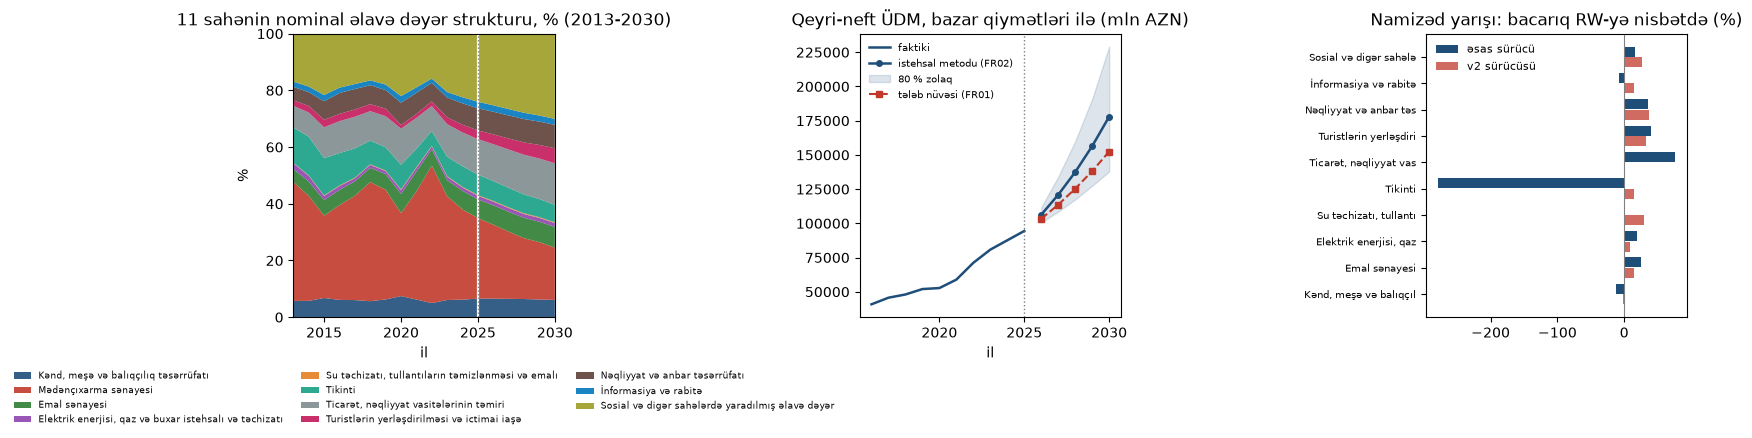

In [30]:
HIST_YEARS = list(range(2013, LA + 1))
share_hist = pd.DataFrame({c: VA[c].reindex(HIST_YEARS) for c in CODES})
share_hist_pct = share_hist.div(share_hist.sum(axis=1), axis=0) * 100
share_fc = pd.DataFrame({c: (VA_NOM[c] if c != "mining" else VA_MINING_FC) for c in CODES})
share_fc_pct = share_fc.div(share_fc.sum(axis=1), axis=0) * 100
share_all = pd.concat([share_hist_pct, share_fc_pct])

palette = ["#1f4e79", "#c0392b", "#2e7d32", "#8e44ad", "#e67e22", "#16a085",
           "#7f8c8d", "#c2185b", "#5d4037", "#0277bd", "#9e9d24"]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
ax = axes[0]
ax.stackplot(share_all.index, [share_all[c].values for c in CODES],
             labels=[NAME[c] for c in CODES], colors=palette, alpha=0.9)
ax.axvline(LA, color="white", ls="-", lw=1.6)
ax.axvline(LA, color="grey", ls=":", lw=1.0)
ax.set_title("11 sahənin nominal əlavə dəyər strukturu, % (2013-2030)")
ax.set_ylabel("%"); ax.set_xlabel("il")
ax.set_xlim(2013, 2030); ax.set_ylim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False, fontsize=6.4)

ax = axes[1]
hist_line = GDP_NONOIL_MP_H.loc[2013:LA]
ax.plot(hist_line.index, hist_line.values, "-", color="#1f4e79", lw=1.8, label="faktiki")
ax.plot(GDP_NONOIL_MP.index, GDP_NONOIL_MP.values, "-o", color="#1f4e79", lw=1.8, ms=4,
        label="istehsal metodu (FR02)")
ax.fill_between(GDP_NONOIL_BANDS.index, GDP_NONOIL_BANDS["lo80"], GDP_NONOIL_BANDS["hi80"],
                color="#1f4e79", alpha=0.15, label="80 % zolaq")
ax.plot(nonoil_fr1.index, nonoil_fr1.values, "--s", color="#c0392b", lw=1.5, ms=4,
        label="tələb nüvəsi (FR01)")
ax.axvline(LA, color="grey", ls=":", lw=1.0)
ax.set_title("Qeyri-neft ÜDM, bazar qiymətləri ilə (mln AZN)")
ax.set_xlabel("il"); ax.legend(frameon=False, fontsize=7.5)

ax = axes[2]
sk_new = [(_sk(bt_cmp[c], "ESAS") or 0) for c in NONOIL_CODES]
sk_old = [(_sk(bt_cmp[c], "KOHNE") or 0) for c in NONOIL_CODES]
xpos = np.arange(len(NONOIL_CODES))
ax.barh(xpos + 0.2, sk_new, height=0.38, color="#1f4e79", label="əsas sürücü")
ax.barh(xpos - 0.2, sk_old, height=0.38, color="#c0392b", alpha=0.75, label="v2 sürücüsü")
ax.set_yticks(xpos); ax.set_yticklabels([NAME[c][:22] for c in NONOIL_CODES], fontsize=7)
ax.axvline(0, color="grey", lw=0.8)
ax.set_title("Namizəd yarışı: bacarıq RW-yə nisbətdə (%)")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR02_struktur_uzlasdirma.png"), dpi=140, bbox_inches="tight")
plt.show()

## 9. DVX dövriyyə sətirləri — lövbər kimi çarpaz yoxlama (D5)

DVX vərəqinin sahə dövriyyəsi sətirləri (53–66) 2021–2025 dövrünü əhatə edir: beş müşahidə.
Bu sıralar üzərində elastiklik qiymətləndirilmir. Onlar burada YALNIZ **səviyyə lövbəri** kimi
işlədilir: sahə dövriyyəsinin əlavə dəyərə nisbəti hesablanır və 2026-cı il üçün eyni nisbətin
saxlanılıb-saxlanılmadığı yoxlanılır. Nisbətdə kəskin sürüşmə olarsa, bu, sahə tənliyinin
yenidən baxılması üçün siqnaldır — düzəliş mexanizmi deyil.

## 9a. Sürücüsüz qalan sahələrin YENİDƏN nəzərdən keçirilməsi (icmalın B7 ikinci keçidi)

İcmalın qeydi: «…informasiya və rabitə sektorunun real artım tempi proqnozlaşdırılarkən qeyri
neft-qaz ÜDM-in real artım tempi götürülmüşdür… sosial və digər xidmətlər sektorunun real artımı
proqnozlaşdırılarkən əhalinin real gəlirlərinin artımı götürülmüşdür… sahələrin proqnozlarına bir
daha baxılması məqsədəuyğundur.»

**Adı çəkilən iki dövrəvilik bu buraxılışda artıq yoxdur** — hər ikisi dövrəvilik qapısı ilə rədd
olunub (5-ci bölmənin cədvəlində `v2 dövrəvi? = BƏLİ` sətirləri): informasiya-rabitə üçün qeyri-neft
ÜDM artımı, sosial sahələr üçün əhalinin real gəlirləri. Sosial sahələr yerinə **orta aylıq pensiyanın
real artımını** aldı və o, qapıdan keçdi. İnformasiya-rabitə üçün isə sınanan iki namizədin hər ikisi
qapıdan keçmədi və sahə dinamika etalonunda qaldı — yəni qeyd həmin sahə üçün **hələ də açıqdır**.

Ona görə burada üçüncü bir keçid aparılır: struktur sürücüsü olmayan üç sahə (elektrik enerjisi, su
təchizatı, informasiya-rabitə) üçün dondurulmuş məlumat qatında qalan BÜTÜN sahə-spesifik namizədlər
eyni qapıdan keçirilir. Məqsəd namizəd tapmaq deyil — **axtarışın nəticəsini rəqəmlə sənədləşdirmək**:
hansı sıra sınandı, neçə müşahidə ilə, hansı əmsal və ehtimalla. Keçən olarsa, növbəti buraxılışda
sürücü xəritəsinə daxil edilir; keçən olmazsa, etalonun səbəbi məlumat boşluğu kimi qeyd olunur.

Bu xana **heç nə nəşr etmir** və mərkəzi yola toxunmur; yalnız diaqnostikadır.


In [31]:
# --- B7 İKİNCİ KEÇİD: struktur sürücüsü olmayan sahələr üçün qalan namizədlərin süpürülməsi ----
# Hər namizəd eyni qapıdan keçir: OLS+HAC, sürücü əmsalının p-dəyəri < GATE_P və gözlənilən işarə.
# Namizəd etiket-yoxlamalı sürücü siyahısında deyilsə, ondan tənlik qurulmur (D5: sətir nömrəsinə
# görə oxumaq qadağandır) — lakin iş kitabı registrindən onun yeri və uzunluğu göstərilir ki,
# axtarışın nə tapdığı və nəyin çatışmadığı eyni cədvəldə görünsün.
_REG = data_layer.wb_registry().set_index("series_code")


def _reg_note(code):
    if code not in _REG.index:
        return "registrdə yoxdur"
    r = _REG.loc[code]
    return (f"{r['sheet']}!{int(r['row'])} · {int(r['year_min'])}–{int(r['year_max'])} "
            f"({int(r['n_obs'])} müşahidə, əsasən aylıq)")


SWEEP = {
    "power": [("mədənçıxarma+enerji kredit portfeli, real", "money_r043", lambda: real_pct(d("money_r043"))),
              ("yanacaq-enerji kompleksinə büdcə xərcləri", "fiscal_r086", None),
              ("elektrik enerjisi haqqının ödənilməsi (büdcə)", "fiscal_r114", None)],
    "water": [("su təsərrüfatına büdcə xərcləri", "fiscal_r065", None),
              ("ərazilərin təmizlənməsi / çirkab su xərcləri", "fiscal_r079", None),
              ("su haqqının ödənilməsi (büdcə)", "fiscal_r116", None)],
    "ict":   [("DVX: informasiya-rabitə dövriyyəsi, real", "dvx_r065", lambda: real_pct(d("dvx_r065"))),
              ("DVX: informasiya-rabitə üzrə əmək müqavilələri", "dvx_r102", None),
              ("əsas telefon aparatlarının sayı", "8 vərəq 2.4.1.4.!218",
               lambda: g_pct(vq("Əsas telefon aparatlarının sayı", 218))),
              ("nəqliyyat və rabitəyə büdcə xərcləri", "fiscal_r082", None)],
}

sweep_rows = []
for _c, _cands in SWEEP.items():
    _y = GROW[_c].dropna()
    for _nm, _code, _fn in _cands:
        if _fn is None:                     # etiket-yoxlamalı sürücü siyahısında deyil
            sweep_rows.append({"sahə": _c, "namizəd": _nm, "n": 0, "β": np.nan, "p": np.nan,
                               "adj R²": np.nan, "nəticə": "sınanmır",
                               "səbəb": "etiket-yoxlamalı sürücü siyahısında deyil — " + _reg_note(_code)})
            continue
        _x = pd.Series(_fn()).astype(float).dropna()
        _n = int(len(_y.index.intersection(_x.index)))
        if _n < 6:
            sweep_rows.append({"sahə": _c, "namizəd": _nm, "n": _n, "β": np.nan, "p": np.nan,
                               "adj R²": np.nan, "nəticə": "qapıya buraxılmır",
                               "səbəb": f"ortaq illik müşahidə {_n} < 6"})
            continue
        _res, _, _ = fit_eq(_y, {"x": _x}, f"B7 sweep {_c}: {_nm}")
        _b, _p = float(_res.params["x"]), float(_res.pvalues["x"])
        _ok = (_p < GATE_P) and (_b > 0)
        sweep_rows.append({"sahə": _c, "namizəd": _nm, "n": _n, "β": round(_b, 3),
                           "p": round(_p, 4), "adj R²": round(float(_res.adj_r2), 3),
                           "nəticə": "KEÇDİ" if _ok else "keçmədi",
                           "səbəb": "" if _ok else ("p ≥ 0,10" if _p >= GATE_P else "işarə tərs")})

SWEEP_TBL = pd.DataFrame(sweep_rows)
print("B7 ikinci keçid — struktur sürücüsü olmayan üç sahədə qalan namizədlər:")
print(SWEEP_TBL.to_string(index=False))
_passed = SWEEP_TBL[SWEEP_TBL["nəticə"] == "KEÇDİ"]
_tested = SWEEP_TBL[SWEEP_TBL["nəticə"].isin(["KEÇDİ", "keçmədi"])]
print(f"\nsınanan namizəd: {len(_tested)}; qapıdan keçən: {len(_passed)}; "
      f"məlumat çatışmazlığına görə sınanmayan: {len(SWEEP_TBL) - len(_tested)}")
if len(_passed):
    print("Qapıdan keçən namizəd(lər) növbəti buraxılışda sürücü xəritəsinə daxil edilməlidir "
          "(bu icrada mərkəzi yol dəyişmir):")
    print(_passed.to_string(index=False))
else:
    print("Heç bir namizəd qapıdan keçmədi. Üç sahənin etalonda qalmasının səbəbi MODEL SEÇİMİ "
          "deyil, MƏLUMAT BOŞLUĞUDUR: sahə-spesifik kəmiyyətlərin ya etiket-yoxlanmış illik "
          "sırası yoxdur, ya da sırası tənlik qurmaq üçün çox qısadır.")
print("\nNƏ AÇARDI (məlumat sorğusuna gedən üç sətir): informasiya-rabitə üçün DVX-nin sahə "
      "dövriyyəsi 10 illik illik sıraya çatdıqda; su təchizatı üçün istehlak olunan suyun illik "
      "həcmi; elektrik enerjisi üçün istehsal sırasının hesabat qırılmasından təmizlənmiş variantı. "
      "Büdcə xərci sətirləri (fiscal_*) mövcuddur, lakin sürücü kimi qeydiyyatdan keçməyib və "
      "2019-dan başlayır — onlardan tənlik qurmaq üçün sıra qısadır.")


B7 ikinci keçid — struktur sürücüsü olmayan üç sahədə qalan namizədlər:
 sahə                                        namizəd  n      β      p  adj R²            nəticə                                                                                                        səbəb
power      mədənçıxarma+enerji kredit portfeli, real 19 -0.030 0.1028   0.026           keçmədi                                                                                                     p ≥ 0,10
power      yanacaq-enerji kompleksinə büdcə xərcləri  0    NaN    NaN     NaN          sınanmır         etiket-yoxlamalı sürücü siyahısında deyil — Fiskal sektor!86 · 2019–2026 (64 müşahidə, əsasən aylıq)
power  elektrik enerjisi haqqının ödənilməsi (büdcə)  0    NaN    NaN     NaN          sınanmır        etiket-yoxlamalı sürücü siyahısında deyil — Fiskal sektor!114 · 2019–2026 (64 müşahidə, əsasən aylıq)
water                su təsərrüfatına büdcə xərcləri  0    NaN    NaN     NaN          sınanmır         etik

In [32]:
DVX_MAP = {"agri": "dvx_r058", "manuf": "dvx_r057", "constr": "dvx_r059", "trade": "dvx_r060",
           "tourism": "dvx_r063", "transport": "dvx_r064", "ict": "dvx_r065", "social": "dvx_r066"}
anchor_rows = []
for c, code in DVX_MAP.items():
    trn = data_layer.wb_labelled(code)
    trn = trn[trn.index <= LA]
    ratio = (trn / VA[c].reindex(trn.index)).dropna()
    fc_va = float(VA_NOM[c].loc[2026])
    anchor_rows.append({
        "sahə": NAME[c], "DVX sətri": code,
        "dövriyyə/VA 2021": round(float(ratio.iloc[0]), 3) if len(ratio) else None,
        f"dövriyyə/VA {LA}": round(float(ratio.iloc[-1]), 3) if len(ratio) else None,
        "orta": round(float(ratio.mean()), 3) if len(ratio) else None,
        "implisit dövriyyə 2026 (orta nisbətlə)": round(fc_va * float(ratio.mean()), 1) if len(ratio) else None,
    })
print("DVX dövriyyə lövbəri (n=5, tənlik qurulmur):")
pd.DataFrame(anchor_rows)

DVX dövriyyə lövbəri (n=5, tənlik qurulmur):


,sahə,DVX sətri,dövriyyə/VA 2021,dövriyyə/VA 2025,orta,implisit dövriyyə 2026 (orta nisbətlə)
0,"Kənd, meşə və balıqçılıq təsərrüfatı",dvx_r058,0.264,0.269,0.261,2190.0
1,Emal sənayesi,dvx_r057,3.244,3.637,3.528,30657.8
2,Tikinti,dvx_r059,2.037,2.195,2.325,20784.2
3,"Ticarət, nəqliyyat vasitələrinin təmiri",dvx_r060,3.480,3.231,3.398,56264.3
4,Turistlərin yerləşdirilməsi və ictimai iaşə,dvx_r063,0.939,0.796,0.829,3658.6
5,Nəqliyyat və anbar təsərrüfatı,dvx_r064,1.074,1.011,1.066,10845.9
6,İnformasiya və rabitə,dvx_r065,1.613,1.773,1.696,4914.6
7,Sosial və digər sahələrdə yaradılmış əlavə dəyər,dvx_r066,0.598,0.832,0.741,23887.7


## 10. Nəticələrin ixracı

In [33]:
# --- GO və IC proqnozları (τ ilə) ---------------------------------------------------------------
VA_FC_ALL = {c: (VA_NOM[c] if c != "mining" else VA_MINING_FC) for c in CODES}
GO_FC, IC_FC = {}, {}
for c in CODES:
    GO_FC[c] = VA_FC_ALL[c] / TAU_FC[c]
    IC_FC[c] = GO_FC[c] - VA_FC_ALL[c]
print(f"GO və IC proqnozları τ ilə quruldu ({len(CODES)} sahə).")

GO və IC proqnozları τ ilə quruldu (11 sahə).


In [34]:
NAME_SUFFIX = {"go": "ümumi buraxılış", "ic": "aralıq istehlak", "va": "əlavə dəyər",
               "g": "əlavə dəyərin real artım tempi"}
fl = []


def _add_level(prefix, code, hist, fc, unit="mln AZN"):
    nm = f"{NAME[code]} — {NAME_SUFFIX[prefix]}"
    for y, v in hist.items():
        fl.append({"fr": "FR2", "series_code": f"{prefix}_{code}", "series_name_az": nm, "unit": unit,
                   "year": int(y), "kind": "actual", "source": "ours", "value": float(v),
                   "lo80": None, "hi80": None, "lo50": None, "hi50": None})
    for y in FY:
        fl.append({"fr": "FR2", "series_code": f"{prefix}_{code}", "series_name_az": nm, "unit": unit,
                   "year": int(y), "kind": "forecast", "source": "ours", "value": round(float(fc.loc[y]), 3),
                   "lo80": None, "hi80": None, "lo50": None, "hi50": None})
    mb = data_layer.ministry_baseline(f"{prefix}_{code}")
    for y, v in mb.items():
        fl.append({"fr": "FR2", "series_code": f"{prefix}_{code}", "series_name_az": nm, "unit": unit,
                   "year": int(y), "kind": "forecast", "source": "template_sample", "value": float(v),
                   "lo80": None, "hi80": None, "lo50": None, "hi50": None})


def _add_rate(prefix, code, hist, fc, bands, unit="%"):
    nm = f"{NAME[code]} — {NAME_SUFFIX['g']}" if prefix == "g" else f"{NAME[code]} — deflyator"
    for y, v in hist.items():
        fl.append({"fr": "FR2", "series_code": f"{prefix}_{code}", "series_name_az": nm, "unit": unit,
                   "year": int(y), "kind": "actual", "source": "ours", "value": float(v),
                   "lo80": None, "hi80": None, "lo50": None, "hi50": None})
    for y in FY:
        fl.append({"fr": "FR2", "series_code": f"{prefix}_{code}", "series_name_az": nm, "unit": unit,
                   "year": int(y), "kind": "forecast", "source": "ours",
                   "value": round(float(fc.loc[y]), 4),
                   "lo80": round(float(bands.loc[y, "lo80"]), 4), "hi80": round(float(bands.loc[y, "hi80"]), 4),
                   "lo50": round(float(bands.loc[y, "lo50"]), 4), "hi50": round(float(bands.loc[y, "hi50"]), 4)})
    if prefix == "g":
        for y, v in data_layer.ministry_baseline(f"g_{code}").items():
            fl.append({"fr": "FR2", "series_code": f"g_{code}", "series_name_az": nm, "unit": unit,
                       "year": int(y), "kind": "forecast", "source": "template_sample", "value": float(v),
                       "lo80": None, "hi80": None, "lo50": None, "hi50": None})


def _add_plain(code, nm, hist, fc, unit="mln AZN", bands=None, template=None):
    for y, v in pd.Series(hist).dropna().items():
        fl.append({"fr": "FR2", "series_code": code, "series_name_az": nm, "unit": unit,
                   "year": int(y), "kind": "actual", "source": "ours", "value": round(float(v), 3),
                   "lo80": None, "hi80": None, "lo50": None, "hi50": None})
    for y in FY:
        row = {"fr": "FR2", "series_code": code, "series_name_az": nm, "unit": unit,
               "year": int(y), "kind": "forecast", "source": "ours",
               "value": round(float(pd.Series(fc).loc[y]), 3),
               "lo80": None, "hi80": None, "lo50": None, "hi50": None}
        if bands is not None:
            for b in ("lo80", "hi80", "lo50", "hi50"):
                row[b] = round(float(bands.loc[y, b]), 3)
        fl.append(row)
    if template is not None:
        for y, v in pd.Series(template).dropna().items():
            fl.append({"fr": "FR2", "series_code": code, "series_name_az": nm, "unit": unit,
                       "year": int(y), "kind": "forecast", "source": "template_sample",
                       "value": float(v), "lo80": None, "hi80": None, "lo50": None, "hi50": None})


for c in CODES:
    _add_level("go", c, GO[c], GO_FC[c])
    _add_level("ic", c, IC[c], IC_FC[c])
    _add_level("va", c, VA[c], VA_FC_ALL[c])
    _add_rate("g", c, GROW[c], VA_CENTRAL[c], VA_BANDS[c])
    _add_rate("d", c, DEFL_HIST[c], DEFL_CENTRAL[c], DEFL_BANDS[c])

# xalis vergilər və blok bölgüsü
_add_plain("net_taxes", "Məhsula və idxala xalis vergilər", nt_hist, nt_nom_fc,
           template=data_layer.ministry_baseline("net_taxes"))
_add_plain("net_taxes_g", "Xalis vergilərin real artım tempi", nt_g_hist, nt_g_fc, unit="%",
           template=data_layer.ministry_baseline("net_taxes_g"))
_add_plain("net_taxes_oil", "Məhsula və idxala xalis vergilər — neft-qaz bloku", nt_oil_h, nt_oil_fc)
_add_plain("net_taxes_nonoil", "Məhsula və idxala xalis vergilər — qeyri neft-qaz bloku",
           nt_nonoil_h, nt_nonoil_fc)
_add_plain("net_taxes_phi", "Xalis vergilərin neft-qaz blokuna düşən payı (φ)",
           (nt_oil_h / nt_hist).dropna(), phi_fc, unit="pay")

# mədənçıxarmanın bölgüsü
_add_plain("va_mining_oilgas", "Mədənçıxarma — xam neft və qaz hasilatı üzrə əlavə dəyər",
           va_mine_og, VA_OG_FC)
_add_plain("va_mining_nonoil", "Mədənçıxarma — qeyri-neft hissəsi üzrə əlavə dəyər",
           va_mine_no, VA_MN_FC)

# aşağıdan-yuxarı aqreqatlar
_add_plain("va_nonoil_prod", "Qeyri-neft sektorunun əlavə dəyəri (istehsal metodu, əsas qiymətlərlə)",
           va_nonoil_h_full, VA_NONOIL_NOM)
_add_plain("gdp_nonoil_prod", "Qeyri-neft ÜDM, bazar qiymətləri ilə (istehsal metodu)",
           GDP_NONOIL_MP_H, GDP_NONOIL_MP, bands=GDP_NONOIL_BANDS)
_add_plain("gdp_nonoil_realg_prod", "Qeyri-neft ÜDM-in real artım tempi (istehsal metodu)",
           data_layer.actuals("nonoil_realg"), NONOIL_REALG, unit="%", bands=NONOIL_BANDS)
_add_plain("gdp_nonoil_defl_prod", "Qeyri-neft ÜDM-in deflyatoru (istehsal metodu)",
           data_layer.actuals("nonoil_defl"), NONOIL_DEFL, unit="%")
# DİQQƏT — tərif fərqi: iş kitabının `oil_nom` sırası BÜTÜN mədənçıxarma sənayesini neft-qaz
# blokuna aid edir; burada isə blok yalnız xam neft və qaz hasilatından ibarətdir, qeyri-neft
# mədənçıxarma (metal filizləri, digər mədənçıxarma, sahəyə xidmətlər) qeyri-neft blokundadır.
# Ona görə tarixi hissə də EYNİ tərifə görə qurulur (hasilat üzrə əlavə dəyər + neft xalis
# vergiləri), `oil_nom` olduğu kimi götürülmür — əks halda sıra 2025/2026 sərhədində qırılardı.
_add_plain("gdp_oilgas_prod", "Neft-qaz ÜDM, bazar qiymətləri ilə (istehsal metodu)",
           (va_mine_og + nt_oil_h).dropna(), GDP_OILGAS_MP)
_add_plain("gdp_prod", "ÜDM, bazar qiymətləri ilə (istehsal metodu)",
           data_layer.actuals("gdp_nom"), GDP_MP)
_add_plain("gdp_nonoil_gap", "Qeyri-neft ÜDM: istehsal metodu ilə tələb nüvəsinin fərqi",
           pd.Series(dtype=float), GAP)

# sənayenin neft/qeyri-neft bölgüsü, aşağıdan-yuxarı (istehsal metoduna keçid)
ind_nonoil_h = sum(VA[c] for c in INDUSTRY_NONOIL) + va_mine_no
ind_nonoil_fc = sum(VA_NOM[c] for c in INDUSTRY_NONOIL) + VA_MN_FC
_add_plain("va_industry_nonoil_prod", "Qeyri neft-qaz sənayesi — əlavə dəyər (aşağıdan-yuxarı)",
           ind_nonoil_h.dropna(), ind_nonoil_fc)
_add_plain("va_industry_oil_prod", "Neft-qaz sənayesi — əlavə dəyər (aşağıdan-yuxarı)",
           va_mine_og, VA_OG_FC)

fl_df = pd.DataFrame(fl)
outputs.write_forecast_long(fl_df)
print(f"forecast_long.csv-ə {len(fl_df)} sətir yazıldı (fr=FR2, {fl_df['series_code'].nunique()} seriya)")
fl_df.tail(4)

forecast_long.csv-ə 2108 sətir yazıldı (fr=FR2, 71 seriya)


,fr,series_code,series_name_az,unit,year,kind,source,value,lo80,hi80,lo50,hi50
2104,FR2,va_industry_oil_prod,Neft-qaz sənayesi — əlavə dəyər (aşağıdan-yuxarı),mln AZN,2027,forecast,ours,30733.773,NaN,NaN,NaN,NaN
2105,FR2,va_industry_oil_prod,Neft-qaz sənayesi — əlavə dəyər (aşağıdan-yuxarı),mln AZN,2028,forecast,ours,30546.588,NaN,NaN,NaN,NaN
2106,FR2,va_industry_oil_prod,Neft-qaz sənayesi — əlavə dəyər (aşağıdan-yuxarı),mln AZN,2029,forecast,ours,32196.060,NaN,NaN,NaN,NaN
2107,FR2,va_industry_oil_prod,Neft-qaz sənayesi — əlavə dəyər (aşağıdan-yuxarı),mln AZN,2030,forecast,ours,32524.666,NaN,NaN,NaN,NaN


In [35]:
# --- fərziyyə faylına sahə sürücülərinin yolları (D1) ------------------------------------------
rows_a = []
# Hər açar üçün AÇIQ göstərilir ki, ona bağlı tənlik mərkəzi yolda SAXLANILIB, yoxsa yox:
# qapıdan keçməyən və ya sınaqda saxlanılmayan tənliyin sürücü yolu heç bir nəticəni idarə etmir
# və fərziyyə faylında yalnız audit izi kimi qalır.
for c in NONOIL_CODES:
    for t in TAGS[c]:
        nm, key = CAND_NAME[c][t], CAND_KEY[c][t]
        if _is_upstream(key):
            continue
        used = (t == CHOSEN[c]) and (t in bt_va[c].weights)
        if used:
            note_tag = ("istifadə olunur (sahə tənliyi ansambldadır, çəki "
                        f"{bt_va[c].weights.get(t, 0):.2f})")
        elif t == CHOSEN[c]:
            note_tag = "SEÇİLİB, lakin tənlik ansamblda saxlanılmadı — yol audit izi kimi verilir"
        else:
            note_tag = ("İSTİFADƏ OLUNMUR — namizəd qapıdan keçmədi və ya sınaqda uduzdu, "
                        "yol audit izi kimi verilir")
        for y in FY:
            rows_a.append({"assumption_key": key, "year": int(y),
                           "value": round(float(DRV_FC_ALL[c][t].loc[y]), 4), "unit": "%",
                           "note": f"{NAME[c]} sürücüsü [{t}] — {nm}; {DRV_NOTE_ALL[c][t]}; {note_tag}"})
for c in CODES:
    nm, hist, key = PRICE_DRV[c]
    if _is_upstream(key):
        continue
    used = DEFL_PASS[c] and ("YENI" in bt_defl[c].weights)
    tag = ("istifadə olunur (deflyator tənliyi ansambldadır, çəki "
           f"{bt_defl[c].weights.get('YENI', 0):.2f})") if used else           "İSTİFADƏ OLUNMUR — qiymət termi qapıdan keçmədi və ya tənlik ansamblda saxlanılmadı"
    for y in FY:
        rows_a.append({"assumption_key": key, "year": int(y), "value": round(float(PRC_FC[c].loc[y]), 4),
                       "unit": "%", "note": f"{NAME[c]} deflyatorunun qiymət termi — {nm}; {PRC_NOTE[c]}; {tag}"})
# AUDİT MÖHÜRÜ (ekzogen giriş DEYİL). Bu dəftər `gdp_nonoil_gap` sırasını FR01-in tələb
# nüvəsindən (`nonoil_realg_demand`) qurur. Boru xətti FR01-i İKİ dəfə işlədir (FR01 → FR02 →
# FR01); 1-ci keçiddə diskdəki FR2 sətirləri hələ ƏVVƏLKİ nüvə ilə qurulmuş olur. FR01 hansı
# keçiddə olduğunu bilmək üçün bu açarı oxuyur: burada YAZILAN dəyər məhz bu icrada İŞLƏDİLƏN
# nüvə yoludur, ona görə FR01-in yaddaşındakı nüvə ilə üst-üstə düşməsi faylın təzə olduğunu
# birmənalı göstərir. Heç bir tənlik bu açarı giriş kimi oxumur.
for y in FY:
    rows_a.append({"assumption_key": "fr02_nonoil_demand_used", "year": int(y),
                   "value": round(float(A["nonoil_realg_demand"].loc[y]), 6), "unit": "%",
                   "note": "AUDİT MÖHÜRÜ (ekzogen giriş deyil): FR02-nin `gdp_nonoil_gap` sırasını "
                           "qurarkən işlətdiyi tələb nüvəsi yolu; FR01 iki keçidli DAG-da faylın "
                           "təzəliyini bu açarla yoxlayır"})
outputs.write_assumptions(pd.DataFrame(rows_a))
print(f"assumptions.csv-ə {len(rows_a)} sətir yazıldı "
      f"({len(set(r['assumption_key'] for r in rows_a))} yeni açar)")

assumptions.csv-ə 130 sətir yazıldı (26 yeni açar)


In [36]:
# --- seriya lüğəti ------------------------------------------------------------------------------
dict_rows = []
for c in CODES:
    dict_rows.append({"series_code": f"d_{c}", "name_az": f"{NAME[c]} — deflyator",
                      "name_en": f"{c} sector — value added deflator", "unit": "%", "fr": "FR2",
                      "statutory_sheet_ref": "8 vərəq, 2.4.1.2.", "price_basis": "indeks"})
NT_REF = ("Real sektor, sətirlər 43-44 + blok səviyyələri; faktiki illərdə bölgü MÜŞAHİDƏDİR "
          "(XV_neft = neft-qaz ÜDM-i − mədənçıxarmanın əlavə dəyəri), proqnozda φ neft-qaz əlavə "
          f"dəyər payının gecikmiş dəyəri ilə dəyişir (φ({LA}) = {PHI0:.4f}); kalibrləmə, "
          "qiymətləndirilmiş əmsal deyil. DVX dolayı vergi payı (5 il) lövbər kimi çap olunur.")
EXTRA_DICT = [
    ("net_taxes_oil", "Məhsula və idxala xalis vergilər — neft-qaz bloku",
     "Net taxes on products — oil and gas block", "mln AZN", NT_REF, "cari"),
    ("net_taxes_nonoil", "Məhsula və idxala xalis vergilər — qeyri neft-qaz bloku",
     "Net taxes on products — non-oil block", "mln AZN", NT_REF, "cari"),
    ("net_taxes_phi", "Xalis vergilərin neft-qaz blokuna düşən payı (φ)",
     "Oil-gas share of net taxes", "pay", NT_REF, "indeks"),
    ("va_mining_oilgas", "Mədənçıxarma — xam neft və qaz hasilatı üzrə əlavə dəyər",
     "Mining — crude oil and gas extraction value added", "mln AZN",
     "Mədənçıxarma vərəqi, sətir 9; proqnoz FR05b həcm yolu (`oil_realg`) və `oil_defl` ilə", "cari"),
    ("va_mining_nonoil", "Mədənçıxarma — qeyri-neft hissəsi üzrə əlavə dəyər",
     "Mining — non-oil part value added", "mln AZN",
     "Mədənçıxarma vərəqi, sətir 4 mənfi sətir 9 (2016-dan)", "cari"),
    ("va_nonoil_prod", "Qeyri-neft sektorunun əlavə dəyəri (istehsal metodu)",
     "Non-oil value added, production approach", "mln AZN",
     "on sahənin əlavə dəyəri + mədənçıxarmanın qeyri-neft hissəsi; miqyaslama yoxdur. İş kitabının "
     "`nonoil_nom` sırasından qeyri-neft mədənçıxarmanın əlavə dəyəri qədər fərqlənir (2016-dan)", "cari"),
    ("gdp_nonoil_prod", "Qeyri-neft ÜDM, bazar qiymətləri ilə (istehsal metodu)",
     "Non-oil GDP at market prices, production approach", "mln AZN",
     "qeyri-neft əlavə dəyəri + (1−φ)×xalis vergilər; zolaq komponent OOS xətalarından "
     "(mühafizəkar, tam korrelyasiya konvensiyası)", "cari"),
    ("gdp_nonoil_realg_prod", "Qeyri-neft ÜDM-in real artım tempi (istehsal metodu)",
     "Non-oil GDP real growth, production approach", "%",
     "sahə həcm cəmlərinin nisbəti (ƏLAVƏ DƏYƏR bazası). TƏRİF QEYDİ: FAKTİKİ hissə statutar "
     "sıradır (bazar qiymətləri, bütün mədənçıxarma neft-qaz blokunda), proqnoz hissəsi isə "
     "aşağıdan-yuxarı əlavə dəyər aqreqatıdır (qeyri-neft mədənçıxarma qeyri-neft blokunda); "
     "bölgü yalnız 2016-dan mövcud olduğu üçün tarixi hissə eyni tərifə görə qurula bilmir — "
     "fərqin ölçüsü Bölmə 7.4-də çap olunur", "indeks"),
    ("gdp_nonoil_defl_prod", "Qeyri-neft ÜDM-in deflyatoru (istehsal metodu)",
     "Non-oil GDP deflator, production approach", "%",
     "nominal/real aqreqatların nisbəti (əlavə dəyər bazası); faktiki hissənin tərif qeydi "
     "`gdp_nonoil_realg_prod` ilə eynidir", "indeks"),
    ("gdp_oilgas_prod", "Neft-qaz ÜDM, bazar qiymətləri ilə (istehsal metodu)",
     "Oil-gas GDP at market prices, production approach", "mln AZN",
     "xam neft və qaz hasilatı üzrə əlavə dəyər (FR05b yolu) + φ×xalis vergilər. TƏRİF FƏRQİ: "
     "iş kitabının `oil_nom` sırasından fərqli olaraq qeyri-neft mədənçıxarma bu blokda DEYİL, "
     "qeyri-neft blokundadır; tarixi hissə də eyni təriflə qurulub (2016-dan)", "cari"),
    ("gdp_prod", "ÜDM, bazar qiymətləri ilə (istehsal metodu)",
     "GDP at market prices, production approach", "mln AZN",
     "qeyri-neft + neft-qaz bloklarının cəmi", "cari"),
    ("gdp_nonoil_gap", "Qeyri-neft ÜDM: istehsal metodu ilə tələb nüvəsinin fərqi",
     "Non-oil GDP: production minus demand-core", "mln AZN",
     "FR02 (istehsal metodu, baş göstərici) − FR01 (tələb nüvəsi); miqyaslama əvəzinə nəşr olunan fərq", "cari"),
    ("va_industry_nonoil_prod", "Qeyri neft-qaz sənayesi — əlavə dəyər (aşağıdan-yuxarı)",
     "Non-oil industry value added, bottom-up", "mln AZN",
     "emal + elektrik + su + qeyri-neft mədənçıxarma", "cari"),
    ("va_industry_oil_prod", "Neft-qaz sənayesi — əlavə dəyər (aşağıdan-yuxarı)",
     "Oil-gas industry value added, bottom-up", "mln AZN", "FR05b bloku", "cari"),
]
for code, az, en, unit, ref, pb in EXTRA_DICT:
    dict_rows.append({"series_code": code, "name_az": az, "name_en": en, "unit": unit,
                      "fr": "FR2", "statutory_sheet_ref": ref, "price_basis": pb})
dict_df = pd.DataFrame(dict_rows)
outputs.write_series_dictionary(dict_df)
print(f"series_dictionary.csv-ə {len(dict_df)} kod yazıldı")

# D2 — ƏSASLANDIRMANIN NƏŞRİ. Kataloqun `description` sütununa əlavə olaraq göstəricinin dəyəri
# və səbəbi seriya lüğətinin qeyd sütununa da yazılır (bütün dəftərlərdə eyni funksiya).
# Çağırış lüğət YAZILDIQDAN SONRA olmalıdır: funksiya mövcud sətrin qeydinə əlavə edir, yeni
# sətir yaratmır — əks halda sahə deflyatorları hələ lüğətdə olmadığı üçün atlanardı.
outputs.publish_dynamics_notes(dyn_metric)

series_dictionary.csv-ə 25 kod yazıldı
D2: 24 sıra üçün dinamiklik əsaslandırması seriya lüğətinə yazıldı


,series_code,name_az,name_en,unit,fr,statutory_sheet_ref,price_basis
0,agri_export_russia_share,Kənd təsərrüfatı ixracında top-1 ölkənin (Rusi...,Kənd təsərrüfatı ixracında top-1 ölkənin (Rusi...,%,FR11,Ticarət (əsas iş kitabı),indeks
1,bop_total_balance,Tədiyə balansının ümumi balansı (BPM6 eyniliyi...,"BoP total balance (identity, zero by construct...",mln USD,FR12,"8 vərəq, 2.4.1.13.-14.",cari
2,brent_breakeven_ca0,Cari hesabın sıfırlandığı Brent qiyməti (break...,Break-even Brent price for CA = 0,USD/barel,FR12,"8 vərəq, 2.4.1.13.-14.",cari
3,brent_usd,Neftin dünya bazarında qiyməti (Brent),World oil price (Brent),USD/barel,FR5,"8 vərəq, 2.4.1.5.-7.",cari
4,budget_balance,Dövlət büdcəsinin kəsiri/profisiti,State budget balance,mln AZN,FR6,"Fiskal sektor, sətir 21; FAKTİKİ sıra — proqno...",cari
...,...,...,...,...,...,...,...
676,wage_ssc_water,Su təchizatı; tullantıların təmizlənməsi və em...,Water supply; waste treatment and disposal — a...,AZN,FR8,"DSK cədvəl 4.5–4.8 (`004_5-8en.xls`, `Dynamics...",cari
677,wage_ssc_water_nonstate,Su təchizatı; tullantıların təmizlənməsi və em...,Water supply; waste treatment and disposal — a...,AZN,FR8,"DSK cədvəl 4.5–4.8 (`004_5-8en.xls`, `Dynamics...",cari
678,wage_ssc_water_state,Su təchizatı; tullantıların təmizlənməsi və em...,Water supply; waste treatment and disposal — a...,AZN,FR8,"DSK cədvəl 4.5–4.8 (`004_5-8en.xls`, `Dynamics...",cari
679,wage_state,Dövlət sektorunda orta aylıq əmək haqqı,"Average wage, state sector",AZN,FR8,Sosial sektor,cari


In [37]:
# --- tənliklər kataloqu -------------------------------------------------------------------------
WB = "Statistik data dinamika 05.06.2026 +.xlsx"
cat_rows = []
for c in NONOIL_CODES:
    # Hər namizəd ayrıca sətirdir: seçilən STRUKTUR, seçilməyən RƏDD EDİLDİ nişanı ilə (D3 —
    # rədd edilən namizəd kataloqdan silinmir, bacarığı ilə birlikdə qalır).
    for tag in TAGS[c]:
        res = VA_RES[c][tag]
        if res is None:
            continue
        chosen = (CHOSEN[c] == tag)
        status = "STRUKTUR (seçilmiş)" if chosen else "RƏDD EDİLDİ"
        eq_nm = f"FR2_va_{c}" if tag == "ESAS" else f"FR2_va_{c}_alt"
        if chosen:
            res = DYN_RES[c] if DYN_RES[c] is not None else res
            xcp = DYN_XCP[c] if DYN_XCP[c] is not None else VA_XC[c][tag]
            _dyn = _dyn_desc(c)
        else:
            xcp = VA_XC[c][tag]
            _dyn = ""
        cat_rows.append(res.catalog_row(
            eq_name=eq_nm, lhs=f"g_{c}", series_code=f"g_{c}", fr="FR2", workbook=WB,
            sheet="Real sektor",
            description=(f"{status} [{tag}]: {NAME[c]} əlavə dəyərinin real artımı ← "
                         f"{CAND_NAME[c][tag]}. Qapı: {'keçdi' if VA_PASS[c][tag] else 'keçmədi'}; "
                         f"namizəd yarışında bacarıq: {_sk(bt_cmp[c], tag)} % "
                         f"(ortaq pəncərə); qərar: {VA_DECISION[c]}"
                         + (f"; {VA_LOSS[c]}" if VA_LOSS[c] else "")
                         + _dyn
                         + (f"; ansambl: {VA_SRC[c]}" if chosen else "")
                         + (f"; dinamiklik göstəricisi {DYN_RATIO[f'g_{c}']:.3f}"
                            if chosen and f"g_{c}" in DYN_RATIO else "")
                         + (f"; {DYN_JUST[f'g_{c}']}" if chosen and DYN_JUST.get(f"g_{c}") else "")),
            # SÜRÜCÜNÜN ADI KODUN YANINDA: kataloqu oxuyan yalnız `rhs` sütununa baxdıqda
            # `drv_ict_subs_g` kimi bir kod görürdü və sahə-spesifikliyi seçə bilmirdi (icmalın
            # B7/B8 qeydləri məhz buna aiddir). Ad `description`-da onsuz da var; burada
            # təkrarlanır ki, sütunun özü oxunaqlı olsun.
            rhs=" + ".join((f"{CAND_KEY[c][tag]} [{CAND_NAME[c][tag]}]" if q == "x" else
                            (f"g_{c}(-1)" if q == "lag" else q)) for q in xcp)
                if DYN_FORM.get(c) != "ECM" or not chosen
                else (f"ECM: ln VA ~ ln({CAND_KEY[c][tag]} [{CAND_NAME[c][tag]}]) "
                      "[uzunmüddətli] + Δ [qısamüddətli]")))
    # v2 sürücüsü ilə tənlik — müqayisə sətri kimi saxlanılır
    if VA_RES_OLD[c] is not None:
        cat_rows.append(VA_RES_OLD[c].catalog_row(
            eq_name=f"FR2_va_{c}_v2suruce", lhs=f"g_{c}", series_code=f"g_{c}", fr="FR2",
            workbook=WB, sheet="Real sektor",
            description=(f"MÜQAYİSƏ (v2 sürücüsü): {NAME[c]} ← {OLD_LABEL[OLD_KEY[c]]}; "
                         f"namizəd yarışında bacarıq: {_sk(bt_cmp[c], 'KOHNE')} %; "
                         + ("DÖVRƏVİ — istifadə edilmir (dövrəvilik qadağası, D2)" if OLD_KEY[c] in CIRCULAR
                            else ("ansamblda saxlanılıb" if "KOHNE" in bt_va[c].weights
                                  else "qapıdan keçmədi və ya sınaqda saxlanılmadı"))),
            rhs=f"{OLD_FC_KEY[OLD_KEY[c]]} [{OLD_LABEL[OLD_KEY[c]]}]"))
for c in CODES:
    res = DEFL_RES_NEW[c]
    cat_rows.append(res.catalog_row(
        eq_name=f"FR2_defl_{c}", lhs=f"d_{c}", series_code=f"d_{c}", fr="FR2", workbook=WB,
        sheet="Real sektor",
        description=(f"STRUKTUR: {NAME[c]} deflyatoru ← İQİ"
                     + (" + gecikmiş deflyator (`eq_dfpi_az` forması, Nazirliyin öz tənliyi)" if DEFL_LAG_USED[c] else "")
                     + (f" + {PRICE_DRV[c][0]}" if DEFL_PASS[c] else " (sahə qiymət termi qapıdan keçmədi)")
                     + f"; dinamika forması: {DEFL_FORM[c]} (statik "
                       f"{_skdyn(bt_defl_dyn[c], 'STATIK')} % / gecikməli "
                       f"{_skdyn(bt_defl_dyn[c], 'GECIKME')} % / ECM "
                       f"{_skdyn(bt_defl_dyn[c], 'ECM')} %)"
                     + f"; sınaq bacarığı: {_sk(bt_defl[c], 'YENI')} % (v2 İQİ+Brent: "
                       f"{_sk(bt_defl[c], 'KOHNE')} %); ansambl: {DEFL_SRC[c]}"
                     + (f"; dinamiklik göstəricisi {DYN_RATIO[f'd_{c}']:.3f}"
                        if f"d_{c}" in DYN_RATIO else "")
                     + (f"; {DYN_JUST[f'd_{c}']}" if DYN_JUST.get(f"d_{c}") else "")),
        rhs=" + ".join(("cpi" if q == "cpi" else
                        (f"{PRICE_DRV[c][2]} [{PRICE_DRV[c][0]}]" if q == "p"
                         else (f"d_{c}(-1)" if q == "lag" else q)))
                       for q in DEFL_XCOLS[c])))
cat_rows.append(res_mn.catalog_row(
    eq_name="FR2_va_mining_nonoil", lhs="va_mining_nonoil_g", series_code="va_mining_nonoil",
    fr="FR2", workbook=WB, sheet="Mədənçıxarma",
    description=("Qeyri-neft mədənçıxarmanın nominal artımı ← tikinti-quraşdırma işləri; "
                 f"qapı: {'keçdi' if mn_pass else 'keçmədi'}; mərkəzi yol: {MN_SRC}"),
    rhs="real_r110"))
cat_rows.append(res_nt.catalog_row(
    eq_name="FR2_defl_net_taxes", lhs="net_taxes_defl", series_code="net_taxes", fr="FR2",
    workbook=WB, sheet="Real sektor",
    description=("Nazirliyin `eq_def_ntp` tənliyinin uyğunlaşdırılmış variantı: xalis vergi "
                 "deflyatoru ← İQİ + Δln neftin qiyməti + tərəfdaş ölkələrin artımı"),
    rhs="cpi_infl + dln_brent + partner_gdp_realg"))
cat_rows.append({
    "workbook": "", "sheet": "", "eq_name": "FR2_nonoil_agregasiya",
    "description": ("EYNİLİK (tənlik deyil): qeyri-neft ÜDM (bazar qiym.) = 11 sahənin əlavə "
                    "dəyərinin cəmi + (1−φ)×xalis vergilər. Miqyaslama yoxdur; FR01 tələb nüvəsi "
                    "ilə fərq `gdp_nonoil_gap` sırası kimi nəşr olunur."),
    "lhs": "gdp_nonoil_prod", "rhs": "Σ va_i + (1−φ)·net_taxes", "series_code": "gdp_nonoil_prod",
    "fr": "FR2", "sample_start": int(LA), "sample_end": int(config.LAST_FORECAST),
    "adj_r2": None, "se_regression": None})

cat_df = pd.DataFrame(cat_rows)
outputs.write_equations_catalog(cat_df)
print(f"equations_catalog.csv-ə {len(cat_df)} sətir yazıldı (fr=FR2)")
cat_df[["eq_name", "lhs", "rhs", "sample_start", "sample_end", "adj_r2"]]

equations_catalog.csv-ə 40 sətir yazıldı (fr=FR2)


,eq_name,lhs,rhs,sample_start,sample_end,adj_r2
0,FR2_va_agri,g_agri,drv_agri_g [bitkiçilik və heyvandarlıq fiziki ...,2014,2024,0.4161
1,FR2_va_agri_v2suruce,g_agri,nonoil_realg [qeyri-neft ÜDM-in real artımı (D...,2013,2025,-0.0873
2,FR2_va_manuf,g_manuf,drv_manuf_g [qeyri-neft mal ixracı (DVX dövriy...,2011,2025,0.1623
3,FR2_va_manuf_v2suruce,g_manuf,g_inv_core [investisiyanın real artımı],2001,2025,0.0665
4,FR2_va_power,g_power,drv_power_g [elektrik enerjisi istehsalının fi...,2014,2024,-0.0498
5,FR2_va_power_v2suruce,g_power,g_inv_core [investisiyanın real artımı],2001,2025,0.2029
6,FR2_va_water,g_water,drv_water_g [büdcənin infrastruktur əsaslı vəs...,2017,2025,-0.1428
7,FR2_va_water_alt,g_water,drv_water_pop_g [əhalinin orta illik sayı] + d15,2010,2025,0.1179
8,FR2_va_water_v2suruce,g_water,g_inv_core [investisiyanın real artımı],2010,2025,0.0171
9,FR2_va_constr,g_constr,drv_constr_state_g [dövlət büdcəsinin əsaslı v...,2011,2025,-0.0195


In [38]:
bt_all = pd.concat(bt_rows_all, ignore_index=True)
# Ümumi pəncərəsi minimal nöqtə tələbini ödəməyən modellərin RMSE-si hesablanmır (`rmse_h` boş
# qalır) — məsələn sürücü sırası qısa olduğu üçün cəmi iki proqnoz nöqtəsi verən namizədlər.
# Belə sətirlər NƏŞR EDİLMİR: dashboard-da boş RMSE ilə model göstərmək yanıltıcı olardı.
# Sayı gizlədilmir, aşağıda çap olunur.
_drop = int(bt_all["rmse_h"].isna().sum())
bt_pub = bt_all.dropna(subset=["rmse_h"]).copy()
# DINAMIKLIK sətirləri eyni faylda, eyni müqavilə sütunları ilə
# `ek.dynamics_rows(...)` bəzi sütunları tam boş (all-NA) qaytarır; obyekt tipli belə çərçivə
# konkatenasiyada pandas FutureWarning verir. Sütunlar açıq şəkildə ədədi tipə çevrilir.
_dyn_df = ek.dynamics_rows(dyn_metric)
for _col in ("actual", "forecast", "error", "abs_error", "rmse_h", "rw_rmse_h", "coverage80"):
    if _col in _dyn_df.columns:
        _dyn_df[_col] = pd.to_numeric(_dyn_df[_col], errors="coerce")
bt_pub = pd.concat([bt_pub, _dyn_df], ignore_index=True)
outputs.write_backtest(bt_pub)
print(f"validation_backtest.csv-ə {len(bt_pub)} sətir yazıldı "
      f"({bt_pub['series_code'].nunique()} seriya, {bt_pub['model'].nunique()} model); "
      f"o cümlədən {len(dyn_metric)} DINAMIKLIK sətri; "
      f"RMSE-si hesablanmayan {_drop} sətir nəşrdən kənarda saxlanıldı "
      f"(ümumi sınaq pəncərəsi minimal nöqtə tələbini ödəmir)")

validation_backtest.csv-ə 2395 sətir yazıldı (53 seriya, 11 model); o cümlədən 24 DINAMIKLIK sətri; RMSE-si hesablanmayan 2 sətir nəşrdən kənarda saxlanıldı (ümumi sınaq pəncərəsi minimal nöqtə tələbini ödəmir)


## 11. Məhdudiyyətlər

**Sürücü yollarının mənbəyi.** Sahə sürücülərinin və sahə qiymət sıralarının 2026–2030 yolu
Nazirliyin planı deyil, bu dəftərin öz proyeksiyasıdır (AR(1)/orta/makro/RW ansamblı). Yollar
`assumptions.csv`-də ayrıca açarlarla — həm seçilmiş, həm seçilməmiş namizəd üçün — saxlanılır və
hər açarın qeydində onun mərkəzi yolu idarə edib-etmədiyi yazılır; rəsmi sahə proqnozları daxil
olduqda açarlar birbaşa əvəzlənə bilər (R9). Bu, sahə tənliyinin qiymətləndirilməsinə təsir etmir —
yalnız proqnoz üfüqündəki girişə aiddir.

**Qısa nümunələr və iki mərhələli sınaq.** Namizəd yarışı bütün namizədləri EYNİ pəncərədə
tutuşdurur; pəncərə ən qısa sıra ilə müəyyən olunur və **dörd sahədə** (kənd təsərrüfatı, elektrik
enerjisi, nəqliyyat, informasiya-rabitə) cəmi dörd ildir, çünki 8 vərəqin natural göstərici blokları
2013–2024 dövrünü əhatə edir və 2024-də bitir. Ona görə mərkəzi yolu quran modellər AYRICA, öz
(daha uzun) pəncərəsində yenidən sınaqdan keçirilir və ansambl çəkiləri ilə σ₁ məhz həmin ikinci
sınaqdan gəlir. Hər iki nəticə nəşr olunur (`g_<sahə>_namizedler` və `g_<sahə>` kodları ilə).
Sınaq üçün minimal təlim uzunluğu 8-dən 7-yə endirilib — bu, qısa sıraların ümumiyyətlə sınaqdan
keçirilə bilməsi üçündür və bütün sahələrə eyni tətbiq olunur.

**Qapıdan keçən, lakin etalonu üstələməyən sürücülər.** İki sahədə — kənd təsərrüfatı (−11,5 %)
və tikinti (−21,5 %) — seçilmiş sürücü qərar cədvəlinin qısa pəncərəsində təsadüfi gəzişməni
üstələmir. Bu, cədvəldə artıq açıq nişanlanır və iki mexanizm onu düzəldir: (i) 6.1-in forma
yarışı həmin sahələrdə daha yaxşı formanı seçir (kənd təsərrüfatında gecikməli forma +9,4 %,
tikintidə ECM +56,7 % — hər ikisi öz uzun pəncərəsində), (ii) ansambl qaydası RW-ni üstələməyən
modeli kənarlaşdırır və çəkini sağ qalanlara paylayır. Yəni mənfi bacarıqlı namizəd mərkəzi yolu
tək başına daşımır; buna baxmayaraq rəqəm gizlədilmir.

**DVX sıraları.** Sahə dövriyyəsi və dolayı vergi sətirləri beş illikdir. Onların üzərində heç bir
elastiklik qiymətləndirilmir (D5); yalnız lövbər və çarpaz yoxlama kimi işlədilir. Emal sənayesi
üçün adlandırılmış sürücü məhz həmin sətirlərdən biridir (DVX 57), ona görə sahədə
sənədləşdirilmiş əvəzedici (qeyri-neft mal ixracı) işlədilir. Geriyə tarixçə (2010–2020) daxil
olarsa, emal sənayesi və informasiya-rabitə üçün sürücü namizədləri yenidən sınaqdan
keçirilməlidir.

**Kənd təsərrüfatının həcm indeksi.** Statutar şablon məhsul qiymətlərini vermir, ona görə
bitkiçilik və heyvandarlıq yarım-indeksləri bərabər çəki ilə birləşdirilib. Bu, konvensiyadır;
məhsul dəyər çəkiləri daxil olarsa, indeks yenidən qurulmalıdır.

**Elektrik enerjisi və su təchizatı.** Hər iki sahə üçün göstərilən istehsalçı qiymət
indeksləri (Real sektor 192–193) yalnız 2021-dən mövcuddur (5 müşahidə) və D5 üzrə deflyator
tənliyində istifadə edilmir; onların yerinə sahə buraxılışının implisit deflyatoru (Real sektorun
59/60 və 61/62 sətir cütləri, 2005-dən) işlədilir və 189–193 sətirləri lövbər kimi yan-yana çap
olunur. Elektrik enerjisi sahəsində adlandırılmış sürücü (istehsalın fiziki həcmi) **qapıdan
keçmir** — əmsal mənfidir. Səbəb yalnız statistik deyil: 8 vərəqin elektrik istehsalı sırasında
**hesabat qırılması** var (2018–2019-cu illər ~5,6–6,2 min QVt.s, qonşu illər isə ~22–25 min
QVt.s; 2020-ci ildə +256 % "artım"), üstəlik sıra hidroelektrik stansiyalarını əhatə etmir.
Qırılma düzəldilmir — mənbəyə əl gəzdirilmir; sıra Bölmə 2.5-in qırılma sütununda nişanlanır və
sürücü kimi istifadə edilmir. Sahədə v2 sürücüsü (investisiyanın real artımı) saxlanılır. Su təchizatında nə DİP infrastruktur xərcləri, nə əhali sayı, nə də v2 sürücüsü qapıdan
keçir; mərkəzi yol dinamik etalondur.

**Tikintidə iki termli forma.** Adlandırılmış sürücü xəritəsi tikinti üçün investisiyanın dövlət/qeyri-dövlət
bölgüsünü göstərir. Dövlət termi (büdcənin əsaslı vəsait qoyuluşu) ayrıca da, iki termli formada da
sınaqdan keçirilib: əmsalın işarəsi mənfidir və sınaq bacarığı kəskin mənfidir (Bölmə 6-nın
cədvəlləri). Səbəb 2018–2025 dövründə büdcə capex-inin ümumi investisiyadakı payının 60 %-dən
20 %-ə düşməsidir — dövlət termi tikinti fəaliyyətinin dövriliyini artıq izləmir. Sahə üçün
seçilmiş sürücü tikinti-quraşdırma işlərinin real həcmidir, lakin v2 sürücüsü (ümumi investisiya)
sınaqda ondan üstündür və ansamblda saxlanılır; itki qərar cədvəlində rəqəmlə göstərilib.

**Sosial xidmətlər üçün fiskal kanal.** adlandırılmış sürücü (dövlət büdcəsinin real cari
xərcləri) qapıdan keçmir (əmsal mənfi) və mərkəzi yola buraxılmır; sahə üçün icazəli ən yaxşı
sürücü orta pensiyanın real artımıdır. Diqqətəlayiq nüans: ortaq (qısa) pəncərədə cari xərclər
sürücüsünün sınaq bacarığı pensiya sürücüsündən yüksəkdir — yəni qapını keçməyən tənlik sınaqda
daha yaxşı çıxa bilər; qapı bilərəkdən saxlanılır, çünki işarəsi iqtisadi gözləntiyə zidd olan
əmsalla proqnoz vermək izah edilə bilməz. Fiskal kanal FR13 (fiskal blok) qurulduqdan sonra
funksional təsnifat sətirləri (təhsil, səhiyyə — 2019-dan) ilə yenidən sınaqdan keçirilməlidir.

**İnformasiya-rabitə.** adlandırılmış sürücülərin heç biri (abunəçi sayı, telekomunikasiya
xidmətləri ixracı) qapıdan keçmir; sahənin mərkəzi yolu dinamik etalonlardır. Əvvəlki aralıq
həlldə burada əhaliyə göstərilən ödənişli xidmətlərin aqreqatı işlədilirdi — informasiya-rabitə
həmin aqreqatın TƏRKİB HİSSƏSİDİR, ona görə bu sürücü D2-nin dövrəvilik qadağasına yaxın düşür və
istifadə edilmir. Sahə dövriyyəsinin geriyə tarixçəsi (DVX, 2010–2020) daxil olduqda sürücü
namizədləri yenidən sınaqdan keçirilməlidir.

**Kənd təsərrüfatı deflyatorunun qida-qiymət termi.** `eq_dfpi_az` (Nazirliyin öz tənliyi) forması üç mənbə ilə
sınaqdan keçirilib: iş kitabının rəsmi kənd təsərrüfatı istehsalçı qiymət indeksi (sətir 194),
Nazirliyin `MOE AGRI` nümunə faylından dəyər çəkiləri ilə qurulmuş indeks və dünya ərzaq qiymətləri
(`FPI_WEO`). Seçilən sıra rəsmi indeksdir: MOE faylından qurulan indeks onunla 0,94 korrelyasiya
verir (yəni konstruksiyanı müstəqil təsdiq edir), lakin **2024-də bitir** və 2010-cu ildə
metodoloji qırılma daşıyır; nümunə-model faylının 2025–2030 sütunları isə proqnozdur və
işlədilmir. Dünya ərzaq qiymətləri termi əhəmiyyətsizdir.

**İki oxunuş.** Qeyri-neft ÜDM-in istehsal metodu ilə hesablanmış yolu ilə FR01-in tələb nüvəsinin
yolu arasındakı fərq `gdp_nonoil_gap` sırası kimi nəşr olunur. v2-də bu fərq miqyaslama ilə
bağlanırdı və görünmürdü. FR01-in çevrilməsi BU buraxılışda tamamlanıb: başlıq
göstəriciləri artıq yalnız istehsal metodundan gəlir, tələb nüvəsi isə xərc tərəfinin müstəqil
oxunuşu kimi saxlanılır və iki oxunuşun fərqi dözüm qapısı ilə izlənir (FR01, Bölmə 7.6).

**Aqreqat zolağı.** Zolaq komponentlərin nümunədən kənar xətalarından, sahələr arasında **tam
korrelyasiya** fərziyyəsi ilə qurulub (mühafizəkar konvensiya). Müstəqillik fərziyyəsi ilə zolaq
təxminən üç dəfə dar olardı; hər iki ölçü, üstəlik FR01 tələb nüvəsi zolağının implisit σ₁-i
Bölmə 7.5-də çap olunur.

**Üfüq qaydası düzəldilib (σ_h).** Əvvəlki buraxılışda bütün zolaqlar σ_h = σ₁·√h ilə
genişlənirdi — bu, SƏVİYYƏ qaydasıdır və xətaların yığıldığını fərz edir. Zolağa alınan
kəmiyyətlər isə artım templəri və deflyatorlardır; FR01, Bölmə 7.3 eyni obyekt üçün orta qiymətə
qayıdış qaydasını işlədirdi, yəni paketin iki dəftəri ziddiyyətli qayda tətbiq edirdi. İndi σ_h
dəftərin ÖZ çoxüfüqlü sınağından (`ek.path_backtest`, h = 1…5) BİRBAŞA götürülür. Ölçü
fərziyyəni təsdiqləyir: aqreqat üçün σ_h üfüq boyu düzdür (4,8 / 4,9 / 4,5 / 4,4 / 4,8 f.b.),
√h qaydası isə beşinci ildə 10,8 f.b. verirdi. Nəticədə 2030-cu il üçün qeyri-neft ÜDM-in 80 %
zolağı 115–271 mlrd AZN-dən 138–229 mlrd AZN-ə daralıb. Bu, baş göstəricinin zolağıdır və FR01
onu olduğu kimi oxuyur, ona görə düzəliş məcmu ÜDM zolağına da keçir.

**Qeyri-neft mədənçıxarmanın deflyatoru — açıq konvensiya.** Bu komponentin mənbədə yalnız
NOMİNAL əlavə dəyəri var (`Mədənçıxarma` vərəqi, r4−r9); ayrıca həcm və ya qiymət sırası yoxdur.
Əvvəlki buraxılışda nominal temp real zəncirə olduğu kimi qoyulurdu ("nominal ≈ real"), yəni
komponentə implisit SIFIR deflyator verilirdi; nəticədə qeyri-neft aqreqatının real artımı
yuxarı, deflyatoru isə eyni qədər aşağı sürüşürdü. İndi komponent İQİ ilə deflyasiya olunur —
bu, ölçü deyil, **açıq konvensiyadır** və metal filizlərinin qiymət dinamikası İQİ-dən fərqli
ola bilər. Təsiri kiçikdir, lakin sıfır deyil (çəki 2025-də 2,5 %): aqreqatın real artımı ~0,13
f.b. aşağı, deflyatoru ~0,14 f.b. yuxarı düşür; **nominal səviyyələr dəyişmir**, yəni
`gdp_nonoil_prod` və ondan asılı bütün səviyyə sıraları toxunulmur. Sahə üzrə həcm və ya qiymət
indeksi daxil olduqda konvensiya ölçü ilə əvəzlənməlidir.

**Qeyri-neft mədənçıxarma tənliyinin proqnoz sürücüsü.** Tənlik `real_r110` (tikinti-quraşdırma
işlərinin real həcmi) üzərində qiymətləndirilir; proqnoz budağında əvvəllər `g_inv_core` (ümumi
investisiya) yolu qoyulurdu, yəni bir dəyişənin yolu başqa dəyişənin əmsalına vurulurdu. Səhv
düzəldilib (indi `drv_constr_works_g` yolu işlədilir). Qapı hazırda keçilmədiyi üçün mərkəzi yol
onsuz da ETALON profilidir, deməli cari rəqəmlərə təsiri yoxdur — lakin səhv gizli qalırdı.

**Temp sıralarının tərif fərqi.** `gdp_nonoil_realg_prod` və `gdp_nonoil_defl_prod` sıralarının
FAKTİKİ hissəsi statutar sıradır (bazar qiymətləri, bütün mədənçıxarma neft-qaz blokunda),
PROQNOZ hissəsi isə bu dəftərin əlavə dəyər aqreqatıdır (qeyri-neft mədənçıxarma qeyri-neft
blokunda). SƏVİYYƏ sıralarında tarixi hissə eyni tərifə görə yenidən qurulur — temp sıralarında
bu mümkün deyil, çünki bölgü yalnız 2016-dan mövcuddur, statutar sıra isə 2013-dən nəşr olunur;
tarixi qısaltmaq daha böyük itki olardı. Fərqin ölçüsü Bölmə 7.4-də sətir-sətir çap olunur
(2017–2025 üzrə orta mütləq fərq ~0,5 f.b., maksimal ~0,8 f.b.). Bir ölçmə nəticəsi var və o,
açıq deyilməlidir: FR01-in Bölmə 6.1 sınağı aşağıdan-yuxarı yolu məhz STATUTAR hədəfə qarşı
ölçür, ona görə həmin bacarıq rəqəmində bu tərif fərqi də iştirak edir.

**İki tərif dəqiqləşdirməsi.** (i) Bu dəftərdə neft-qaz bloku YALNIZ xam neft və təbii qaz
hasilatından ibarətdir; qeyri-neft mədənçıxarma (metal filizləri, digər mədənçıxarma, sahəyə
xidmətlər) qeyri-neft blokuna daxildir. İş kitabının `oil_nom`/`nonoil_nom` sıraları bütün
mədənçıxarmanı neft-qaz blokuna aid edir, ona görə `gdp_oilgas_prod` və `va_nonoil_prod` sıraları
həmin sıralarla eyni deyil; fərq qeyri-neft mədənçıxarmanın əlavə dəyəri qədərdir (2025-ci ildə
2 116 mln AZN) və hər iki sıranın tarixi hissəsi də EYNİ təriflə qurulub ki, 2025/2026 sərhədində
qırılma olmasın. (ii) Bölgü yalnız 2016-dan mövcuddur (`Mədənçıxarma` vərəqi), ona görə bu iki
sıranın tarixi hissəsi 2016-dan başlayır.

**Aralıq istehlakın tarixi.** `GO − VA` eynilik-əsaslı sıra statutar şablonun 2013–2024 sırası ilə
tutuşdurulur (Bölmə 2.6); iki mənbənin buraxılış tarixləri fərqlidir.

## 12. Yoxlama

In [39]:
v = validate.Verifier("FR02 — İstehsal strukturu və aşağıdan-yuxarı aqreqasiya")

# 1. GO = IC + VA eyniliyi, hər sahə və hər il
for c in CODES:
    v.identity(f"GO = IC + VA (proqnoz, {c})", GO_FC[c], IC_FC[c] + VA_FC_ALL[c], tol=1e-6)

# 1b. TARİXİ eynilik: nəşr olunan DSK aralıq istehlakı ilə GO−VA törəməsi arasındakı fərq
# YALNIZ §2.4-də adı çəkilən vintaj istisnalarında ola bilər; qalan hər sahə-ildə sıfırdır.
_EXC_KEYS = {(NAME["social"], y) for y in range(2005, 2010)} | \
            {(NAME[c], 2024) for c in ("mining", "manuf", "power", "water")}
v.ok("DSK ↔ GO−VA fərqi yalnız sənədləşdirilmiş vintaj istisnalarındadır",
     set(zip(IC_EXC["sahə"], IC_EXC["il"])) <= _EXC_KEYS if len(IC_EXC) else True,
     f"{len(IC_EXC)} istisna sahə-ili, hamısı gözlənilən siyahıdadır")
v.ok(f"aralıq istehlak {LA}-ci ilə qədər tam doludur (11 sahənin hamısı)",
     all(int(IC[c].index.max()) == LA for c in CODES),
     "mənbə: DSK 13, sütun P.2")
for c in CODES:
    _ix = TAU_HIST[c].index
    v.identity(f"τ eyniliyi: GO × (1 − τ) = IC (tarixi, {c})",
               GO[c].reindex(_ix) * (1.0 - TAU_HIST[c]), IC[c].reindex(_ix), tol=1e-6)

# 2. mədənçıxarma eyniliyi: sahə = neft-qaz + qeyri-neft (hər il)
v.identity("mədənçıxarma = neft-qaz hasilatı + qeyri-neft mədənçıxarma (proqnoz)",
           VA_FC_ALL["mining"], VA_OG_FC + VA_MN_FC, tol=1e-9)
# Nəzarət cəmi STATUTAR sahə əlavə dəyəridir (aqreqasiya ondan qurulur); iş kitabının r4 sətri
# ilə fərq ayrıca çap olunur (Bölmə 7.3, vintaj fərqi) və eynilik yoxlamasının bazası deyil.
v.identity("mədənçıxarma = neft-qaz + qeyri-neft (2016-2025 faktiki, statutar sahə cəmi)",
           VA["mining"].loc[2016:LA], (va_mine_og + va_mine_no).loc[2016:LA], tol=1e-6)

# 3. aqreqasiya eynilikləri — HƏR il
v.identity("qeyri-neft əlavə dəyəri = 10 sahə + qeyri-neft mədənçıxarma",
           VA_NONOIL_NOM, sum(VA_NOM[c] for c in NONOIL_CODES) + VA_MN_FC, tol=1e-9)
v.identity("qeyri-neft ÜDM = qeyri-neft VA + (1−φ)×xalis vergilər",
           GDP_NONOIL_MP, VA_NONOIL_NOM + nt_nonoil_fc, tol=1e-9)
v.identity("neft-qaz ÜDM = neft-qaz VA + φ×xalis vergilər",
           GDP_OILGAS_MP, VA_OILGAS_NOM + nt_oil_fc, tol=1e-9)
v.identity("ÜDM = qeyri-neft ÜDM + neft-qaz ÜDM", GDP_MP, GDP_NONOIL_MP + GDP_OILGAS_MP, tol=1e-9)
v.identity("xalis vergilər: neft + qeyri-neft = cəm (proqnoz)", nt_oil_fc + nt_nonoil_fc,
           nt_nom_fc, tol=1e-9)
v.identity("xalis vergilər: neft + qeyri-neft = cəm (tarixi)",
           (nt_oil_h + nt_nonoil_h).dropna(),
           nt_hist.reindex((nt_oil_h + nt_nonoil_h).dropna().index), tol=1e-6)
v.identity("11 sahə + xalis vergilər = ÜDM (tarixi, hər il)",
           (va_sum_h + nt_hist).dropna(),
           data_layer.actuals("gdp_nom").reindex((va_sum_h + nt_hist).dropna().index), tol=1e-6)
v.identity("sənaye bölgüsü: qeyri-neft sənayesi = emal + enerji + su + qeyri-neft mədənçıxarma",
           ind_nonoil_fc, sum(VA_NOM[c] for c in INDUSTRY_NONOIL) + VA_MN_FC, tol=1e-9)

# 4. φ hüdudları və gecikmə (dövrəvilik yoxdur)
v.ok("φ [0,1] aralığındadır", bool(((phi_fc >= 0) & (phi_fc <= 1)).all()),
     f"φ aralığı {float(phi_fc.min()):.4f}-{float(phi_fc.max()):.4f}")
v.close("φ(2026) 2025 payına kalibrlənib", float(phi_fc.loc[2026]), PHI0, tol=1e-9)

# 5. ansambl çəkilərinin cəmi 1 və mərkəzi yol = Σ çəki × yol
for c in NONOIL_CODES:
    v.close(f"ansambl çəkiləri cəmi = 1 ({c})", sum(bt_va[c].weights.values()), 1.0, tol=1e-9)

# 6. dövrəvi sürücü mərkəzi yolda iştirak etmir (dövrəvilik qadağası, D2)
for c in NONOIL_CODES:
    if OLD_KEY[c] in CIRCULAR:
        v.ok(f"dövrəvi sürücü mərkəzi yolda yoxdur ({c})", "KOHNE" not in bt_va[c].weights,
             f"çəkilər: {VA_SRC[c]}")

# 6b. seçilməmiş namizəd mərkəzi yolda iştirak etmir (D3 — qərar sınağındır, siyahı deyil)
for c in NONOIL_CODES:
    for tag in TAGS[c]:
        if tag != CHOSEN[c]:
            v.ok(f"seçilməmiş namizəd ansamblda yoxdur ({c}/{tag})", tag not in bt_va[c].weights,
                 f"çəkilər: {VA_SRC[c]}")
    v.ok(f"qapıdan keçməyən sürücü seçilməyib ({c})",
         CHOSEN[c] is None or VA_PASS[c][CHOSEN[c]],
         f"seçilmiş: {CHOSEN[c]}")

# 7. gələcəyə baxış yoxdur
for c in NONOIL_CODES:
    for tag in TAGS[c]:
        r = VA_RES[c][tag]
        if r is not None:
            v.ok(f"gələcəyə baxış yoxdur: VA tənliyi ({c}/{tag})", r.sample[1] <= LA,
                 f"nümunə {r.sample[0]}-{r.sample[1]}")
for c in CODES:
    v.ok(f"gələcəyə baxış yoxdur: deflyator tənliyi ({c})", DEFL_RES_NEW[c].sample[1] <= LA,
         f"nümunə {DEFL_RES_NEW[c].sample[0]}-{DEFL_RES_NEW[c].sample[1]}")

# 8. müstəqil yenidən hesablama: qeyri-neft ÜDM 2026 əl ilə
def _yeniden_hesabla_nonoil_2026():
    s = 0.0
    for c in NONOIL_CODES:
        s += float(VA[c].loc[LA]) * (1 + float(VA_CENTRAL[c].loc[2026]) / 100.0) * \
             (1 + float(DEFL_CENTRAL[c].loc[2026]) / 100.0)
    s += float(va_mine_no.loc[LA]) * (1 + float(g_mn_fc.loc[2026]) / 100.0)
    return s + float(nt_nom_fc.loc[2026]) * (1 - float(phi_fc.loc[2026]))

v.recompute("qeyri-neft ÜDM 2026 (aqreqasiya əl ilə yenidən qurulur)",
            shipped=float(GDP_NONOIL_MP.loc[2026]), fn=_yeniden_hesabla_nonoil_2026, tol=1e-6)

# 9. τ müsbətdir
for c in CODES:
    v.ok(f"τ proqnozu müsbətdir ({c})", bool((TAU_FC[c] > 0).all()), f"τ_2026={TAU_FC[c].loc[2026]:.3f}")

v.assert_all()

  YOXLAMA: FR02 — İstehsal strukturu və aşağıdan-yuxarı aqreqasiya
  [PASS] eynilik: GO = IC + VA (proqnoz, agri)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, mining)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, manuf)
         5 il, maksimal fərq 3.638e-12
  [PASS] eynilik: GO = IC + VA (proqnoz, power)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, water)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, constr)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, trade)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, tourism)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, transport)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, ict)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: GO = IC + VA (proqnoz, social)
         

In [40]:
fl_disk = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
eq_disk = pd.read_csv(os.path.join(config.OUT, "equations_catalog.csv"))
bt_disk = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"))
dict_disk = pd.read_csv(os.path.join(config.OUT, "series_dictionary.csv"))
as_disk = pd.read_csv(config.ASSUMPTIONS)

print("forecast_long.csv, FR2 sətirləri     :", int((fl_disk["fr"] == "FR2").sum()))
print("  o cümlədən şablon-nümunə overlay-i :",
      int(((fl_disk["fr"] == "FR2") & (fl_disk["source"] == "template_sample")).sum()))
print("equations_catalog.csv, FR2 sətirləri :", int((eq_disk["fr"] == "FR2").sum()))
print("validation_backtest.csv, FR2 seriyaları:",
      int(bt_disk["series_code"].str.match(r"^(g|d)_(" + "|".join(CODES) + r")$").sum()))
print("assumptions.csv, drv_/pdrv_ açarları :",
      int(as_disk["assumption_key"].str.match(r"^(drv|pdrv)_").sum()))

need_codes = ([f"{p}_{c}" for p in ("go", "ic", "va", "g", "d") for c in CODES]
              + ["net_taxes", "net_taxes_g", "net_taxes_oil", "net_taxes_nonoil", "net_taxes_phi",
                 "va_mining_oilgas", "va_mining_nonoil", "va_nonoil_prod", "gdp_nonoil_prod",
                 "gdp_nonoil_realg_prod", "gdp_nonoil_defl_prod", "gdp_oilgas_prod", "gdp_prod",
                 "gdp_nonoil_gap", "va_industry_nonoil_prod", "va_industry_oil_prod"])
have = set(fl_disk.loc[fl_disk["fr"] == "FR2", "series_code"].unique())
missing = [k for k in need_codes if k not in have]
assert not missing, f"forecast_long.csv-də çatışan seriyalar: {missing}"

# diskdən oxunan eynilik: Σ va_i + net_taxes = gdp_prod (hər proqnoz ili)
piv = fl_disk[(fl_disk["fr"] == "FR2") & (fl_disk["source"] == "ours") &
              (fl_disk["kind"] == "forecast")].pivot_table(
    index="year", columns="series_code", values="value", aggfunc="first")
lhs = piv[[f"va_{c}" for c in CODES]].sum(axis=1) + piv["net_taxes"]
diff = (lhs - piv["gdp_prod"]).abs()
print(f"\nDiskdən: Σ va_i + xalis vergilər vs gdp_prod — maksimal fərq {float(diff.max()):.2e} mln AZN")
assert float(diff.max()) < 0.05, "diskdəki FR2 sətirlərində istehsal metodunun eyniliyi qapanmır"
print(f"bütün gözlənilən {len(need_codes)} seriya forecast_long.csv-də mövcuddur.")

forecast_long.csv, FR2 sətirləri     : 2108
  o cümlədən şablon-nümunə overlay-i : 230
equations_catalog.csv, FR2 sətirləri : 40
validation_backtest.csv, FR2 seriyaları: 1339
assumptions.csv, drv_/pdrv_ açarları : 125

Diskdən: Σ va_i + xalis vergilər vs gdp_prod — maksimal fərq 1.00e-03 mln AZN
bütün gözlənilən 71 seriya forecast_long.csv-də mövcuddur.
